<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Monte_Carlo_Simulation_of_Tornado_Resilient_Courtyard_Concept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [1]:
!nvidia-smi
!uv pip install --system -q cupy-cuda12x k3d ipywidgets pandas matplotlib

Sat Sep  5 09:32:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   45C    P8             13W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----


Model scope
1. EF5 wind is sampled conditionally from a broad 201-320 mph triangular distribution with a 250 mph mode.
2. Wind pressure uses 0.5*rho*V^2 multiplied by stochastic tornado pressure and dynamic factors. This is a screening surrogate, not a full ASCE 7-22 Chapter 32 implementation.
3. Reinforced-concrete flexure and shear are reduced-order section checks with uncertain material and construction properties.
4. The foundation term is a probabilistic reserve-factor surrogate. Geotechnical, mat, anchorage, sliding, uplift, and soil-structure interaction analyses are outside this script.
5. Debris uses an energy-equivalent proxy anchored to the familiar 15 lb 2x4 / 100 mph storm-shelter missile criterion. Real assemblies must be physically tested to the applicable standard.
6. The four monoliths are roofless and contain three ground-level cut-throughs each. Occupant debris exposure in the courtyard is not counted as shell failure.
CUDA configuration
GPU                         

,width_m,depth_m,height_m,monolith_base_depth_m,rc_wall_thickness_m,top_scale,courtyard_width_m,courtyard_depth_m,concrete_volume_m3,survival_probability,failure_count,failure_upper_95,mean_utilization,max_utilization,passes_target,footprint_m2,height_to_min_plan
0,73.18,69.79,10.92,10.48,1.55,0.743,52.22,48.82,7829.0,0.999451,36,0.000760,0.303,1.446,True,5107.0,0.157
1,67.77,67.32,11.36,8.68,1.56,0.738,50.42,49.97,7863.0,0.999451,36,0.000760,0.305,1.443,True,4562.0,0.169
2,77.42,64.99,10.30,8.00,1.52,0.838,61.43,49.00,7923.0,0.999359,42,0.000866,0.304,1.464,True,5032.0,0.158
3,78.36,77.29,10.11,11.34,1.59,0.713,55.68,54.62,7961.0,0.999527,31,0.000671,0.295,1.425,True,6057.0,0.131
4,71.89,65.95,10.91,7.17,1.60,0.710,57.54,51.60,8013.0,0.999542,30,0.000653,0.296,1.420,True,4741.0,0.165
5,72.40,71.50,11.50,11.67,1.53,0.753,49.06,48.16,8079.0,0.999405,39,0.000813,0.310,1.457,True,5177.0,0.161
6,69.48,66.93,11.48,7.77,1.50,0.786,53.93,51.39,8106.0,0.999313,45,0.000919,0.314,1.472,True,4650.0,0.172
7,66.47,64.69,12.24,8.08,1.50,0.767,50.31,48.53,8144.0,0.999313,45,0.000919,0.321,1.471,True,4300.0,0.189
8,83.04,71.98,10.82,11.29,1.55,0.711,60.46,49.40,8246.0,0.999435,37,0.000778,0.302,1.446,True,5977.0,0.150
9,69.67,65.14,10.68,7.31,1.68,0.774,55.05,50.52,8311.0,0.999619,25,0.000563,0.287,1.386,True,4539.0,0.164


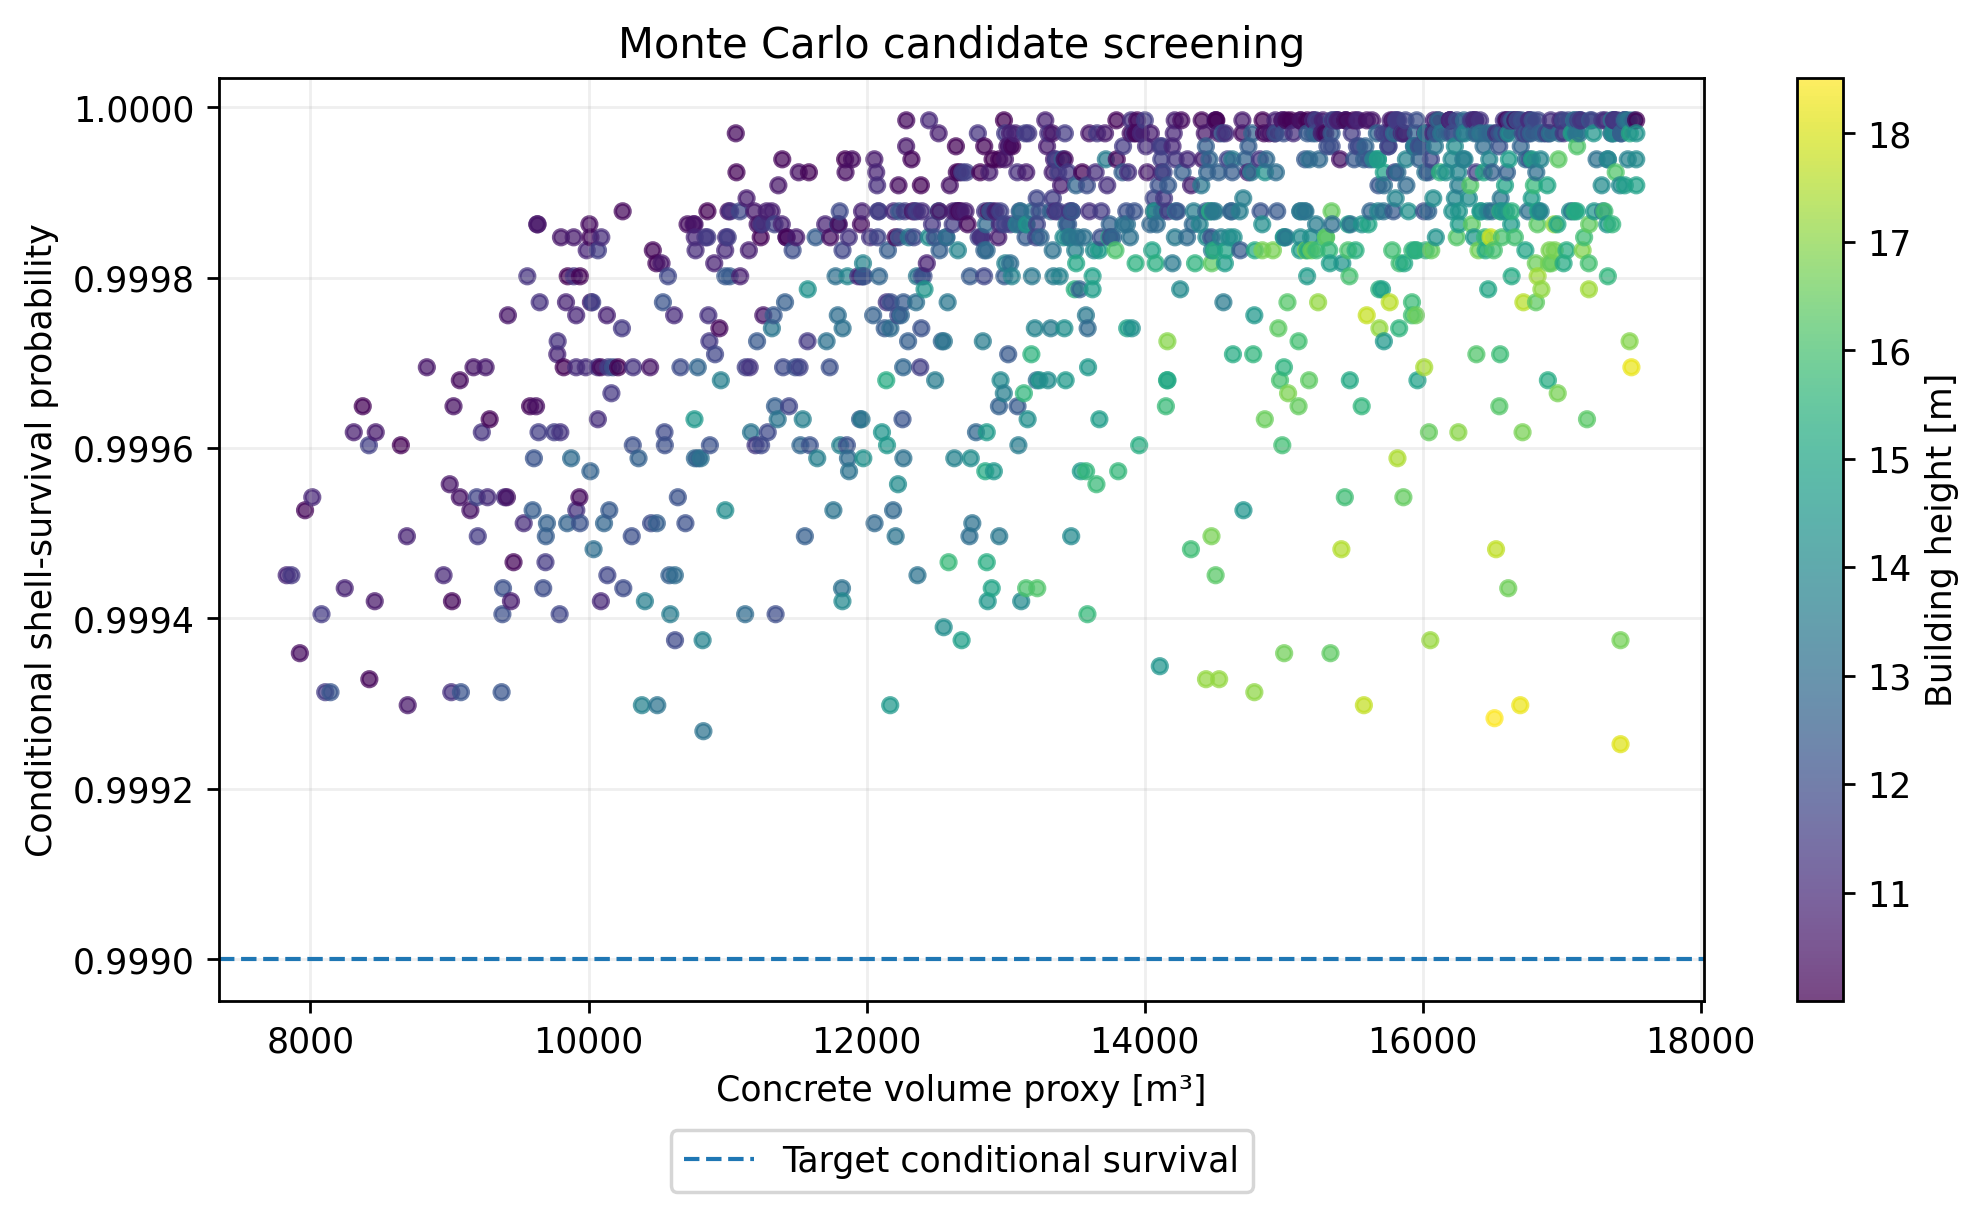

Selected footprint: 5,107.1 m²

Running high-statistics final Monte Carlo...
Final Monte Carlo:  1,000,000/10,000,000 trials
Final Monte Carlo:  2,000,000/10,000,000 trials
Final Monte Carlo:  3,000,000/10,000,000 trials
Final Monte Carlo:  4,000,000/10,000,000 trials
Final Monte Carlo:  5,000,000/10,000,000 trials
Final Monte Carlo:  6,000,000/10,000,000 trials
Final Monte Carlo:  7,000,000/10,000,000 trials
Final Monte Carlo:  8,000,000/10,000,000 trials
Final Monte Carlo:  9,000,000/10,000,000 trials
Final Monte Carlo: 10,000,000/10,000,000 trials
Final throughput              : 57.2 M trials/s

Selected conceptual geometry
Outer width                  :    73.18 m
Outer depth                  :    69.79 m
Height                       :    10.92 m
Monolith base depth          :    10.48 m
Monolith top depth           :     7.79 m
RC shell wall thickness      :     1.55 m
Courtyard width              :    52.22 m
Courtyard depth              :    48.82 m
N/S opening width each       

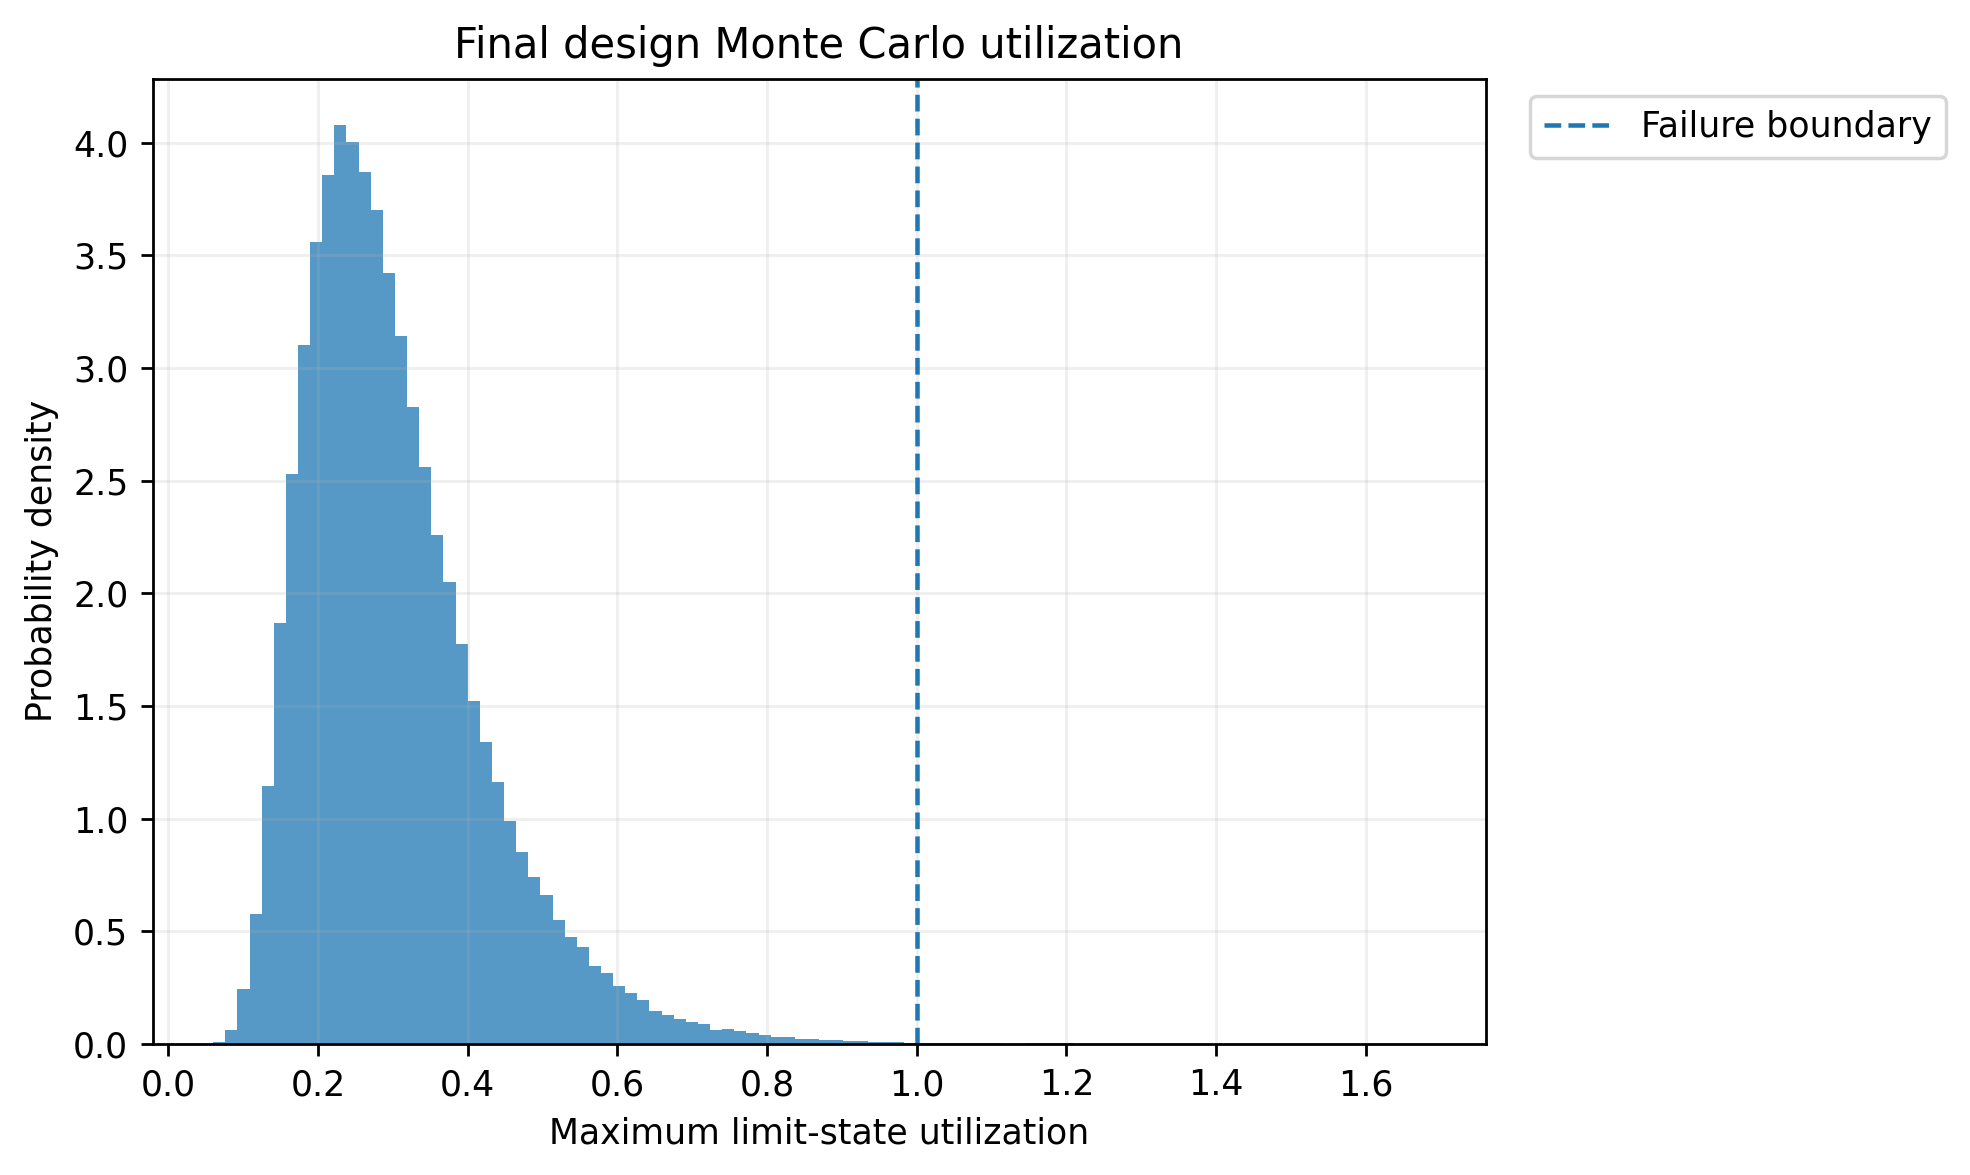


Interactive K3D geometry
Rotate and zoom the model. The outer rectangle is the 100 m x 100 m city block; the inner outline is the approximate courtyard.
K3D version                  : 3.0.3
K3D notebook environment     : Google Colab
K3D drawable objects         : 23


Output()

In [6]:
"""GPU Monte Carlo screening study for a roofless tornado-resilient courtyard concept.

The script below first explores a conceptual building formed by four tapered
reinforced-concrete monoliths surrounding an open courtyard. Each
monolith contains three large rectangular ground-level cut-throughs. CuPy
evaluates a conditional EF5 wind/debris screening model on a CUDA GPU, then
K3D renders the selected geometry interactively.

This first cell is a research and pre-design screening model. It does not implement the
full ASCE 7-22 Chapter 32, ICC 500, FEMA P-361, ACI 318, foundation, connection,
progressive-collapse, CFD, or impact-testing procedures needed for a real
building or life-safety shelter. For a more serious analysis, see the next cell.
"""

from dataclasses import dataclass
import math
import time
from typing import NamedTuple

import cupy as cp
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# - Reproducibility and GPU controls -----------------------------------------

RANDOM_SEED = 20260905
GPU_MEMORY_FRACTION = 0.90
AGGRESSIVE_L4_MODE = True
GPU_FLOAT_DTYPE = cp.float32

# Search load. Reduce these first if a shared Colab runtime is constrained.
SEARCH_CANDIDATES = 4096 if AGGRESSIVE_L4_MODE else 1024
SEARCH_TRIALS = 65_536 if AGGRESSIVE_L4_MODE else 32_768
FINAL_TRIALS = 10_000_000 if AGGRESSIVE_L4_MODE else 1_000_000
FINAL_CHUNK_TRIALS = 1_000_000 if AGGRESSIVE_L4_MODE else 250_000
MAX_CANDIDATE_BATCH = 512 if AGGRESSIVE_L4_MODE else 128

# Estimate of peak temporary storage per candidate-trial evaluation. This is
# intentionally conservative so CuPy has headroom for temporary arrays.
ESTIMATED_BYTES_PER_EVALUATION = 224
MEMORY_HEADROOM_FRACTION = 0.72

# - City-block and architectural controls -----------------------------------

BLOCK_WIDTH_M = 100.0
BLOCK_DEPTH_M = 100.0
MIN_BLOCK_EDGE_CLEARANCE_M = 5.0

# Minimum architectural utility constraints.
MIN_COURTYARD_WIDTH_M = 48.0
MIN_COURTYARD_DEPTH_M = 48.0
MIN_HEIGHT_M = 10.0
MAX_HEIGHT_M = 22.0

# Candidate outer footprint range.
MIN_OUTER_WIDTH_M = 64.0
MAX_OUTER_WIDTH_M = BLOCK_WIDTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M
MIN_OUTER_DEPTH_M = 64.0
MAX_OUTER_DEPTH_M = BLOCK_DEPTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M

# Monolith base depth is the tapered transverse architectural depth of each wing.
MIN_MONOLITH_BASE_DEPTH_M = 7.0
MAX_MONOLITH_BASE_DEPTH_M = 12.0
MIN_RC_WALL_THICKNESS_M = 0.75
MAX_RC_WALL_THICKNESS_M = 3.00
MIN_TOP_SCALE = 0.68
MAX_TOP_SCALE = 0.85

# Additional transverse walls, piers, and diaphragms are represented as a
# fraction of the two long-shell wall volumes. The K3D model shows the
# architectural massing envelope rather than a literal solid concrete fill.
DIAPHRAGM_VOLUME_FACTOR = 0.25

# Each monolith contains exactly three rectangular cut-throughs.
OPENINGS_PER_MONOLITH = 3
OPENING_WIDTH_FRACTION = 0.10
OPENING_HEIGHT_FRACTION = 0.40

# Initial concept shown before optimization.
INITIAL_WIDTH_M = 72.0
INITIAL_DEPTH_M = 72.0
INITIAL_HEIGHT_M = 12.0
INITIAL_MONOLITH_BASE_DEPTH_M = 8.0
INITIAL_RC_WALL_THICKNESS_M = 1.50
INITIAL_TOP_SCALE = 0.75

# - Reliability target -------------------------------------------------------

# Conditional structural-shell survival probability under the hazard model.
# This is a model target, not a code-prescribed life-safety probability.
TARGET_CONDITIONAL_SURVIVAL = 0.999

# Search candidates must satisfy the target using the raw Monte Carlo
# survival estimate and the 95% Wilson upper confidence bound on failure.
# - EF5 hazard model controls ------------------------------------------------

# EF5 is officially >200 mph. The upper tail has no EF-scale cap, so this
# screening model uses a deliberately broad triangular distribution.
EF5_WIND_MIN_MPH = 201.0
EF5_WIND_MODE_MPH = 250.0
EF5_WIND_MAX_MPH = 320.0

AIR_DENSITY_MEAN_KG_M3 = 1.18
AIR_DENSITY_STD_KG_M3 = 0.06

# Peak net pressure multiplier combines uncertain surface pressure,
# tornado-flow amplification, and imperfect pressure equalization.
PRESSURE_COEFF_MIN = 1.20
PRESSURE_COEFF_MODE = 1.80
PRESSURE_COEFF_MAX = 2.70

DYNAMIC_AMPLIFICATION_LOG_MEAN = 0.0
DYNAMIC_AMPLIFICATION_LOG_STD = 0.18

# Large openings can equalize some mean pressure but can also create local
# jets and concentration around piers/spandrels.
OPENING_RELIEF_MIN = 0.10
OPENING_RELIEF_MAX = 0.55
OPENING_JET_MIN = 0.10
OPENING_JET_MAX = 0.65

# - Reinforced-concrete screening controls ----------------------------------

CONCRETE_FC_MEAN_MPA = 69.0
CONCRETE_FC_STD_MPA = 7.0
CONCRETE_FC_MIN_MPA = 45.0
CONCRETE_FC_MAX_MPA = 95.0

STEEL_FY_MEAN_MPA = 500.0
STEEL_FY_STD_MPA = 30.0
STEEL_FY_MIN_MPA = 420.0
STEEL_FY_MAX_MPA = 600.0

VERTICAL_REBAR_RATIO_MEAN = 0.010
VERTICAL_REBAR_RATIO_STD = 0.0015
VERTICAL_REBAR_RATIO_MIN = 0.006
VERTICAL_REBAR_RATIO_MAX = 0.016

CONCRETE_DENSITY_MEAN_KG_M3 = 2450.0
CONCRETE_DENSITY_STD_KG_M3 = 70.0

FLEXURE_PHI = 0.90
SHEAR_PHI = 0.75
EFFECTIVE_DEPTH_FRACTION = 0.86
GRAVITY_M_S2 = 9.80665

# Uncertainty in continuity, reinforcement placement, joints, and construction.
CAPACITY_QUALITY_MIN = 0.78
CAPACITY_QUALITY_MAX = 1.00

# Foundation/load-path screening factor. A real design needs explicit soil,
# mat/grade-beam, anchorage, sliding, uplift, and connection calculations.
FOUNDATION_FACTOR_MIN = 0.75
FOUNDATION_FACTOR_MAX = 1.10

# - Tornado-borne debris screening proxy ------------------------------------

# FEMA/ICC storm-shelter testing commonly uses a 15 lb 2x4 at up to 100 mph
# in the 250 mph tornado wind zone. The model below is an energy-equivalent
# screening proxy only; it is not an impact-test substitute.
REFERENCE_MISSILE_MASS_LB = 15.0
REFERENCE_MISSILE_SPEED_MPH = 100.0
REFERENCE_RC_THICKNESS_M = 0.30
REFERENCE_FC_MPA = 40.0
REFERENCE_REBAR_RATIO = 0.006

DEBRIS_WIND_FRACTION_MIN = 0.20
DEBRIS_WIND_FRACTION_MODE = 0.40
DEBRIS_WIND_FRACTION_MAX = 0.60
DEBRIS_LOG_MASS_MEDIAN_LB = 15.0
DEBRIS_LOG_MASS_SIGMA = 0.65
DEBRIS_MASS_MAX_LB = 250.0

# - Visualization controls ---------------------------------------------------

K3D_BACKGROUND = 0x101214
K3D_CONCRETE_COLOR = 0xB7B3A8
K3D_BLOCK_COLOR = 0x7B8794
K3D_COURTYARD_COLOR = 0x6F8F72
K3D_OPACITY = 0.92
K3D_HEIGHT_PX = 720
K3D_ANTIALIAS = 3
K3D_SCREENSHOT_SCALE = 2.0
K3D_CAMERA_MODE = "orbit"

mpl.rcParams["figure.dpi"] = 250
mpl.rcParams["savefig.dpi"] = 250


@dataclass(frozen=True)
class Design:
    """Defines one four-monolith courtyard design."""

    width_m: float
    depth_m: float
    height_m: float
    monolith_base_depth_m: float
    rc_wall_thickness_m: float
    top_scale: float

    @property
    def courtyard_width_m(self) -> float:
        """Returns the approximate clear courtyard width."""
        return self.width_m - 2.0 * self.monolith_base_depth_m

    @property
    def courtyard_depth_m(self) -> float:
        """Returns the approximate clear courtyard depth."""
        return self.depth_m - 2.0 * self.monolith_base_depth_m


class HazardSamples(NamedTuple):
    """CuPy arrays containing stochastic hazard and capacity variables."""

    wind_mph: cp.ndarray
    air_density: cp.ndarray
    pressure_coeff: cp.ndarray
    dynamic_amp: cp.ndarray
    angle_rad: cp.ndarray
    opening_relief: cp.ndarray
    opening_jet: cp.ndarray
    fc_pa: cp.ndarray
    fy_pa: cp.ndarray
    rebar_ratio: cp.ndarray
    concrete_density: cp.ndarray
    capacity_quality: cp.ndarray
    foundation_factor: cp.ndarray
    debris_mass_lb: cp.ndarray
    debris_wind_fraction: cp.ndarray


@dataclass(frozen=True)
class BatchMetrics:
    """GPU-computed reliability metrics for a candidate batch."""

    survival: np.ndarray
    failure_count: np.ndarray
    failure_upper_95: np.ndarray
    mean_utilization: np.ndarray
    max_utilization: np.ndarray


def mph_to_mps(speed_mph: cp.ndarray | float) -> cp.ndarray | float:
    """Converts miles per hour to meters per second."""
    return speed_mph * 0.44704


def _triangular_gpu(
    size: int,
    low: float,
    mode: float,
    high: float,
    dtype: cp.dtype = GPU_FLOAT_DTYPE,
) -> cp.ndarray:
    """Samples a triangular distribution using CuPy primitives."""
    if not low <= mode <= high:
        raise ValueError("Triangular distribution requires low <= mode <= high.")

    u = cp.random.random(size, dtype=dtype)
    c = (mode - low) / (high - low)
    left = low + cp.sqrt(u * (high - low) * (mode - low))
    right = high - cp.sqrt((1.0 - u) * (high - low) * (high - mode))
    return cp.where(u < c, left, right).astype(dtype, copy=False)


def _truncated_normal_gpu(
    size: int,
    mean: float,
    std: float,
    low: float,
    high: float,
) -> cp.ndarray:
    """Samples a clipped normal distribution on the GPU."""
    samples = mean + std * cp.random.standard_normal(size, dtype=GPU_FLOAT_DTYPE)
    return cp.clip(samples, low, high)


def _uniform_gpu(size: int, low: float, high: float) -> cp.ndarray:
    """Samples a float32 uniform distribution on the GPU."""
    unit = cp.random.random(size, dtype=GPU_FLOAT_DTYPE)
    return low + (high - low) * unit


def configure_gpu() -> dict[str, float | str]:
    """Configures CuPy memory handling and reports the active CUDA device."""
    device_count = cp.cuda.runtime.getDeviceCount()
    if device_count < 1:
        raise RuntimeError("No CUDA GPU is visible to CuPy.")

    cp.cuda.Device(0).use()
    properties = cp.cuda.runtime.getDeviceProperties(0)
    raw_name = properties.get("name", b"Unknown CUDA GPU")
    name = raw_name.decode() if isinstance(raw_name, bytes) else str(raw_name)

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
    memory_pool = cp.get_default_memory_pool()
    pinned_pool = cp.get_default_pinned_memory_pool()

    try:
        memory_pool.set_limit(fraction=GPU_MEMORY_FRACTION)
    except (AttributeError, TypeError, ValueError):
        # CuPy versions vary slightly in MemoryPool.set_limit behavior.
        pass

    cp.random.seed(RANDOM_SEED)

    print("CUDA configuration")
    print("=" * 72)
    print(f"GPU                         : {name}")
    print(f"Free memory                 : {free_bytes / 2**30:.2f} GiB")
    print(f"Total memory                : {total_bytes / 2**30:.2f} GiB")
    print(f"CuPy pool target            : {GPU_MEMORY_FRACTION:.0%}")
    print(f"Aggressive L4 mode          : {AGGRESSIVE_L4_MODE}")
    print(f"Search candidates           : {SEARCH_CANDIDATES:,}")
    print(f"Search trials/candidate     : {SEARCH_TRIALS:,}")
    print(f"Final trials                : {FINAL_TRIALS:,}")
    print("=" * 72)

    if "L4" not in name.upper():
        print(
            "Warning: the active GPU does not report itself as an NVIDIA L4. "
            "The adaptive batcher will still use the available CUDA memory."
        )

    return {
        "name": name,
        "free_bytes": float(free_bytes),
        "total_bytes": float(total_bytes),
        "pool_used_bytes": float(memory_pool.used_bytes()),
        "pinned_pool_bytes": float(pinned_pool.n_free_blocks()),
    }


def adaptive_candidate_batch_size(free_bytes: float) -> int:
    """Returns a candidate batch size based on available GPU memory."""
    budget = free_bytes * MEMORY_HEADROOM_FRACTION
    bytes_per_candidate = SEARCH_TRIALS * ESTIMATED_BYTES_PER_EVALUATION
    estimated = int(max(1, budget // max(bytes_per_candidate, 1)))
    batch = min(MAX_CANDIDATE_BATCH, estimated)
    return max(8, batch)


def sample_hazards(n_trials: int) -> HazardSamples:
    """Samples EF5 conditional hazard and material variables on the GPU."""
    wind_mph = _triangular_gpu(
        n_trials,
        EF5_WIND_MIN_MPH,
        EF5_WIND_MODE_MPH,
        EF5_WIND_MAX_MPH,
    )

    air_density = _truncated_normal_gpu(
        n_trials,
        AIR_DENSITY_MEAN_KG_M3,
        AIR_DENSITY_STD_KG_M3,
        0.95,
        1.30,
    )
    pressure_coeff = _triangular_gpu(
        n_trials,
        PRESSURE_COEFF_MIN,
        PRESSURE_COEFF_MODE,
        PRESSURE_COEFF_MAX,
    )

    dynamic_amp = cp.exp(
        DYNAMIC_AMPLIFICATION_LOG_MEAN
        + DYNAMIC_AMPLIFICATION_LOG_STD
        * cp.random.standard_normal(n_trials, dtype=GPU_FLOAT_DTYPE)
    )
    dynamic_amp = cp.clip(dynamic_amp, 0.70, 1.80)

    angle_rad = _uniform_gpu(n_trials, 0.0, 2.0 * math.pi)
    opening_relief = _uniform_gpu(
        n_trials,
        OPENING_RELIEF_MIN,
        OPENING_RELIEF_MAX,
    )
    opening_jet = _uniform_gpu(
        n_trials,
        OPENING_JET_MIN,
        OPENING_JET_MAX,
    )

    fc_mpa = _truncated_normal_gpu(
        n_trials,
        CONCRETE_FC_MEAN_MPA,
        CONCRETE_FC_STD_MPA,
        CONCRETE_FC_MIN_MPA,
        CONCRETE_FC_MAX_MPA,
    )
    fy_mpa = _truncated_normal_gpu(
        n_trials,
        STEEL_FY_MEAN_MPA,
        STEEL_FY_STD_MPA,
        STEEL_FY_MIN_MPA,
        STEEL_FY_MAX_MPA,
    )
    rebar_ratio = _truncated_normal_gpu(
        n_trials,
        VERTICAL_REBAR_RATIO_MEAN,
        VERTICAL_REBAR_RATIO_STD,
        VERTICAL_REBAR_RATIO_MIN,
        VERTICAL_REBAR_RATIO_MAX,
    )

    concrete_density = _truncated_normal_gpu(
        n_trials,
        CONCRETE_DENSITY_MEAN_KG_M3,
        CONCRETE_DENSITY_STD_KG_M3,
        2250.0,
        2650.0,
    )

    capacity_quality = _uniform_gpu(
        n_trials,
        CAPACITY_QUALITY_MIN,
        CAPACITY_QUALITY_MAX,
    )
    foundation_factor = _uniform_gpu(
        n_trials,
        FOUNDATION_FACTOR_MIN,
        FOUNDATION_FACTOR_MAX,
    )

    debris_mass_lb = cp.exp(
        math.log(DEBRIS_LOG_MASS_MEDIAN_LB)
        + DEBRIS_LOG_MASS_SIGMA
        * cp.random.standard_normal(n_trials, dtype=GPU_FLOAT_DTYPE)
    )
    debris_mass_lb = cp.clip(debris_mass_lb, 1.0, DEBRIS_MASS_MAX_LB)
    debris_wind_fraction = _triangular_gpu(
        n_trials,
        DEBRIS_WIND_FRACTION_MIN,
        DEBRIS_WIND_FRACTION_MODE,
        DEBRIS_WIND_FRACTION_MAX,
    )

    return HazardSamples(
        wind_mph=wind_mph,
        air_density=air_density,
        pressure_coeff=pressure_coeff,
        dynamic_amp=dynamic_amp,
        angle_rad=angle_rad,
        opening_relief=opening_relief,
        opening_jet=opening_jet,
        fc_pa=fc_mpa * 1.0e6,
        fy_pa=fy_mpa * 1.0e6,
        rebar_ratio=rebar_ratio,
        concrete_density=concrete_density,
        capacity_quality=capacity_quality,
        foundation_factor=foundation_factor,
        debris_mass_lb=debris_mass_lb,
        debris_wind_fraction=debris_wind_fraction,
    )


def _integral_scale_squared(height_m: cp.ndarray, top_scale: cp.ndarray) -> cp.ndarray:
    """Returns integral of squared linear taper scale from z=0 to H."""
    return height_m * (1.0 + top_scale + top_scale**2) / 3.0


def _lower_integral_scale_squared(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
    lower_fraction: float,
) -> cp.ndarray:
    """Returns squared-scale integral from zero to a fractional height."""
    k = 1.0 - top_scale
    r = lower_fraction
    return height_m * (r - k * r**2 + (k**2) * r**3 / 3.0)


def _integral_scale_linear(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
) -> cp.ndarray:
    """Returns integral of the linear taper scale from z=0 to H."""
    return height_m * (1.0 + top_scale) / 2.0


def _lower_integral_scale_linear(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
    lower_fraction: float,
) -> cp.ndarray:
    """Returns linear-scale integral from zero to a fractional height."""
    k = 1.0 - top_scale
    r = lower_fraction
    return height_m * (r - 0.5 * k * r**2)


def concrete_volume_gpu(
    width_m: cp.ndarray,
    depth_m: cp.ndarray,
    height_m: cp.ndarray,
    monolith_depth_m: cp.ndarray,
    wall_thickness_m: cp.ndarray,
    top_scale: cp.ndarray,
) -> cp.ndarray:
    """Estimates reinforced-concrete shell volume with twelve cut-throughs."""
    inner_width = cp.maximum(width_m - 2.0 * monolith_depth_m, 1.0)
    inner_depth = cp.maximum(depth_m - 2.0 * monolith_depth_m, 1.0)

    outer_perimeter = 2.0 * (width_m + depth_m)
    inner_perimeter = 2.0 * (inner_width + inner_depth)
    total_wall_length = outer_perimeter + inner_perimeter

    integral_total = _integral_scale_linear(height_m, top_scale)
    integral_lower = _lower_integral_scale_linear(
        height_m,
        top_scale,
        OPENING_HEIGHT_FRACTION,
    )
    removed_length_fraction = (
        OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    )
    effective_integral = (
        integral_total - removed_length_fraction * integral_lower
    )

    longitudinal_shell = (
        total_wall_length
        * wall_thickness_m
        * effective_integral
    )
    return longitudinal_shell * (1.0 + DIAPHRAGM_VOLUME_FACTOR)


def concrete_volume_cpu(design: Design) -> float:
    """Returns the reinforced-concrete shell-volume estimate."""
    inner_width = max(
        design.width_m - 2.0 * design.monolith_base_depth_m,
        1.0,
    )
    inner_depth = max(
        design.depth_m - 2.0 * design.monolith_base_depth_m,
        1.0,
    )
    total_wall_length = (
        2.0 * (design.width_m + design.depth_m)
        + 2.0 * (inner_width + inner_depth)
    )

    integral_total = (
        design.height_m * (1.0 + design.top_scale) / 2.0
    )
    k = 1.0 - design.top_scale
    r = OPENING_HEIGHT_FRACTION
    integral_lower = design.height_m * (
        r - 0.5 * k * r**2
    )
    removed_length_fraction = (
        OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    )
    effective_integral = (
        integral_total - removed_length_fraction * integral_lower
    )
    longitudinal_shell = (
        total_wall_length
        * design.rc_wall_thickness_m
        * effective_integral
    )
    return longitudinal_shell * (1.0 + DIAPHRAGM_VOLUME_FACTOR)


def _design_arrays(designs: list[Design]) -> tuple[cp.ndarray, ...]:
    """Converts a design list into broadcastable CuPy column vectors."""
    def column(values: list[float]) -> cp.ndarray:
        return cp.asarray(values, dtype=GPU_FLOAT_DTYPE)[:, None]

    return (
        column([d.width_m for d in designs]),
        column([d.depth_m for d in designs]),
        column([d.height_m for d in designs]),
        column([d.monolith_base_depth_m for d in designs]),
        column([d.rc_wall_thickness_m for d in designs]),
        column([d.top_scale for d in designs]),
    )


def utilization_matrix(
    designs: list[Design],
    hazard: HazardSamples,
) -> cp.ndarray:
    """Returns the maximum limit-state utilization per design and trial.

    The four modeled screening limit states are global overturning, wall-base
    flexure, wall-base shear, and a calibrated debris-energy proxy.
    """
    (
        width,
        depth,
        height,
        monolith_depth,
        wall_thickness,
        top_scale,
    ) = _design_arrays(designs)

    cos_abs = cp.abs(cp.cos(hazard.angle_rad))[None, :]
    sin_abs = cp.abs(cp.sin(hazard.angle_rad))[None, :]
    wind_mps = mph_to_mps(hazard.wind_mph)[None, :]

    # Broad face is selected according to the dominant incident component.
    width_face = width
    depth_face = depth
    face_length = cp.where(sin_abs >= cos_abs, width_face, depth_face)

    # A squared normal component captures directional pressure variation while
    # retaining a turbulent floor for non-normal flow.
    normal_component = cp.maximum(sin_abs, cos_abs)
    directional_factor = 0.25 + 0.75 * normal_component**2

    opening_area_fraction = (
        OPENINGS_PER_MONOLITH
        * OPENING_WIDTH_FRACTION
        * OPENING_HEIGHT_FRACTION
    )
    solid_area_fraction = 1.0 - opening_area_fraction

    pressure_relief = 1.0 - hazard.opening_relief[None, :] * opening_area_fraction
    jet_factor = 1.0 + hazard.opening_jet[None, :] * opening_area_fraction

    dynamic_pressure = (
        0.5
        * hazard.air_density[None, :]
        * wind_mps**2
        * hazard.pressure_coeff[None, :]
        * hazard.dynamic_amp[None, :]
    )
    net_pressure = dynamic_pressure * directional_factor * pressure_relief

    # Simplified cantilever-wall demand. A local jet factor increases demand
    # near piers and spandrels around the cut-throughs.
    solid_face_area = face_length * height * solid_area_fraction
    base_shear_demand = net_pressure * solid_face_area * jet_factor
    base_moment_demand = base_shear_demand * (0.55 * height)

    # Effective reinforced-concrete section at the base after subtracting the
    # total opening widths from the lower wall strip.
    ligament_fraction = 1.0 - OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    effective_b = face_length * ligament_fraction
    effective_d = EFFECTIVE_DEPTH_FRACTION * wall_thickness

    as_area = (
        hazard.rebar_ratio[None, :]
        * effective_b
        * effective_d
    )
    a_depth = (
        as_area
        * hazard.fy_pa[None, :]
        / (
            0.85
            * hazard.fc_pa[None, :]
            * cp.maximum(effective_b, 1.0e-3)
        )
    )
    a_depth = cp.minimum(a_depth, 0.75 * effective_d)

    flexure_capacity = (
        FLEXURE_PHI
        * as_area
        * hazard.fy_pa[None, :]
        * (effective_d - 0.5 * a_depth)
        * hazard.capacity_quality[None, :]
    )

    # ACI-style concrete shear term in MPa and mm units, converted to newtons.
    fc_mpa = hazard.fc_pa[None, :] / 1.0e6
    b_mm = effective_b * 1000.0
    d_mm = effective_d * 1000.0
    shear_capacity = (
        SHEAR_PHI
        * 0.17
        * cp.sqrt(fc_mpa)
        * b_mm
        * d_mm
        * hazard.capacity_quality[None, :]
    )

    flexure_utilization = base_moment_demand / cp.maximum(flexure_capacity, 1.0)
    shear_utilization = base_shear_demand / cp.maximum(shear_capacity, 1.0)

    # Global overturning uses total tapered mass and a direction-dependent
    # footprint lever arm. Foundation_factor captures conceptual anchorage and
    # soil/load-path uncertainty; it is not a foundation design calculation.
    volume = concrete_volume_gpu(
        width[:, 0],
        depth[:, 0],
        height[:, 0],
        monolith_depth[:, 0],
        wall_thickness[:, 0],
        top_scale[:, 0],
    )[:, None]
    weight = hazard.concrete_density[None, :] * volume * GRAVITY_M_S2
    global_force = net_pressure * solid_face_area
    overturning_demand = global_force * 0.55 * height

    plan_lever = 0.40 * (
        width * cos_abs + depth * sin_abs
    )
    overturning_capacity = (
        weight
        * plan_lever
        * hazard.foundation_factor[None, :]
        * hazard.capacity_quality[None, :]
    )
    overturning_utilization = overturning_demand / cp.maximum(
        overturning_capacity,
        1.0,
    )

    # Debris proxy. It scales an energy-equivalent impact velocity from a
    # reference reinforced-concrete panel and the sampled missile mass.
    fc_ratio = cp.sqrt(
        cp.maximum(
            hazard.fc_pa[None, :] / 1.0e6,
            1.0,
        )
        / REFERENCE_FC_MPA
    )
    rebar_ratio_factor = cp.sqrt(
        hazard.rebar_ratio[None, :] / REFERENCE_REBAR_RATIO
    )
    thickness_factor = (
        wall_thickness / REFERENCE_RC_THICKNESS_M
    ) ** 0.55

    equivalent_capacity_mph = (
        REFERENCE_MISSILE_SPEED_MPH
        * thickness_factor
        * fc_ratio
        * rebar_ratio_factor
        * hazard.capacity_quality[None, :]
    )

    debris_speed_mph = (
        hazard.wind_mph[None, :]
        * hazard.debris_wind_fraction[None, :]
    )
    mass_energy_factor = cp.sqrt(
        hazard.debris_mass_lb[None, :] / REFERENCE_MISSILE_MASS_LB
    )
    equivalent_debris_speed_mph = debris_speed_mph * mass_energy_factor
    debris_utilization = equivalent_debris_speed_mph / cp.maximum(
        equivalent_capacity_mph,
        1.0,
    )

    maximum = cp.maximum(flexure_utilization, shear_utilization)
    maximum = cp.maximum(maximum, overturning_utilization)
    maximum = cp.maximum(maximum, debris_utilization)
    return maximum.astype(GPU_FLOAT_DTYPE, copy=False)


def _wilson_upper_bound(
    failures: np.ndarray,
    trials: int,
    z_value: float = 1.959963984540054,
) -> np.ndarray:
    """Returns the two-sided 95% Wilson upper bound for failure probability."""
    if trials <= 0:
        raise ValueError("trials must be positive.")

    phat = failures.astype(np.float64) / float(trials)
    z2 = z_value**2
    denominator = 1.0 + z2 / trials
    center = phat + z2 / (2.0 * trials)
    radius = z_value * np.sqrt(
        phat * (1.0 - phat) / trials + z2 / (4.0 * trials**2)
    )
    return np.minimum(1.0, (center + radius) / denominator)


def evaluate_design_batch(
    designs: list[Design],
    hazard: HazardSamples,
) -> BatchMetrics:
    """Evaluates failure counts and utilization summaries for candidates."""
    utilization = utilization_matrix(designs, hazard)

    failure_count_gpu = cp.count_nonzero(utilization > 1.0, axis=1)
    survival = 1.0 - failure_count_gpu / utilization.shape[1]
    mean_utilization = cp.mean(utilization, axis=1)
    max_utilization = cp.max(utilization, axis=1)

    failure_count = cp.asnumpy(failure_count_gpu).astype(np.int64)
    failure_upper_95 = _wilson_upper_bound(
        failure_count,
        utilization.shape[1],
    )

    return BatchMetrics(
        survival=cp.asnumpy(survival),
        failure_count=failure_count,
        failure_upper_95=failure_upper_95,
        mean_utilization=cp.asnumpy(mean_utilization),
        max_utilization=cp.asnumpy(max_utilization),
    )


def initial_design() -> Design:
    """Returns the default concept used as a transparent starting point."""
    return Design(
        width_m=INITIAL_WIDTH_M,
        depth_m=INITIAL_DEPTH_M,
        height_m=INITIAL_HEIGHT_M,
        monolith_base_depth_m=INITIAL_MONOLITH_BASE_DEPTH_M,
        rc_wall_thickness_m=INITIAL_RC_WALL_THICKNESS_M,
        top_scale=INITIAL_TOP_SCALE,
    )


def generate_candidates(count: int) -> list[Design]:
    """Generates reproducible random candidates satisfying city-block limits."""
    rng = np.random.default_rng(RANDOM_SEED)
    candidates: list[Design] = []

    attempts = 0
    max_attempts = count * 20
    while len(candidates) < count and attempts < max_attempts:
        attempts += 1
        width = float(rng.uniform(MIN_OUTER_WIDTH_M, MAX_OUTER_WIDTH_M))
        depth = float(rng.uniform(MIN_OUTER_DEPTH_M, MAX_OUTER_DEPTH_M))
        height = float(rng.uniform(MIN_HEIGHT_M, MAX_HEIGHT_M))
        monolith_depth = float(
            rng.uniform(
                MIN_MONOLITH_BASE_DEPTH_M,
                MAX_MONOLITH_BASE_DEPTH_M,
            )
        )
        wall_thickness = float(
            rng.uniform(
                MIN_RC_WALL_THICKNESS_M,
                MAX_RC_WALL_THICKNESS_M,
            )
        )
        top_scale = float(rng.uniform(MIN_TOP_SCALE, MAX_TOP_SCALE))

        design = Design(
            width_m=width,
            depth_m=depth,
            height_m=height,
            monolith_base_depth_m=monolith_depth,
            rc_wall_thickness_m=wall_thickness,
            top_scale=top_scale,
        )

        if design.courtyard_width_m < MIN_COURTYARD_WIDTH_M:
            continue
        if design.courtyard_depth_m < MIN_COURTYARD_DEPTH_M:
            continue
        if width > BLOCK_WIDTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M:
            continue
        if depth > BLOCK_DEPTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M:
            continue
        candidates.append(design)

    if len(candidates) < count:
        raise RuntimeError(
            f"Only generated {len(candidates)} feasible candidates after "
            f"{attempts} attempts. Relax the architectural constraints."
        )
    return candidates


def search_designs(
    candidates: list[Design],
    hazard: HazardSamples,
    candidate_batch_size: int,
) -> pd.DataFrame:
    """Evaluates candidate designs and returns a ranked DataFrame."""
    records: list[dict[str, float | bool]] = []
    cp.cuda.runtime.deviceSynchronize()
    search_start = time.perf_counter()

    for start in range(0, len(candidates), candidate_batch_size):
        batch = candidates[start : start + candidate_batch_size]
        metrics = evaluate_design_batch(batch, hazard)

        for (
            design,
            survival,
            failure_count,
            failure_upper_95,
            mean_util,
            max_util,
        ) in zip(
            batch,
            metrics.survival,
            metrics.failure_count,
            metrics.failure_upper_95,
            metrics.mean_utilization,
            metrics.max_utilization,
            strict=True,
        ):
            volume = concrete_volume_cpu(design)
            target_failure = 1.0 - TARGET_CONDITIONAL_SURVIVAL
            passes = (
                survival >= TARGET_CONDITIONAL_SURVIVAL
                and failure_upper_95 <= target_failure
            )
            records.append(
                {
                    "width_m": design.width_m,
                    "depth_m": design.depth_m,
                    "height_m": design.height_m,
                    "monolith_base_depth_m": design.monolith_base_depth_m,
                    "rc_wall_thickness_m": design.rc_wall_thickness_m,
                    "top_scale": design.top_scale,
                    "courtyard_width_m": design.courtyard_width_m,
                    "courtyard_depth_m": design.courtyard_depth_m,
                    "concrete_volume_m3": volume,
                    "survival_probability": float(survival),
                    "failure_count": int(failure_count),
                    "failure_upper_95": float(failure_upper_95),
                    "mean_utilization": float(mean_util),
                    "max_utilization": float(max_util),
                    "passes_target": bool(passes),
                }
            )

        completed = min(start + len(batch), len(candidates))
        print(
            f"Search progress: {completed:>5,}/{len(candidates):,} candidates"
        )

        del metrics
        cp.get_default_memory_pool().free_all_blocks()

    cp.cuda.runtime.deviceSynchronize()
    elapsed = time.perf_counter() - search_start
    evaluations = len(candidates) * hazard.wind_mph.size
    print(
        "Search throughput             : "
        f"{evaluations / max(elapsed, 1.0e-9) / 1.0e6:,.1f} M "
        "candidate-trials/s"
    )

    results = pd.DataFrame.from_records(records)
    results["footprint_m2"] = results["width_m"] * results["depth_m"]
    results["height_to_min_plan"] = results["height_m"] / np.minimum(
        results["width_m"],
        results["depth_m"],
    )

    # Rank by minimum concrete volume among designs satisfying reliability.
    # Secondary terms prefer smaller footprint and smaller high-tail demand.
    results = results.sort_values(
        by=[
            "passes_target",
            "concrete_volume_m3",
            "footprint_m2",
            "failure_upper_95",
        ],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)
    return results


def design_from_row(row: pd.Series) -> Design:
    """Builds a Design instance from a search result row."""
    return Design(
        width_m=float(row["width_m"]),
        depth_m=float(row["depth_m"]),
        height_m=float(row["height_m"]),
        monolith_base_depth_m=float(row["monolith_base_depth_m"]),
        rc_wall_thickness_m=float(row["rc_wall_thickness_m"]),
        top_scale=float(row["top_scale"]),
    )


def evaluate_final_design(
    design: Design,
    total_trials: int,
    chunk_trials: int,
) -> dict[str, float | np.ndarray]:
    """Runs the high-statistics final reliability simulation in GPU chunks."""
    completed = 0
    failures = 0
    utilization_chunks: list[cp.ndarray] = []
    cp.cuda.runtime.deviceSynchronize()
    final_start = time.perf_counter()

    while completed < total_trials:
        current = min(chunk_trials, total_trials - completed)
        hazard = sample_hazards(current)
        utilization = utilization_matrix([design], hazard)[0]

        failures += int(cp.count_nonzero(utilization > 1.0).get())
        utilization_chunks.append(utilization)
        completed += current

        print(f"Final Monte Carlo: {completed:>10,}/{total_trials:,} trials")
        del hazard
        cp.get_default_memory_pool().free_all_blocks()

    cp.cuda.runtime.deviceSynchronize()
    elapsed = time.perf_counter() - final_start
    print(
        "Final throughput              : "
        f"{total_trials / max(elapsed, 1.0e-9) / 1.0e6:,.1f} M trials/s"
    )

    all_utilization = cp.concatenate(utilization_chunks)
    survival = 1.0 - failures / total_trials

    metrics = {
        "survival_probability": survival,
        "failure_probability": failures / total_trials,
        "mean_utilization": float(cp.mean(all_utilization).get()),
        "p95_utilization": float(cp.percentile(all_utilization, 95.0).get()),
        "p99_utilization": float(cp.percentile(all_utilization, 99.0).get()),
        "p999_utilization": float(cp.percentile(all_utilization, 99.9).get()),
        "max_utilization": float(cp.max(all_utilization).get()),
        "utilization_sample": cp.asnumpy(
            all_utilization[
                :: max(1, total_trials // 200_000)
            ]
        ),
    }

    del all_utilization
    utilization_chunks.clear()
    cp.get_default_memory_pool().free_all_blocks()
    return metrics


def _opening_width(design: Design, wall_length_m: float) -> float:
    """Returns cut-through width for one wall."""
    del design
    return OPENING_WIDTH_FRACTION * wall_length_m


def _scale_at_height(design: Design, z_m: float) -> float:
    """Returns the linear taper scale at a given elevation."""
    fraction = np.clip(z_m / design.height_m, 0.0, 1.0)
    return 1.0 - (1.0 - design.top_scale) * fraction


def _frustum_segment_mesh(
    center_xy: tuple[float, float],
    base_x_bounds: tuple[float, float],
    base_y_bounds: tuple[float, float],
    z0_m: float,
    z1_m: float,
    design: Design,
) -> tuple[np.ndarray, np.ndarray]:
    """Creates vertices and triangle indices for one tapered wall segment."""
    cx, cy = center_xy
    x0, x1 = base_x_bounds
    y0, y1 = base_y_bounds

    scale0 = _scale_at_height(design, z0_m)
    scale1 = _scale_at_height(design, z1_m)

    def scale_x(x_value: float, scale: float) -> float:
        return cx + (x_value - cx) * scale

    def scale_y(y_value: float, scale: float) -> float:
        return cy + (y_value - cy) * scale

    xb0 = (scale_x(x0, scale0), scale_x(x1, scale0))
    yb0 = (scale_y(y0, scale0), scale_y(y1, scale0))
    xb1 = (scale_x(x0, scale1), scale_x(x1, scale1))
    yb1 = (scale_y(y0, scale1), scale_y(y1, scale1))

    vertices = np.array(
        [
            [xb0[0], yb0[0], z0_m],
            [xb0[1], yb0[0], z0_m],
            [xb0[1], yb0[1], z0_m],
            [xb0[0], yb0[1], z0_m],
            [xb1[0], yb1[0], z1_m],
            [xb1[1], yb1[0], z1_m],
            [xb1[1], yb1[1], z1_m],
            [xb1[0], yb1[1], z1_m],
        ],
        dtype=np.float32,
    )

    indices = np.array(
        [
            0, 2, 1, 0, 3, 2,
            4, 5, 6, 4, 6, 7,
            0, 1, 5, 0, 5, 4,
            1, 2, 6, 1, 6, 5,
            2, 3, 7, 2, 7, 6,
            3, 0, 4, 3, 4, 7,
        ],
        dtype=np.uint32,
    )
    return vertices, indices


def _complement_intervals(
    lower: float,
    upper: float,
    openings: list[tuple[float, float]],
) -> list[tuple[float, float]]:
    """Returns solid intervals left after subtracting opening intervals."""
    solids: list[tuple[float, float]] = []
    cursor = lower
    for opening_low, opening_high in openings:
        if opening_low > cursor:
            solids.append((cursor, opening_low))
        cursor = max(cursor, opening_high)
    if cursor < upper:
        solids.append((cursor, upper))
    return solids


def _centered_openings(
    lower: float,
    upper: float,
    count: int,
    opening_width: float,
) -> list[tuple[float, float]]:
    """Returns evenly spaced cut-through intervals along a monolith."""
    length = upper - lower
    total_open = count * opening_width
    if total_open >= 0.85 * length:
        raise ValueError("Openings occupy too much of the monolith length.")

    gap = (length - total_open) / (count + 1)
    openings: list[tuple[float, float]] = []
    cursor = lower + gap
    for _ in range(count):
        openings.append((cursor, cursor + opening_width))
        cursor += opening_width + gap
    return openings


def _add_segment(
    plot: k3d.Plot,
    design: Design,
    center_xy: tuple[float, float],
    x_bounds: tuple[float, float],
    y_bounds: tuple[float, float],
    z0_m: float,
    z1_m: float,
) -> None:
    """Adds one tapered concrete segment to a K3D plot."""
    vertices, indices = _frustum_segment_mesh(
        center_xy=center_xy,
        base_x_bounds=x_bounds,
        base_y_bounds=y_bounds,
        z0_m=z0_m,
        z1_m=z1_m,
        design=design,
    )
    plot += k3d.mesh(
        vertices,
        indices,
        color=K3D_CONCRETE_COLOR,
        opacity=K3D_OPACITY,
        side="double",
    )


def _add_monolith_x(
    plot: k3d.Plot,
    design: Design,
    center_y: float,
) -> None:
    """Adds a north/south monolith whose long axis is x."""
    half_w = design.width_m / 2.0
    half_t = design.monolith_base_depth_m / 2.0
    x_bounds = (-half_w, half_w)
    y_bounds = (center_y - half_t, center_y + half_t)
    center_xy = (0.0, center_y)

    opening_height = OPENING_HEIGHT_FRACTION * design.height_m
    opening_width = _opening_width(design, design.width_m)
    openings = _centered_openings(
        -half_w,
        half_w,
        OPENINGS_PER_MONOLITH,
        opening_width,
    )

    for solid_x in _complement_intervals(-half_w, half_w, openings):
        _add_segment(
            plot,
            design,
            center_xy,
            solid_x,
            y_bounds,
            0.0,
            opening_height,
        )

    _add_segment(
        plot,
        design,
        center_xy,
        x_bounds,
        y_bounds,
        opening_height,
        design.height_m,
    )


def _add_monolith_y(
    plot: k3d.Plot,
    design: Design,
    center_x: float,
) -> None:
    """Adds an east/west monolith whose long axis is y."""
    half_t = design.monolith_base_depth_m / 2.0
    half_l = design.depth_m / 2.0

    x_bounds = (center_x - half_t, center_x + half_t)
    y_bounds = (-half_l, half_l)
    center_xy = (center_x, 0.0)

    opening_height = OPENING_HEIGHT_FRACTION * design.height_m
    opening_width = _opening_width(design, design.depth_m)
    openings = _centered_openings(
        -half_l,
        half_l,
        OPENINGS_PER_MONOLITH,
        opening_width,
    )

    for solid_y in _complement_intervals(-half_l, half_l, openings):
        _add_segment(
            plot,
            design,
            center_xy,
            x_bounds,
            solid_y,
            0.0,
            opening_height,
        )

    _add_segment(
        plot,
        design,
        center_xy,
        x_bounds,
        y_bounds,
        opening_height,
        design.height_m,
    )


def configure_k3d_notebook() -> bool:
    """Enables K3D widget support and reports whether Colab was detected."""
    try:
        from google.colab import output  # pylint: disable=import-outside-toplevel

        output.enable_custom_widget_manager()
        return True
    except ImportError:
        # Standard Jupyter environments use their native widget manager.
        return False


def build_k3d_model(design: Design) -> k3d.Plot:
    """Builds the interactive roofless courtyard geometry."""
    plot = k3d.plot(
        background_color=K3D_BACKGROUND,
        grid_visible=False,
        grid_auto_fit=True,
        camera_auto_fit=True,
        camera_mode=K3D_CAMERA_MODE,
        height=K3D_HEIGHT_PX,
        antialias=K3D_ANTIALIAS,
        screenshot_scale=K3D_SCREENSHOT_SCALE,
        menu_visibility=True,
    )

    north_y = design.depth_m / 2.0 - design.monolith_base_depth_m / 2.0
    south_y = -north_y
    east_x = design.width_m / 2.0 - design.monolith_base_depth_m / 2.0
    west_x = -east_x

    _add_monolith_x(plot, design, north_y)
    _add_monolith_x(plot, design, south_y)
    _add_monolith_y(plot, design, east_x)
    _add_monolith_y(plot, design, west_x)

    block_x = BLOCK_WIDTH_M / 2.0
    block_y = BLOCK_DEPTH_M / 2.0
    block_outline = np.array(
        [
            [-block_x, -block_y, 0.02],
            [block_x, -block_y, 0.02],
            [block_x, block_y, 0.02],
            [-block_x, block_y, 0.02],
            [-block_x, -block_y, 0.02],
        ],
        dtype=np.float32,
    )
    plot += k3d.line(
        block_outline,
        color=K3D_BLOCK_COLOR,
        width=0.6,
    )

    court_x = design.courtyard_width_m / 2.0
    court_y = design.courtyard_depth_m / 2.0
    courtyard_outline = np.array(
        [
            [-court_x, -court_y, 0.05],
            [court_x, -court_y, 0.05],
            [court_x, court_y, 0.05],
            [-court_x, court_y, 0.05],
            [-court_x, -court_y, 0.05],
        ],
        dtype=np.float32,
    )
    plot += k3d.line(
        courtyard_outline,
        color=K3D_COURTYARD_COLOR,
        width=1.0,
    )

    plot += k3d.text(
        "Open courtyard / no roof",
        position=[0.0, 0.0, 0.5],
        color=K3D_COURTYARD_COLOR,
        size=1.0,
        label_box=False,
    )
    return plot


def display_k3d_model(design: Design) -> k3d.Plot:
    """Builds and explicitly displays the interactive K3D viewer."""
    in_colab = configure_k3d_notebook()
    plot = build_k3d_model(design)

    # Keep a strong global reference so the widget model remains alive after
    # main() returns and can be reused from a later Colab cell.
    globals()["TORNADO_K3D_PLOT"] = plot

    environment = "Google Colab" if in_colab else "Jupyter"
    print(f"K3D version                  : {getattr(k3d, '__version__', 'unknown')}")
    print(f"K3D notebook environment     : {environment}")
    print(f"K3D drawable objects         : {len(plot.objects)}")

    # K3D's supported notebook API is Plot.display(). IPython.display(plot)
    # can be less reliable across widget-manager versions in Colab.
    display_method = getattr(plot, "display", None)
    if callable(display_method):
        display_method()
    else:
        display(plot)

    return plot


def summarize_design(design: Design, metrics: dict[str, float | np.ndarray]) -> None:
    """Prints a concise engineering-screening summary."""
    north_south_opening = OPENING_WIDTH_FRACTION * design.width_m
    east_west_opening = OPENING_WIDTH_FRACTION * design.depth_m
    opening_height = OPENING_HEIGHT_FRACTION * design.height_m

    print("\nSelected conceptual geometry")
    print("=" * 72)
    print(f"Outer width                  : {design.width_m:8.2f} m")
    print(f"Outer depth                  : {design.depth_m:8.2f} m")
    print(f"Height                       : {design.height_m:8.2f} m")
    print(
        "Monolith base depth          : "
        f"{design.monolith_base_depth_m:8.2f} m"
    )
    print(
        "Monolith top depth           : "
        f"{design.monolith_base_depth_m * design.top_scale:8.2f} m"
    )
    print(
        "RC shell wall thickness      : "
        f"{design.rc_wall_thickness_m:8.2f} m"
    )
    print(f"Courtyard width              : {design.courtyard_width_m:8.2f} m")
    print(f"Courtyard depth              : {design.courtyard_depth_m:8.2f} m")
    print(
        "N/S opening width each       : "
        f"{north_south_opening:8.2f} m"
    )
    print(
        "E/W opening width each       : "
        f"{east_west_opening:8.2f} m"
    )
    print(f"Opening height               : {opening_height:8.2f} m")
    print(f"Concrete volume proxy        : {concrete_volume_cpu(design):8.0f} m^3")
    print("-" * 72)
    print(
        "Conditional survival         : "
        f"{float(metrics['survival_probability']):.6%}"
    )
    print(
        "Conditional failure          : "
        f"{float(metrics['failure_probability']):.6%}"
    )
    print(
        "Mean utilization             : "
        f"{float(metrics['mean_utilization']):.4f}"
    )
    print(
        "99.0% utilization            : "
        f"{float(metrics['p99_utilization']):.4f}"
    )
    print(
        "99.9% utilization            : "
        f"{float(metrics['p999_utilization']):.4f}"
    )
    print(f"Maximum sampled utilization  : {float(metrics['max_utilization']):.4f}")
    print("=" * 72)
    print(
        "Interpretation: this probability applies only to the simplified "
        "structural-shell screening model. The open cut-throughs admit tornado "
        "wind and debris, so the geometry does not qualify as a safe room or "
        "storm shelter. Life-safety spaces require separate ICC 500/FEMA P-361 "
        "design and tested impact-protective assemblies."
    )


def plot_search_results(results: pd.DataFrame, selected: Design) -> None:
    """Plots search reliability and geometry tradeoffs."""
    sample = results.head(min(1000, len(results))).copy()

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    scatter = ax.scatter(
        sample["concrete_volume_m3"],
        sample["survival_probability"],
        c=sample["height_m"],
        s=18,
        alpha=0.72,
    )
    ax.axhline(
        TARGET_CONDITIONAL_SURVIVAL,
        linestyle="--",
        linewidth=1.2,
        label="Target conditional survival",
    )
    ax.set_xlabel("Concrete volume proxy [m³]")
    ax.set_ylabel("Conditional shell-survival probability")
    ax.set_title("Monte Carlo candidate screening")
    ax.grid(alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Building height [m]")
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=1,
        frameon=True,
        borderaxespad=0.0,
    )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.show()

    selected_footprint = selected.width_m * selected.depth_m
    print(f"Selected footprint: {selected_footprint:,.1f} m²")


def plot_final_utilization(utilization_sample: np.ndarray) -> None:
    """Plots the sampled final utilization distribution."""
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.hist(utilization_sample, bins=100, density=True, alpha=0.75)
    ax.axvline(1.0, linestyle="--", linewidth=1.3, label="Failure boundary")
    ax.set_xlabel("Maximum limit-state utilization")
    ax.set_ylabel("Probability density")
    ax.set_title("Final design Monte Carlo utilization")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.tight_layout()
    plt.show()


def print_assumptions() -> None:
    """Prints the scope assumptions that control interpretation."""
    print("\nModel scope")
    print("=" * 72)
    print(
        "1. EF5 wind is sampled conditionally from a broad 201-320 mph "
        "triangular distribution with a 250 mph mode."
    )
    print(
        "2. Wind pressure uses 0.5*rho*V^2 multiplied by stochastic tornado "
        "pressure and dynamic factors. This is a screening surrogate, not a "
        "full ASCE 7-22 Chapter 32 implementation."
    )
    print(
        "3. Reinforced-concrete flexure and shear are reduced-order section "
        "checks with uncertain material and construction properties."
    )
    print(
        "4. The foundation term is a probabilistic reserve-factor surrogate. "
        "Geotechnical, mat, anchorage, sliding, uplift, and soil-structure "
        "interaction analyses are outside this script."
    )
    print(
        "5. Debris uses an energy-equivalent proxy anchored to the familiar "
        "15 lb 2x4 / 100 mph storm-shelter missile criterion. Real assemblies "
        "must be physically tested to the applicable standard."
    )
    print(
        "6. The four monoliths are roofless and contain three ground-level "
        "cut-throughs each. Occupant debris exposure in the courtyard is not "
        "counted as shell failure."
    )
    print("=" * 72)


def main() -> None:
    """Runs the GPU search, final Monte Carlo study, plots, and 3D viewer."""
    print_assumptions()
    gpu_info = configure_gpu()
    batch_size = adaptive_candidate_batch_size(float(gpu_info["free_bytes"]))
    print(f"Adaptive candidate batch     : {batch_size}")

    baseline = initial_design()
    print("\nEvaluating transparent starting geometry...")
    baseline_hazard = sample_hazards(SEARCH_TRIALS)
    baseline_metrics = evaluate_design_batch([baseline], baseline_hazard)
    baseline_summary = {
        "survival_probability": float(baseline_metrics.survival[0]),
        "failure_probability": 1.0 - float(baseline_metrics.survival[0]),
        "mean_utilization": float(baseline_metrics.mean_utilization[0]),
        "p95_utilization": math.nan,
        "p99_utilization": math.nan,
        "p999_utilization": math.nan,
        "max_utilization": float(baseline_metrics.max_utilization[0]),
        "utilization_sample": np.array([], dtype=np.float32),
    }
    summarize_design(baseline, baseline_summary)
    del baseline_hazard, baseline_metrics
    cp.get_default_memory_pool().free_all_blocks()

    print("\nGenerating candidate geometry set...")
    candidates = generate_candidates(SEARCH_CANDIDATES)

    print("\nSampling common-random-number hazard set for candidate search...")
    search_hazard = sample_hazards(SEARCH_TRIALS)

    print("\nSearching geometry...")
    results = search_designs(candidates, search_hazard, batch_size)
    del search_hazard
    cp.get_default_memory_pool().free_all_blocks()

    passing = results[results["passes_target"]]
    if passing.empty:
        print(
            "\nNo candidate met the target. The script will select the highest "
            "survival candidate for diagnosis instead of silently relaxing "
            "the reliability target."
        )
        selected_row = results.sort_values(
            ["survival_probability", "failure_upper_95", "max_utilization"],
            ascending=[False, True, True],
        ).iloc[0]
    else:
        selected_row = passing.iloc[0]

    selected = design_from_row(selected_row)
    globals()["TORNADO_SELECTED_DESIGN"] = selected
    print("Exported optimized geometry as TORNADO_SELECTED_DESIGN.")

    print("\nTop candidate table")
    display(
        results.head(20).round(
            {
                "width_m": 2,
                "depth_m": 2,
                "height_m": 2,
                "monolith_base_depth_m": 2,
                "rc_wall_thickness_m": 2,
                "top_scale": 3,
                "courtyard_width_m": 2,
                "courtyard_depth_m": 2,
                "concrete_volume_m3": 0,
                "survival_probability": 6,
                "failure_upper_95": 6,
                "mean_utilization": 3,
                "max_utilization": 3,
                "footprint_m2": 0,
                "height_to_min_plan": 3,
            }
        )
    )

    plot_search_results(results, selected)

    print("\nRunning high-statistics final Monte Carlo...")
    final_metrics = evaluate_final_design(
        selected,
        FINAL_TRIALS,
        FINAL_CHUNK_TRIALS,
    )
    summarize_design(selected, final_metrics)
    plot_final_utilization(
        np.asarray(final_metrics["utilization_sample"], dtype=np.float32)
    )

    print("\nInteractive K3D geometry")
    print(
        "Rotate and zoom the model. The outer rectangle is the 100 m x 100 m "
        "city block; the inner outline is the approximate courtyard."
    )
    display_k3d_model(selected)

if __name__ == "__main__":
    main()

## Example 3D Output from the K3D Viewer

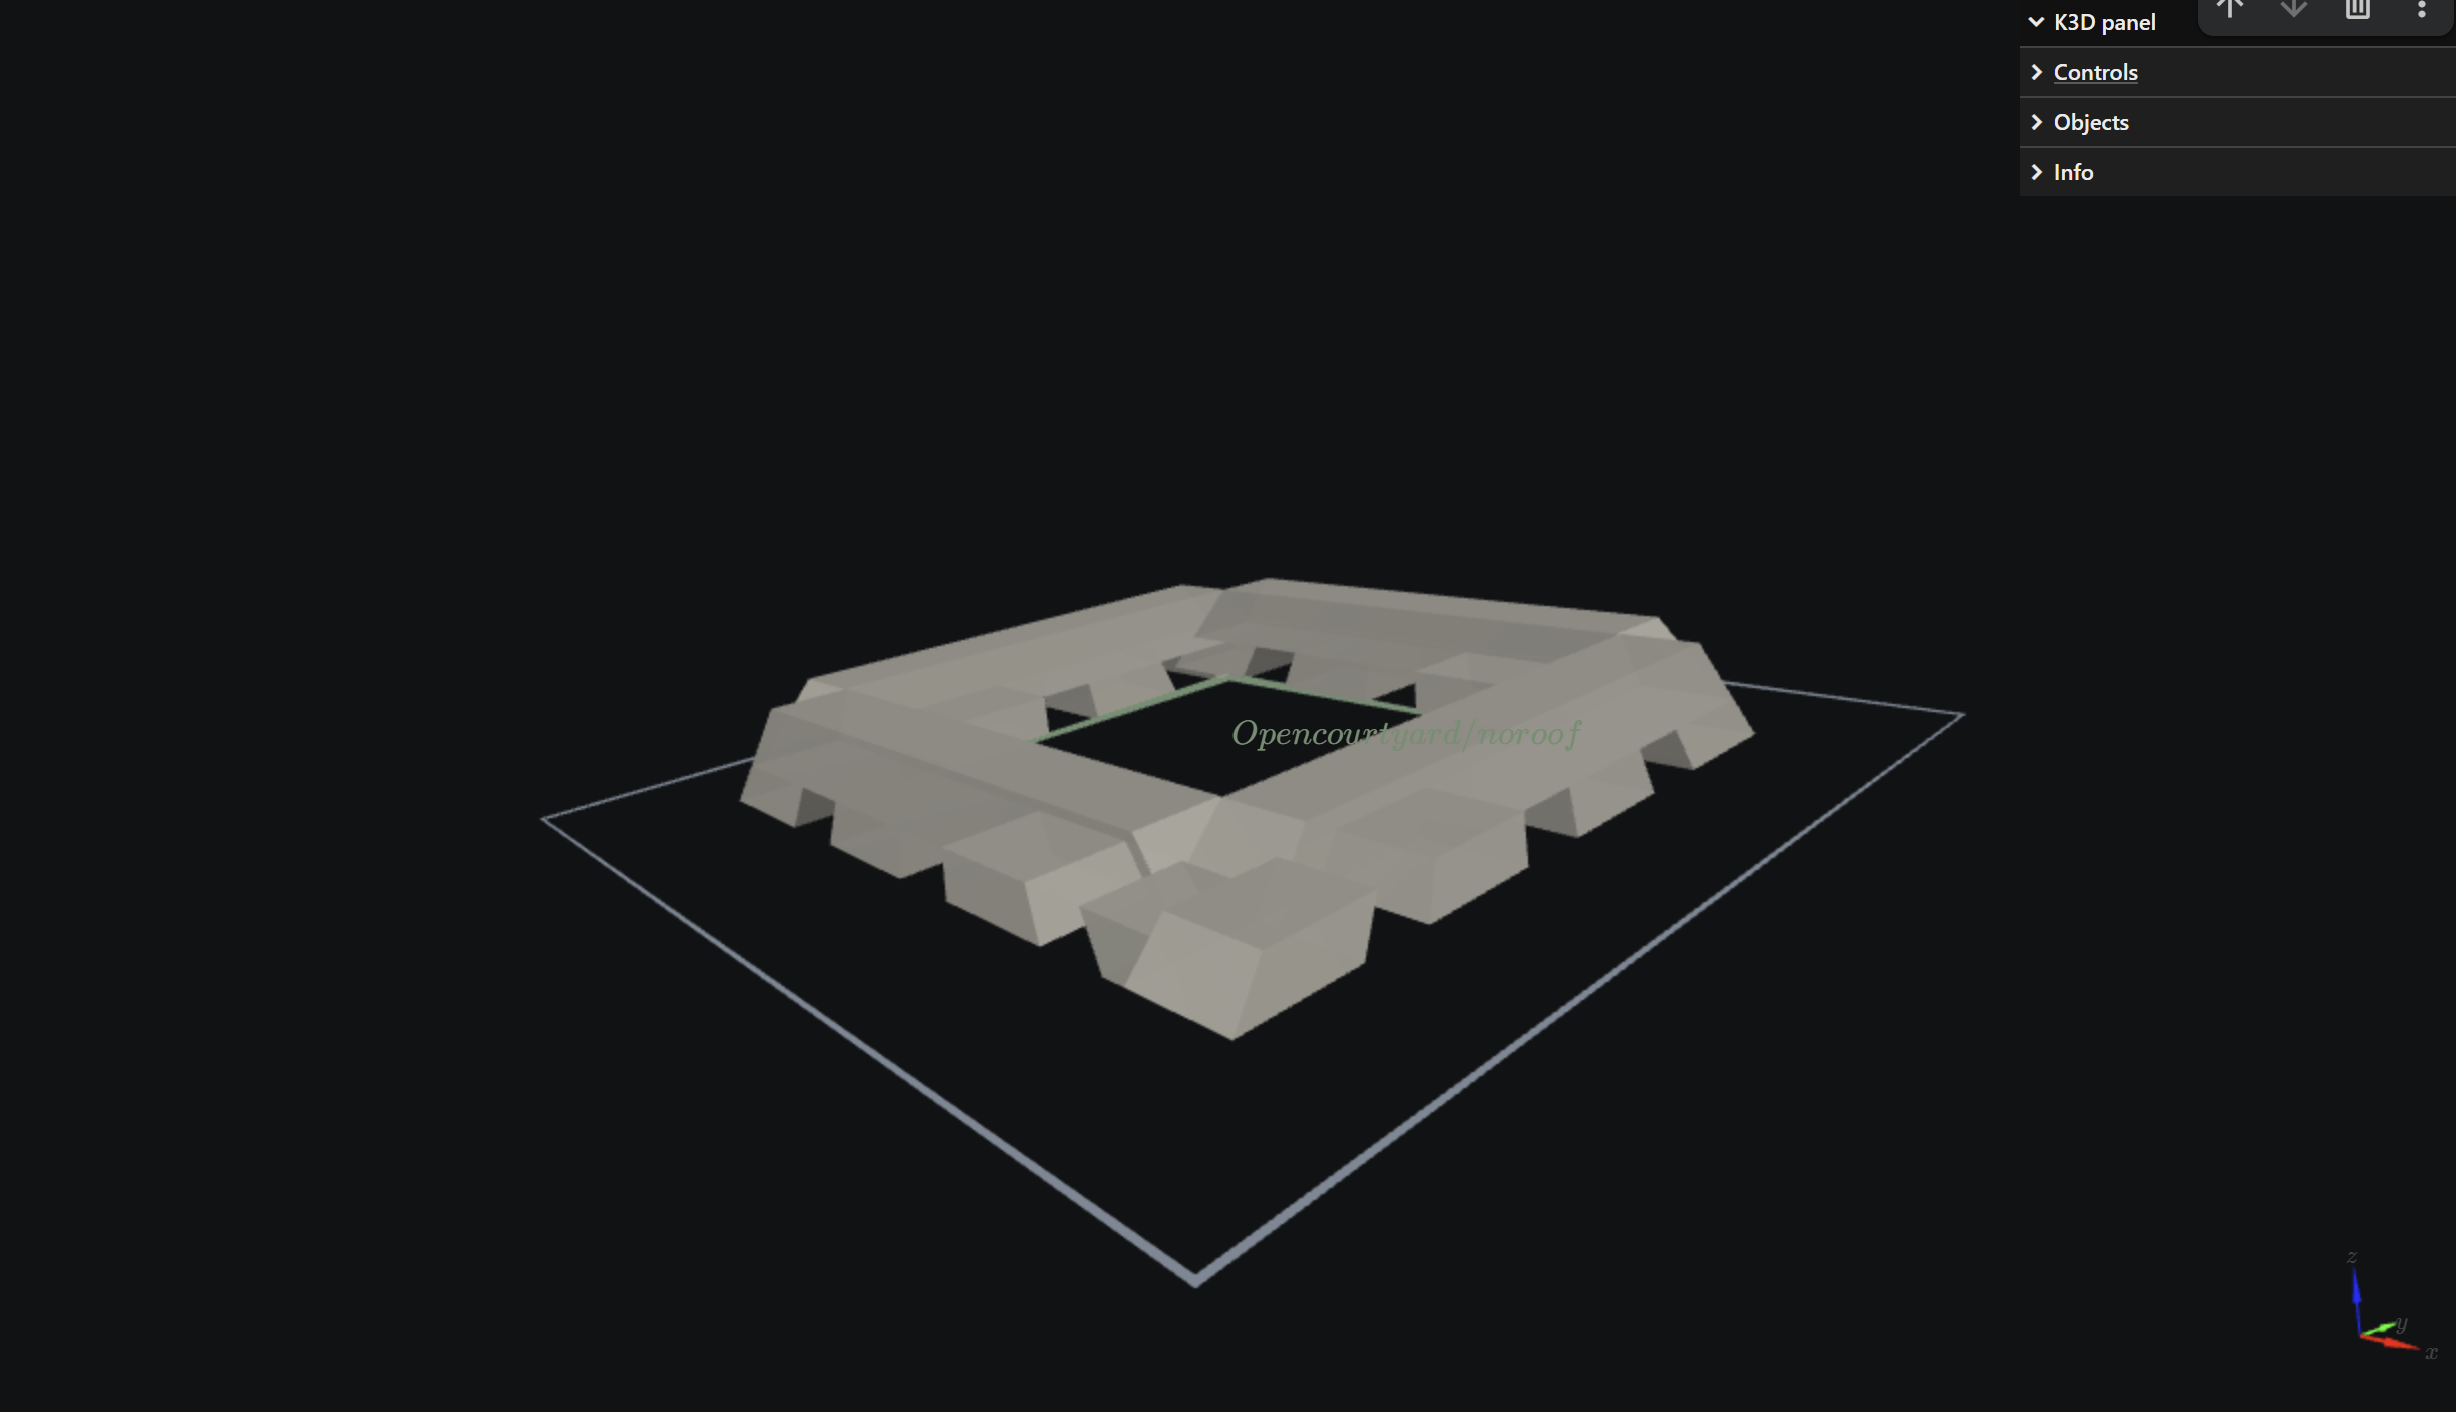

Backend: NVIDIA L4; geometry source: TORNADO_SELECTED_DESIGN
Simulated tornado speed: 320.0 mph
L4 auto-profile active; VRAM 21.75/22.03 GiB free/total.
Research diagnostics only. The open courtyard is not a qualified storm shelter.
Directional pressure coefficients remain illustrative until verified inputs are supplied.
Mesh 1: 5,496 nodes; 17,880 tetrahedra
Storage: CSR sparse adjacency; conservative CSR peak 137.9 MiB
Mesh 2: 20,936 nodes; 88,320 tetrahedra
Storage: CSR sparse adjacency; conservative CSR peak 680.7 MiB
Running adaptive 2D flow experiment; pressures remain outside structural design inputs.
CFD grid (640, 420); steps=12,000; Re=150.0; reference air Re=6.656e+08
TRANSIENT: maximum adaptive step budget reached
Refinement blocked by element cap; mesh convergence unestablished
Elastic screens stayed below supplied values; code strength qualification remains input-gated


,level,nodes,dofs,tetrahedra,compliance_j,relative_compliance_change,p99.5_tension_pa,relative_stress_percentile_change,max_displacement_m,relative_displacement_change,pcg_iterations,contact_iterations,mh_final_beta,mh_acceptance_mean,storage
0,1,5496,16488,17880,1.051395e+06,NaN,428312.977368,NaN,0.006398,NaN,4050,1,1.777462,0.547539,CSR sparse adjacency
1,2,20936,62808,88320,1.052913e+06,0.001441,448142.280597,0.044248,0.006529,0.020044,8418,1,1.971769,0.575168,CSR sparse adjacency


,direction_deg,wind_load_norm_mn,solved,max_displacement_mm,max_principal_tension_mpa
0,90.0,0.556097,True,6.881122,1.516123
1,270.0,0.556097,True,6.853665,1.422442
2,0.0,0.547740,True,6.815392,1.510764
3,180.0,0.547740,True,6.777934,1.465034
4,60.0,0.411250,False,NaN,NaN
5,240.0,0.411250,False,NaN,NaN
6,120.0,0.411250,False,NaN,NaN
7,300.0,0.411250,False,NaN,NaN
8,30.0,0.405603,False,NaN,NaN
9,210.0,0.405603,False,NaN,NaN


,quantity,demand_kpa,provided_limit_kpa,demand_over_provided_limit,status,basis
0,Peak footing pressure,323.553351,NaN,NaN,UNASSESSED,capacity/source missing
1,Peak distributed anchorage tension,0.000000,NaN,NaN,UNASSESSED,capacity/source missing
2,Peak distributed connection shear,36.679482,NaN,NaN,UNASSESSED,capacity/source missing
3,Maximum base settlement,NaN,NaN,NaN,DEMAND ONLY,6.4711 mm
4,Maximum base uplift,NaN,NaN,NaN,DEMAND ONLY,0.0000 mm


,removed_support,max_displacement_mm,displacement_amplification,max_principal_tension_mpa,tension_amplification,equilibrium_status,material_screen
0,West pier 2,12.201473,1.773181,5.069970,3.344035,CONVERGED; static elastic case,Cracking screen exceeded; nonlinear analysis r...
1,East pier 2,12.183877,1.770624,4.899383,3.231520,CONVERGED; static elastic case,Cracking screen exceeded; nonlinear analysis r...
2,West pier 3,11.904135,1.729970,4.292694,2.831362,CONVERGED; static elastic case,Cracking screen exceeded; nonlinear analysis r...
3,South pier 3,12.712715,1.847477,4.186560,2.761359,CONVERGED; static elastic case,Cracking screen exceeded; nonlinear analysis r...


,topic,computed_in_cell,status,external_work_required
0,ASCE 7-22 Chapter 32,"Velocity pressure, illustrative face loads, di...",SCREENING ONLY,"Site hazard, risk category, effective plan are..."
1,ICC 500-2023 / FEMA P-361 (2024),Missile demand quantities and structural precu...,UNASSESSED FOR SHELTER QUALIFICATION,"Protected envelope, roof, doors, penetrations,..."
2,ACI CODE-318-25,3D elastic stress plus unfactored reinforced-c...,MECHANICS SCREEN ONLY,"Adopted local edition, reinforcement layout, s..."
3,Foundation,"Compression contact, settlement/uplift demand,...",UNASSESSED CAPACITY,"Geotechnical report, bearing/friction limits, ..."
4,Connections,Distributed anchor tension and interface shear...,UNASSESSED CAPACITY,"Anchor layout, embedment, edge distances, brea..."
5,Progressive collapse,Independent static pier-base support removals,PRECURSOR ONLY,"Dynamic member-loss analysis, nonlinear cracki..."
6,CFD,"Adaptive 2D reduced-Re LBM with ramp, sponge a...",DIAGNOSTIC ONLY; excluded from structural pres...,"3D tornado inflow, atmospheric boundary layer,..."
7,Impact testing,"Missile energy, momentum and arrest-pulse demand",UNASSESSED QUALIFICATION,"Applicable physical assembly test, impact loca..."


,assessment,required_input,ready,status
0,Site tornado hazard,site_tornado_speed_mph + site_input_reference,False,MISSING EXTERNAL INPUT
1,Verified surface pressures,prescribed_face_pressure_pa + pressure_input_r...,False,MISSING EXTERNAL INPUT
2,Soil bearing,soil_bearing_limit_pa + geotechnical_reference,False,MISSING EXTERNAL INPUT
3,Sliding resistance,soil_friction_coefficient + geotechnical_refer...,False,MISSING EXTERNAL INPUT
4,Anchor tension capacity,anchor_tension_capacity_pa + connection_reference,False,MISSING EXTERNAL INPUT
5,Connection shear capacity,connection_shear_capacity_pa + connection_refe...,False,MISSING EXTERNAL INPUT
6,Physical impact qualification,impact_test_report_reference,False,MISSING EXTERNAL INPUT


Numerical checks: {'affine_strain_max_error': 1.1224880617013988e-17, 'relative_symmetry_error': 1.9214238822636024e-16, 'rigid_translation_relative_error': 1.4410679116977018e-16, 'csr_tensor_relative_error': 2.1191110875906731e-16, 'relative_force_balance_error': 9.8896176244116e-10, 'relative_moment_balance_error': 2.351071890473469e-09, 'relative_work_balance_error': 3.268020355755464e-13}
Summary: {'simulated_tornado_speed_mph': 320.0, 'continuum_volume_m3': 7818.254414935456, 'max_displacement_mm': 6.881122424390285, 'max_principal_tension_mpa': 1.516123205701677, 'total_compression_mn': 187.1267999177691, 'total_anchor_tension_mn': 0.0, 'global_friction_demand_ratio': nan, 'governing_screened_wind_direction_deg': 90.0}
GPU memory: {'free_gib': 19.9385986328125, 'total_gib': 22.0343017578125, 'pool_used_gib': 0.014063835144042969}


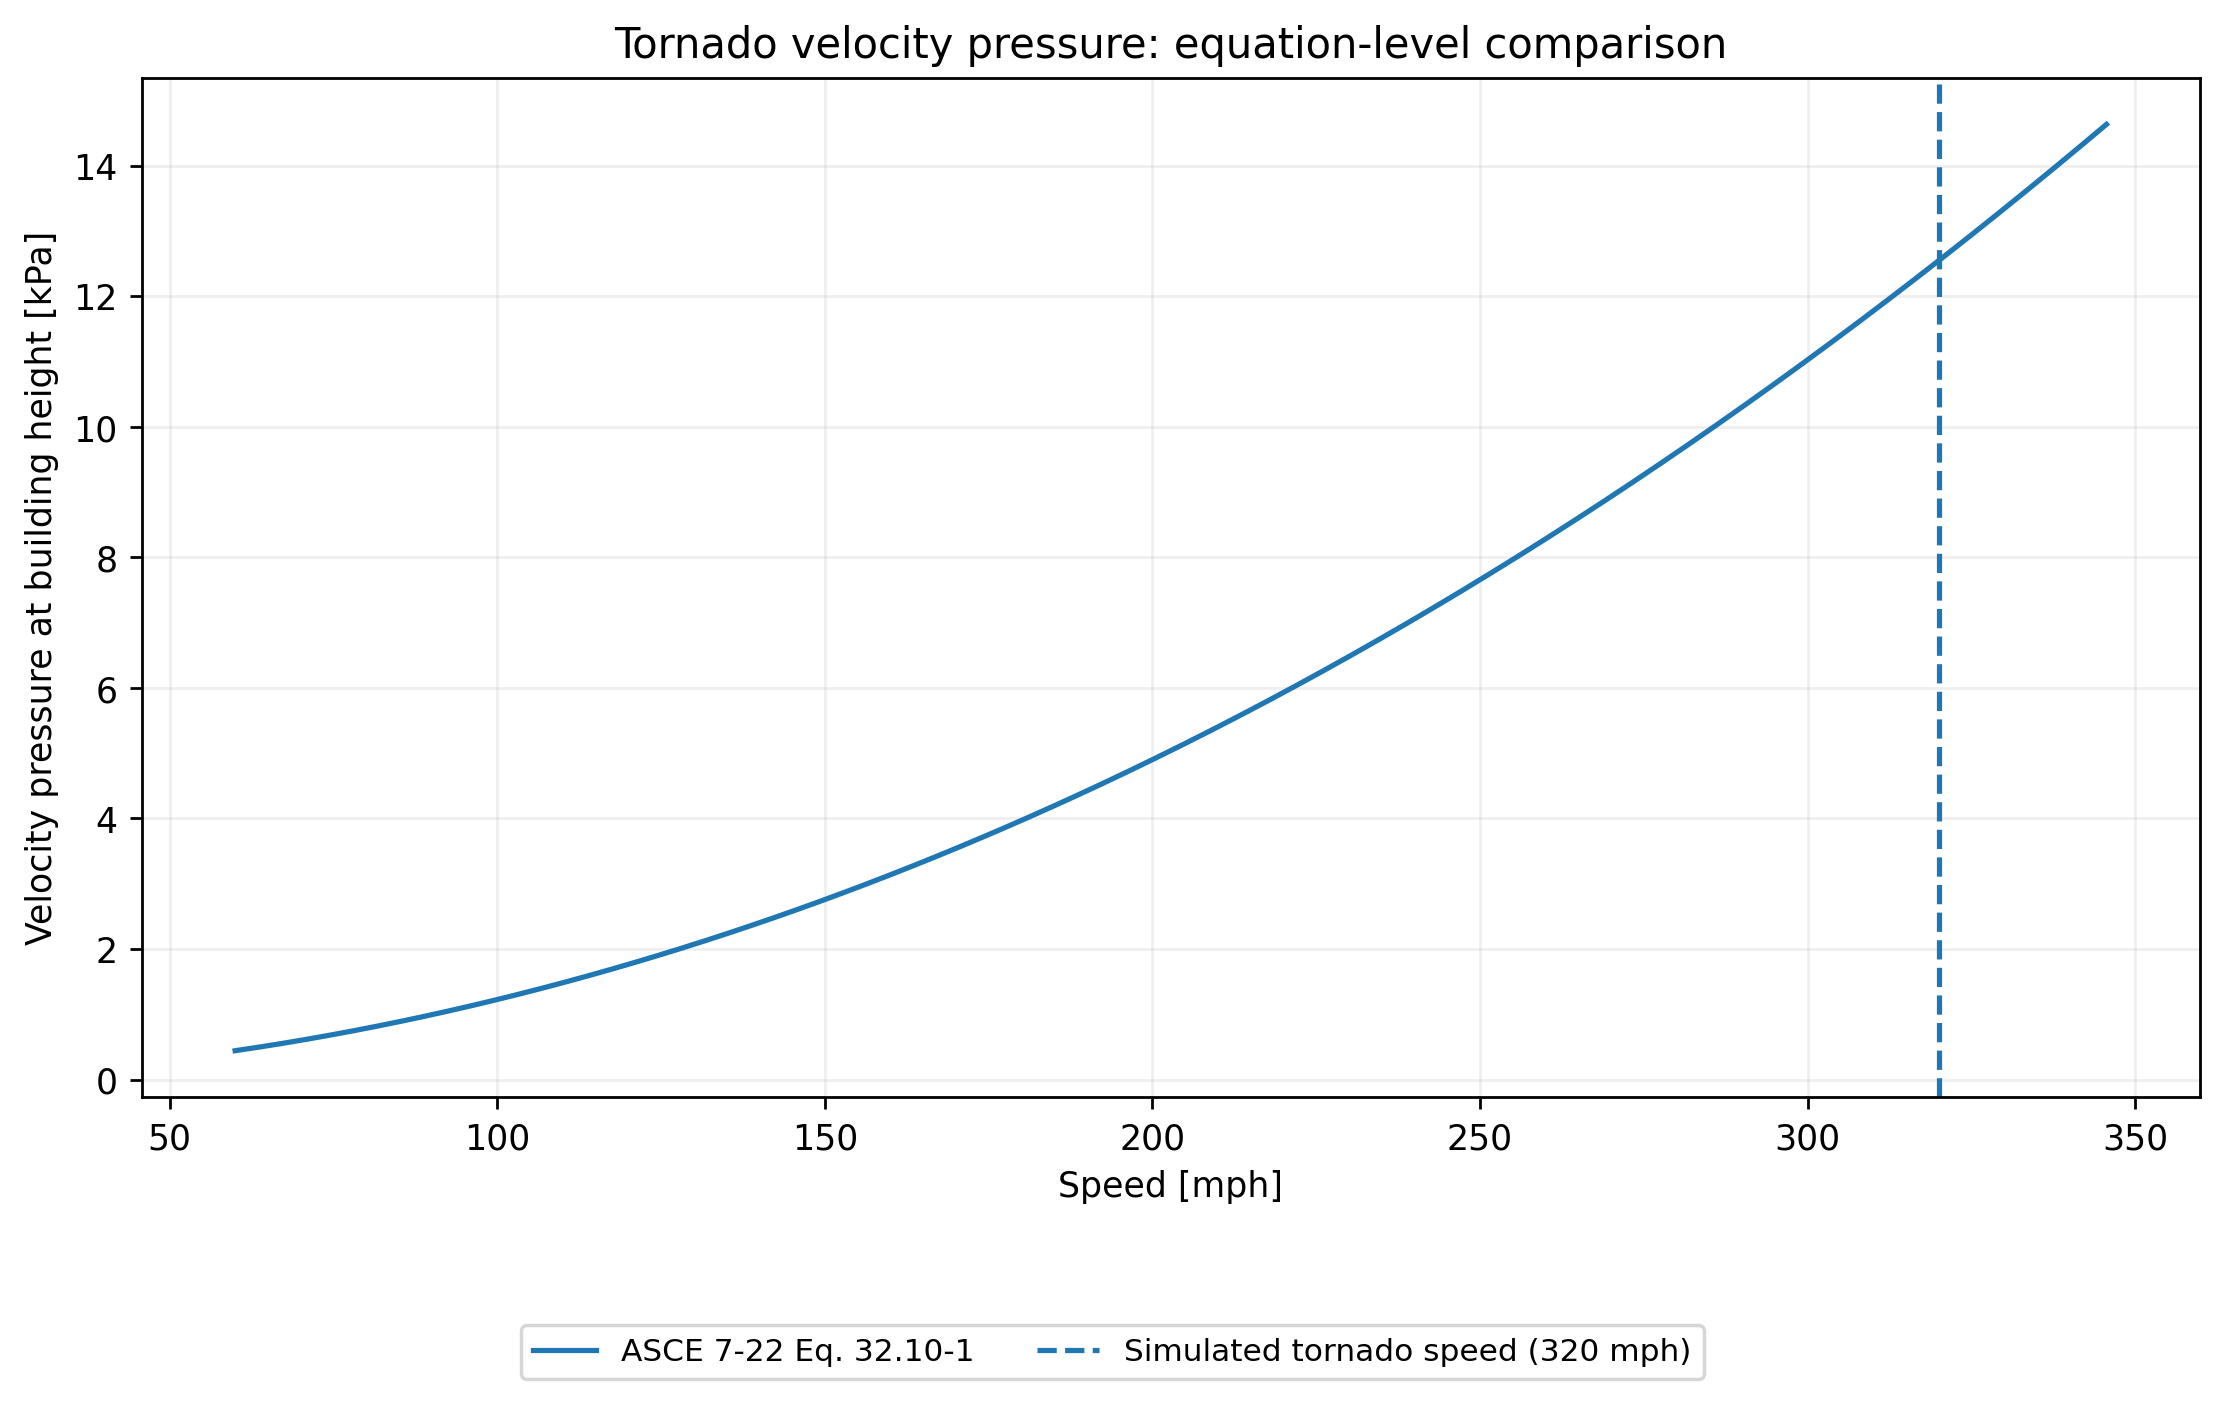

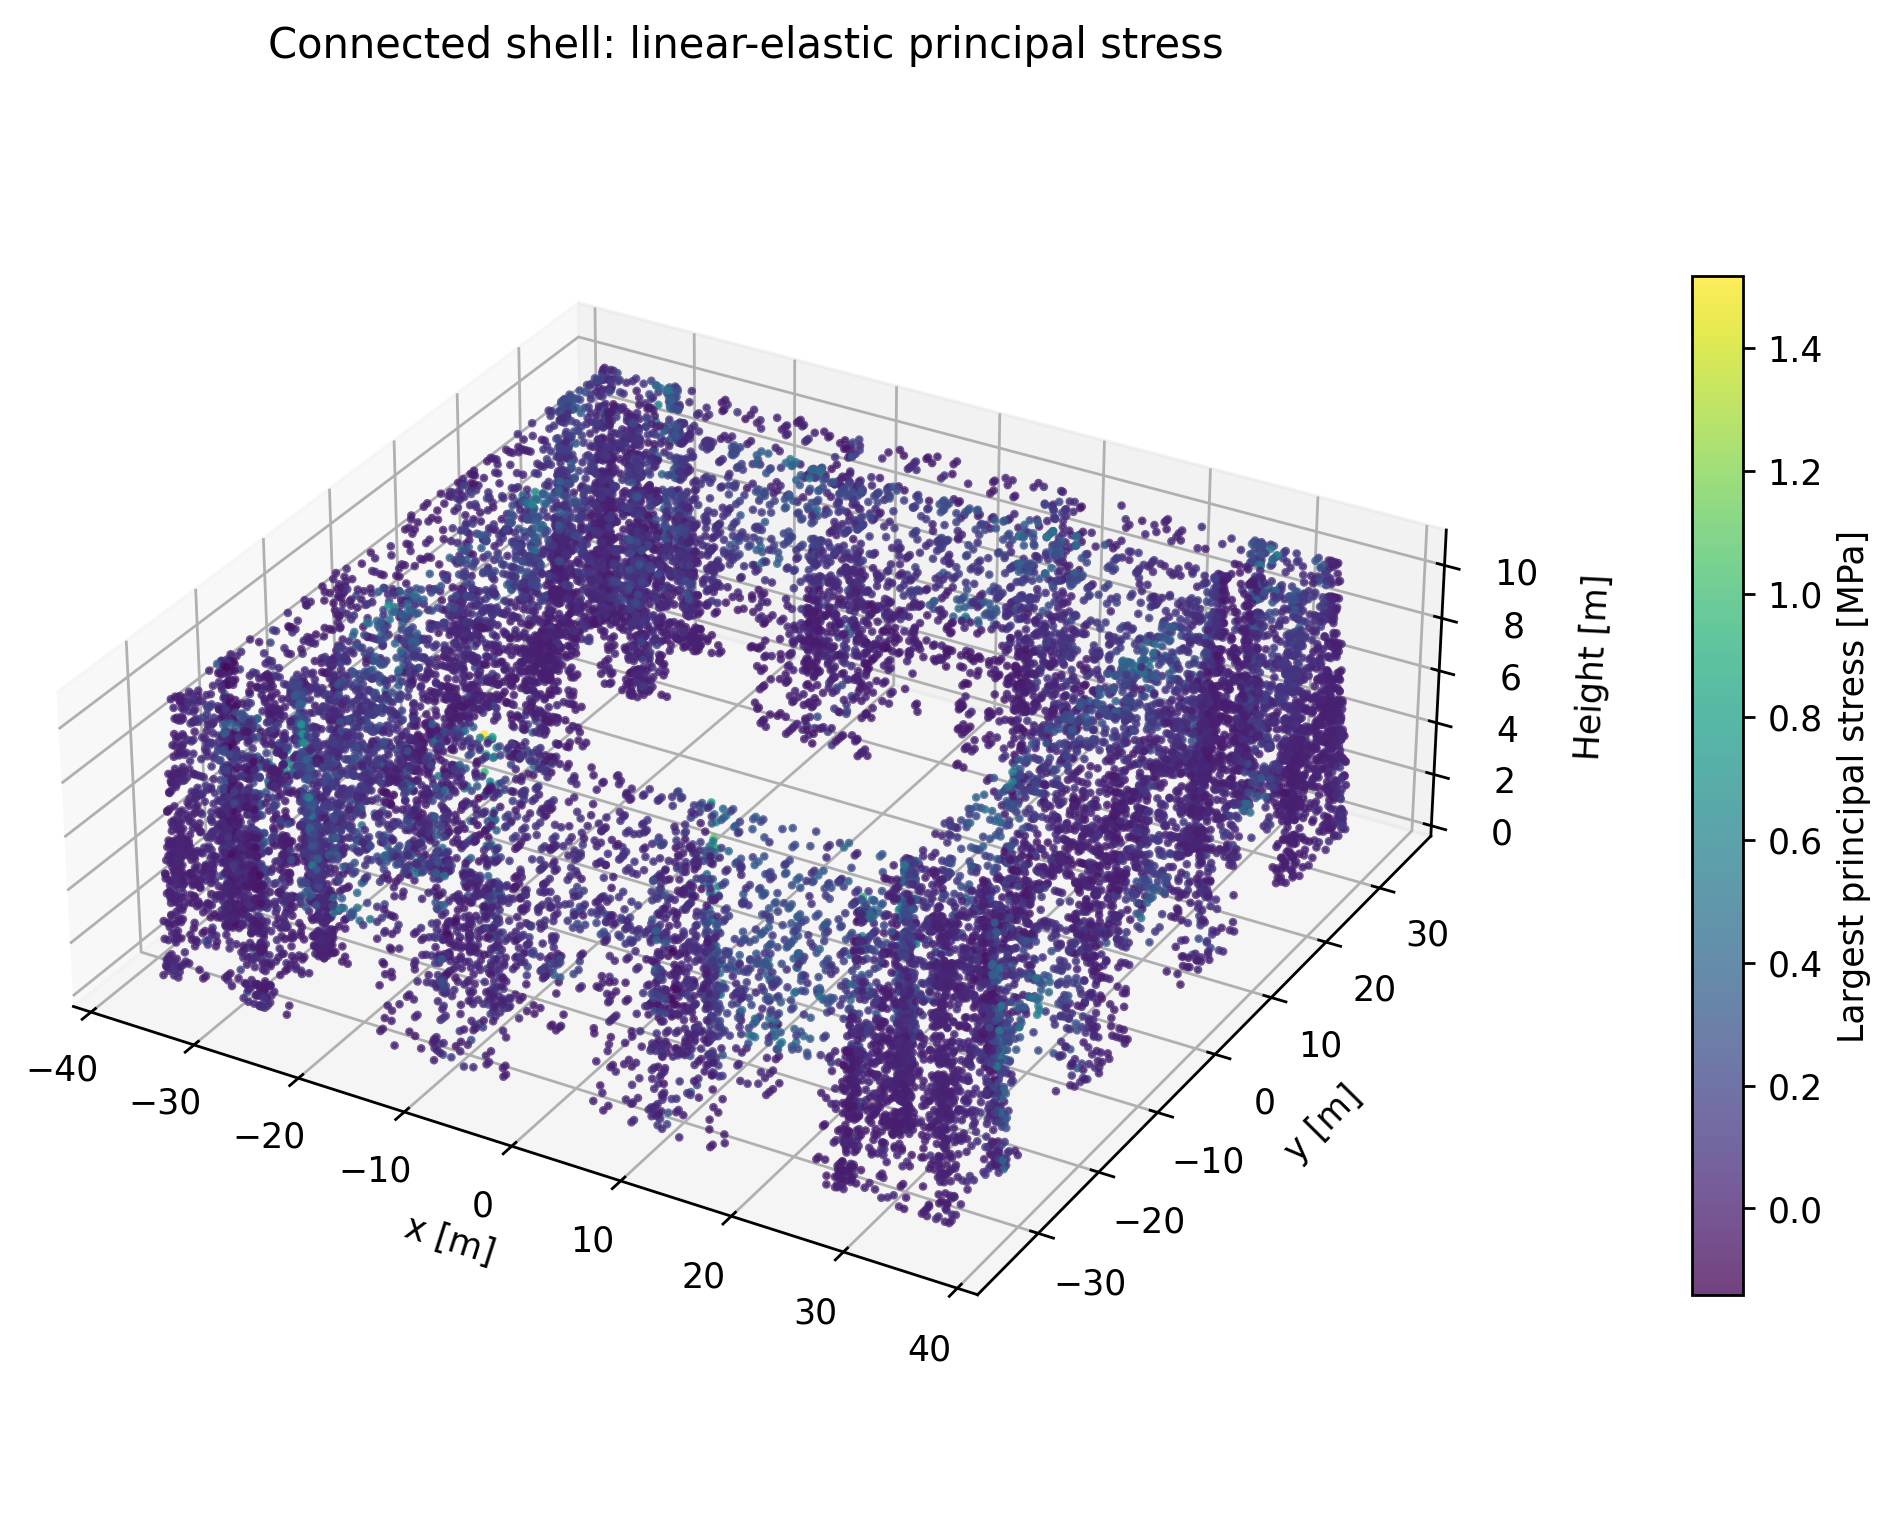

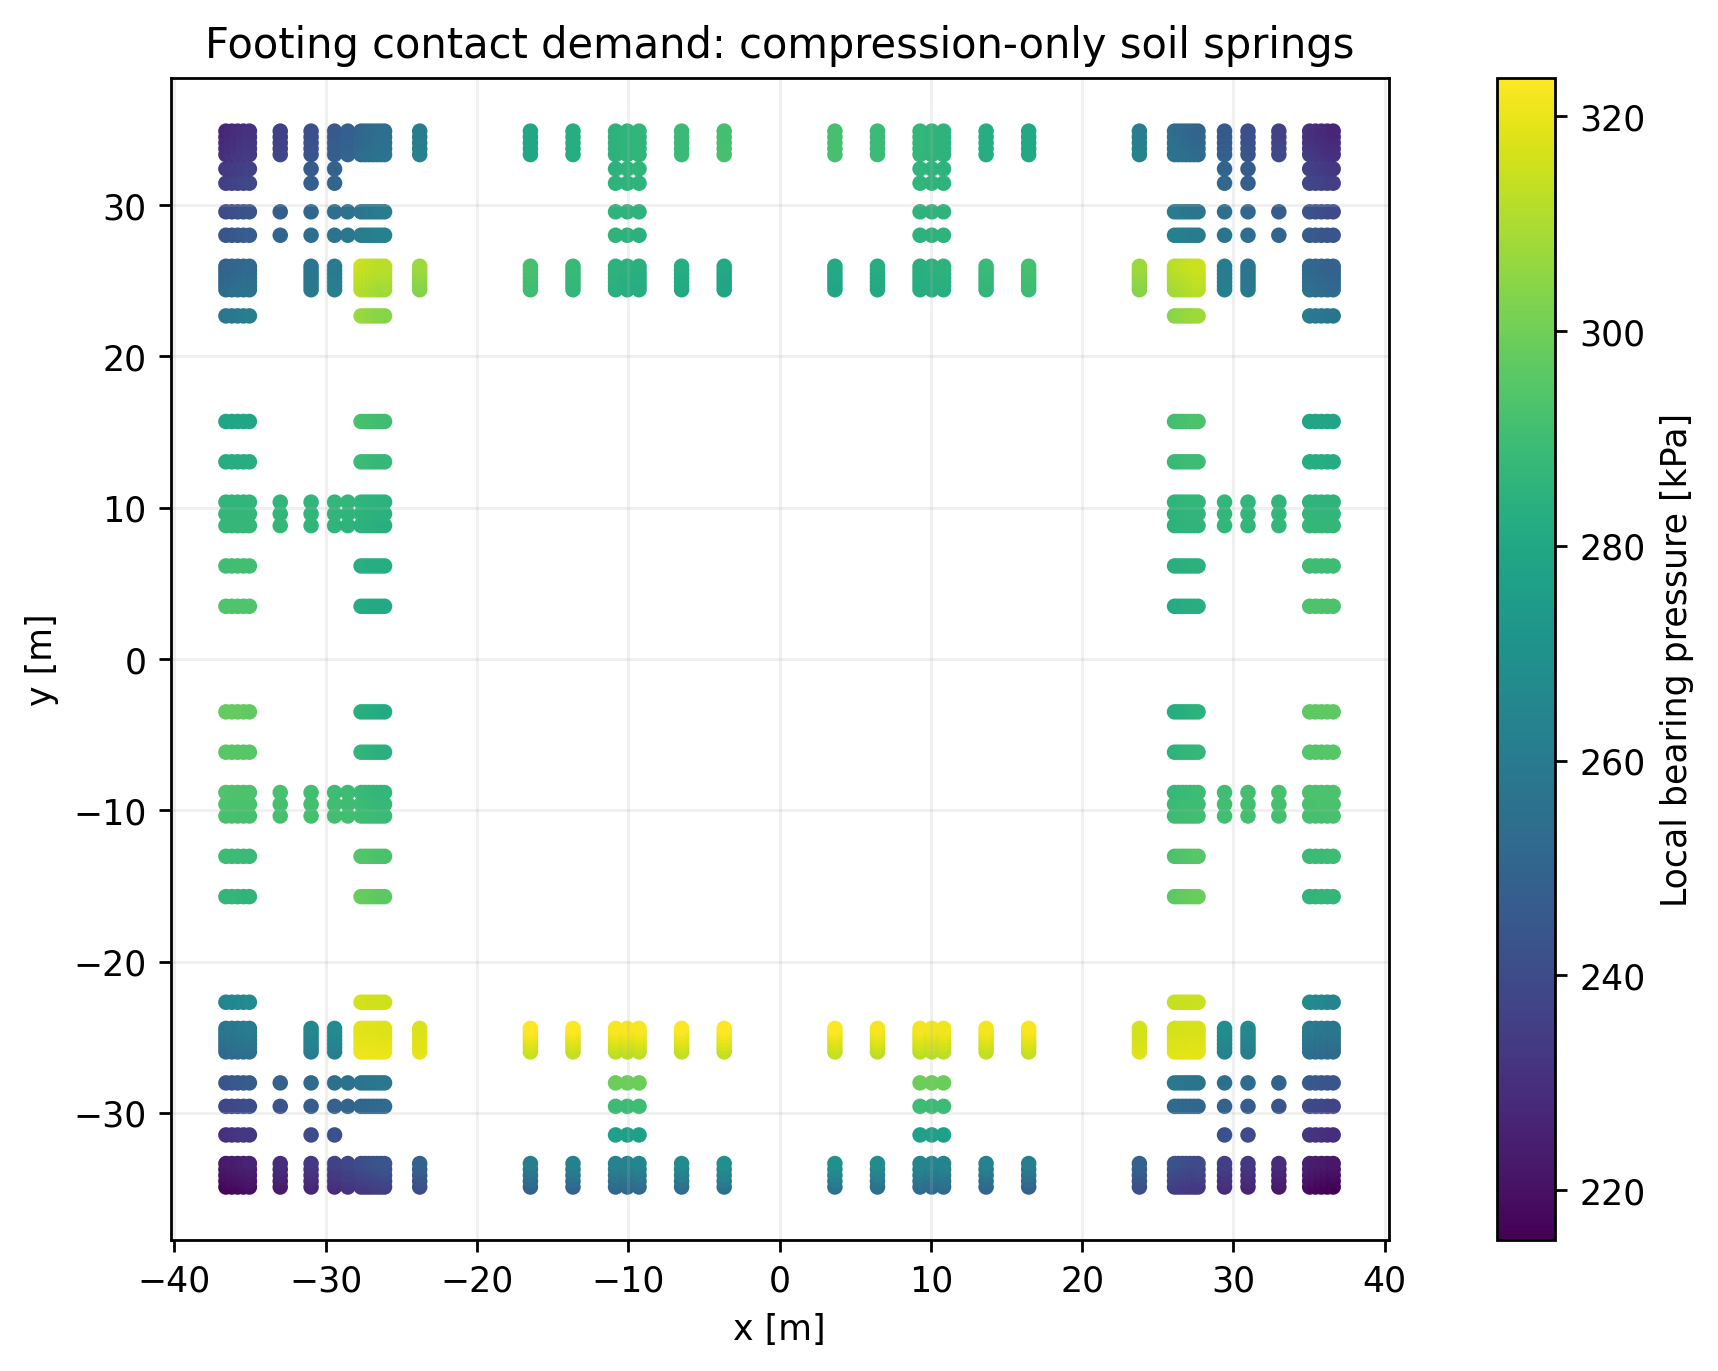

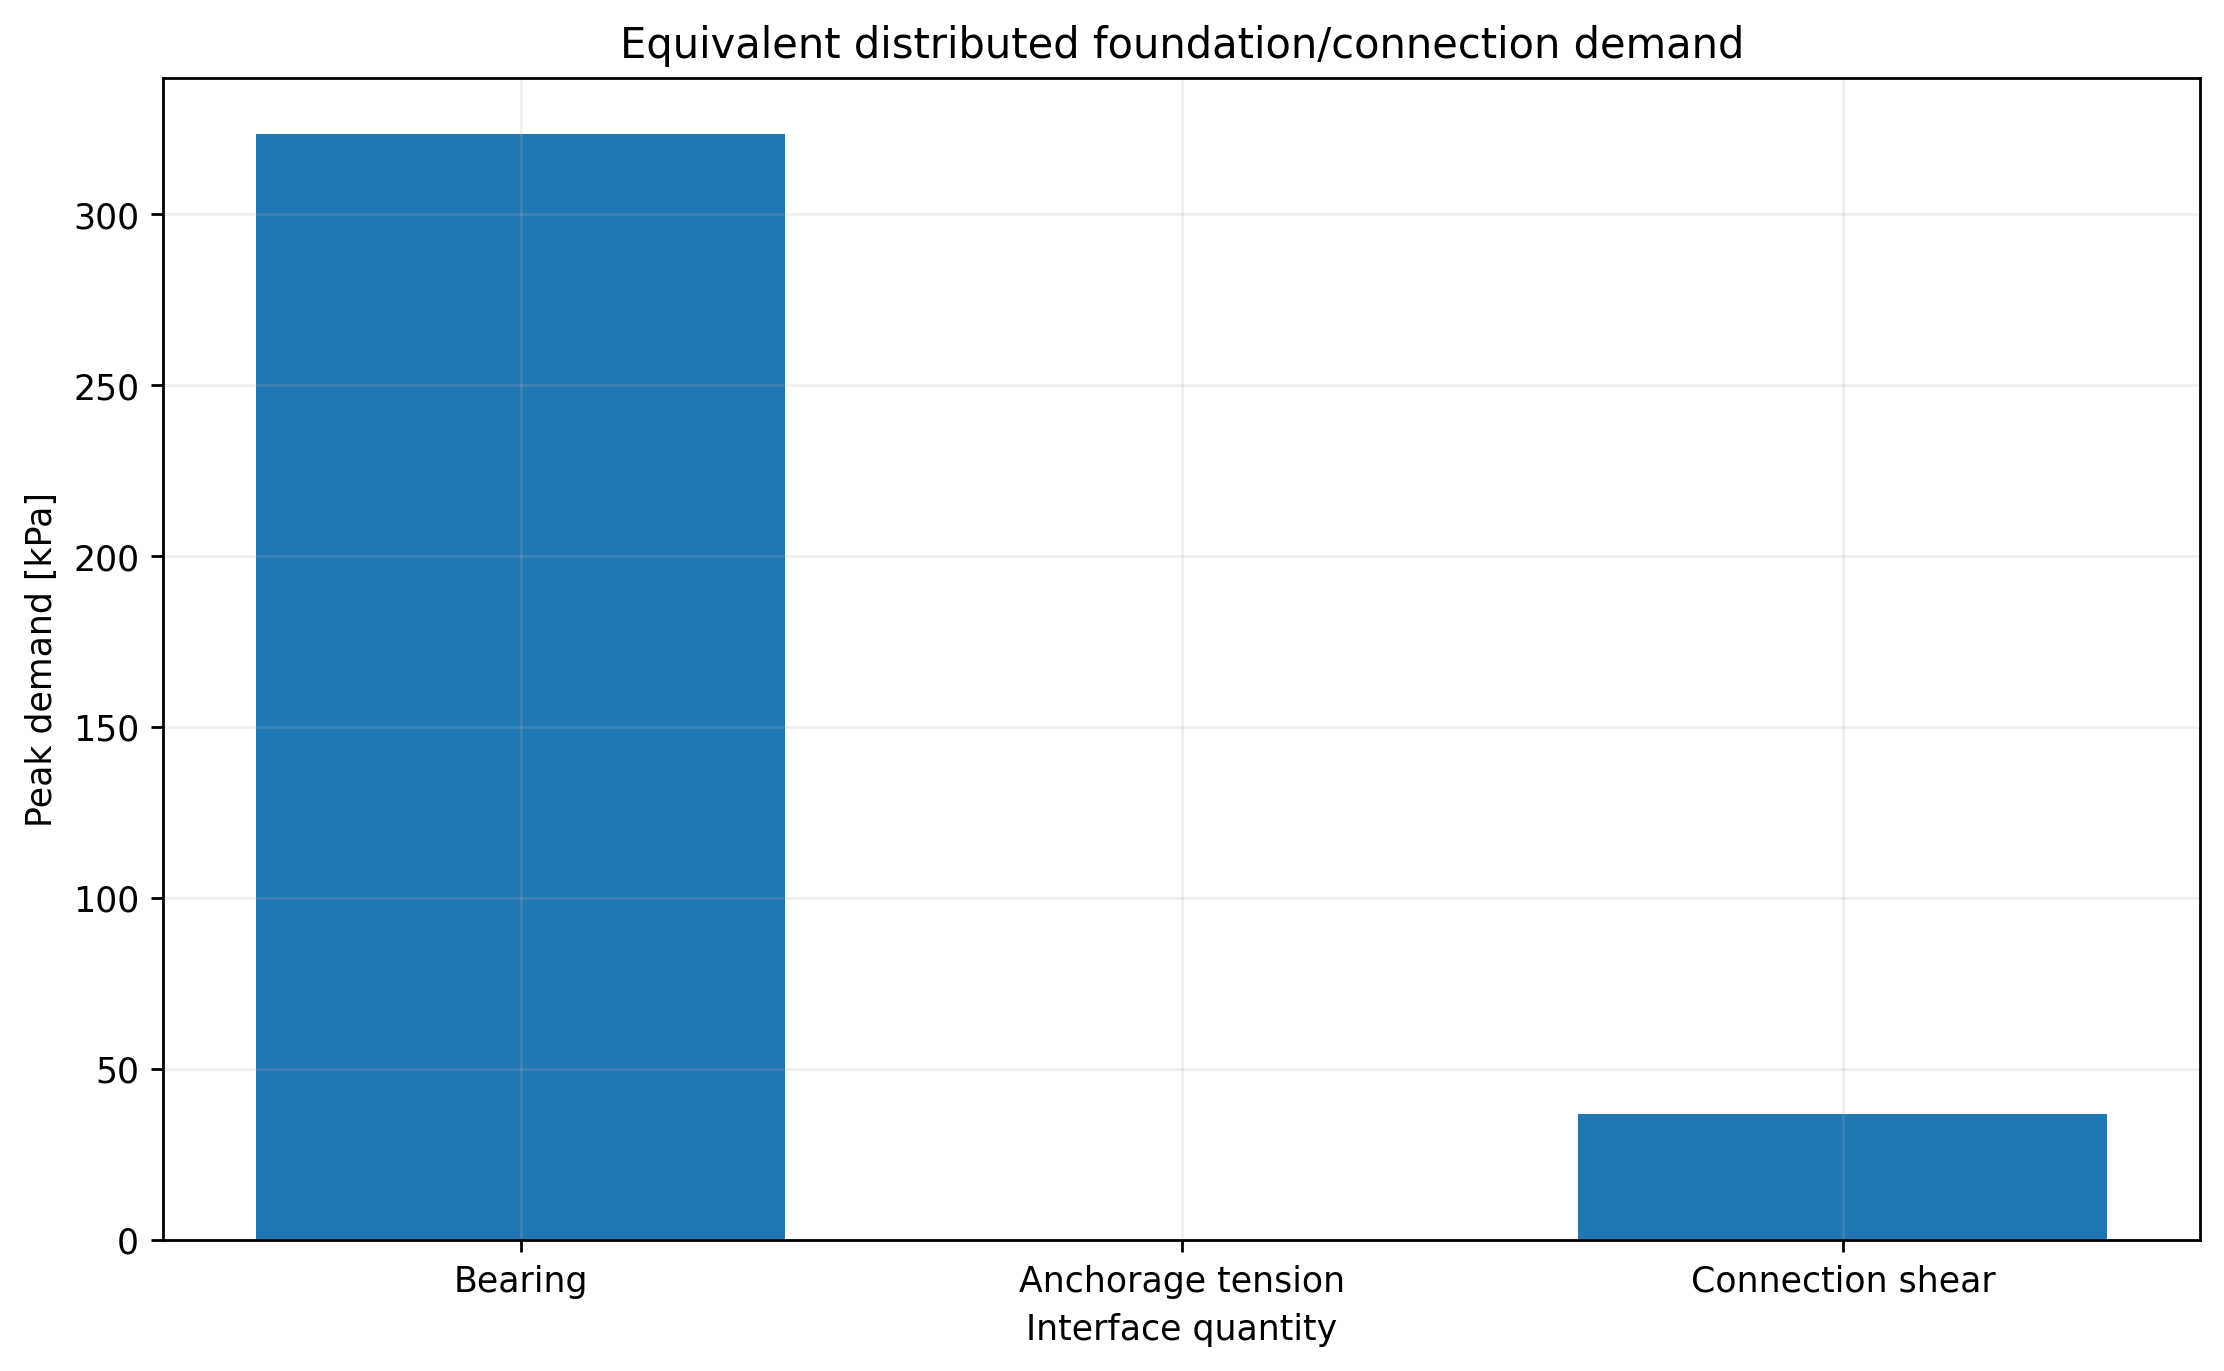

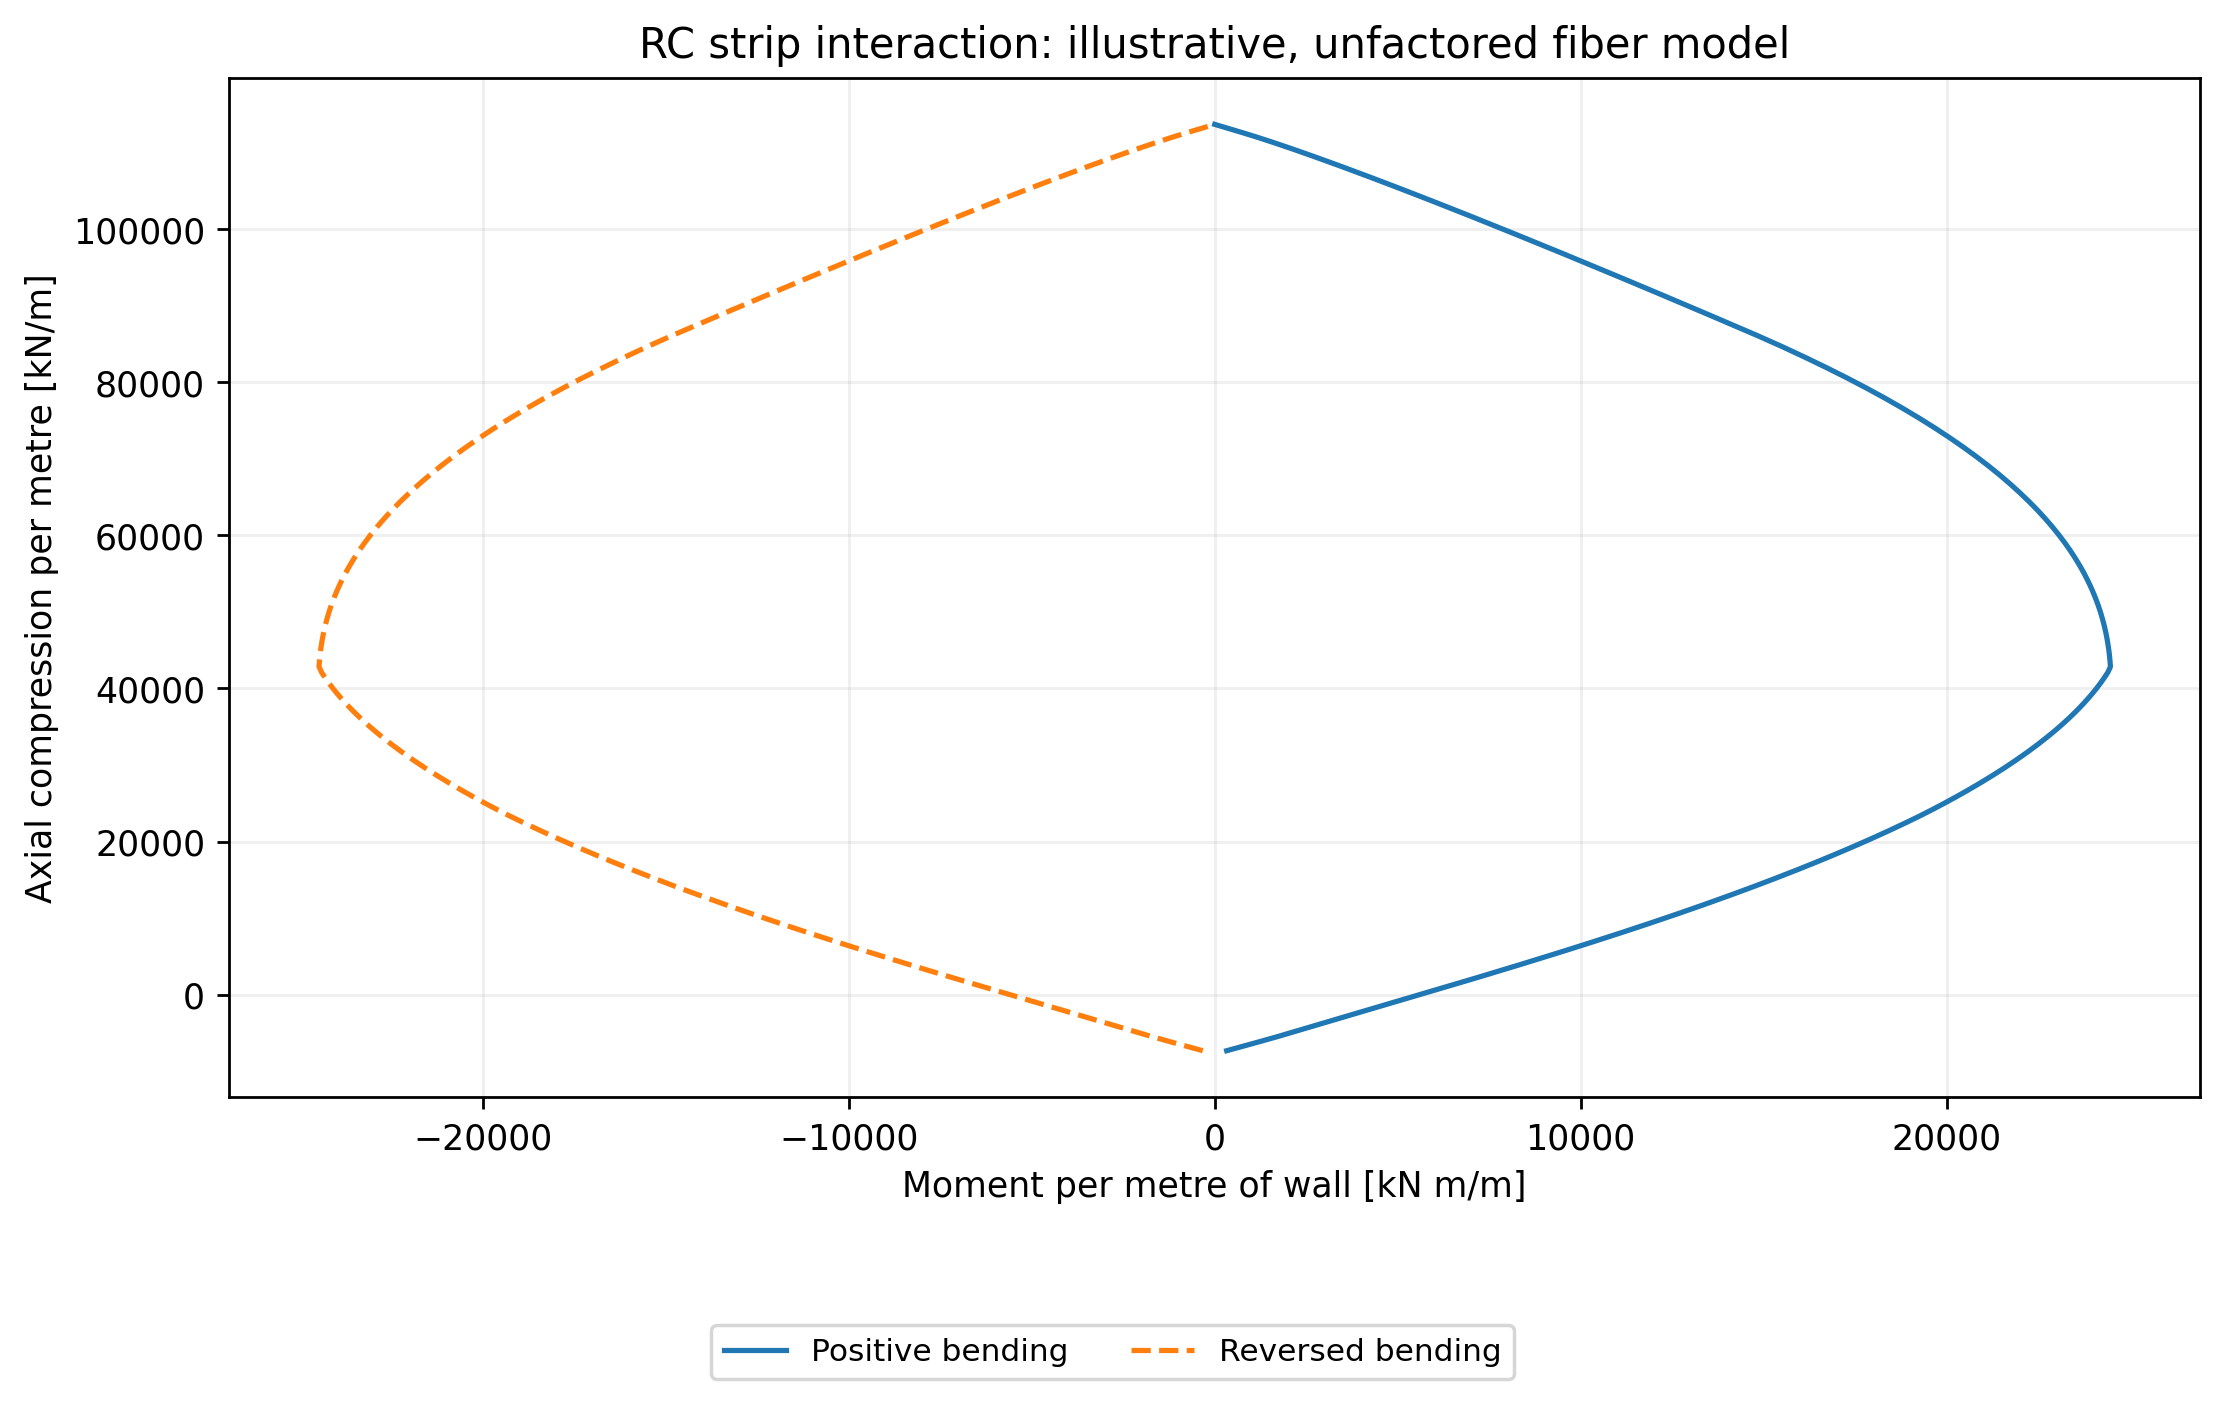

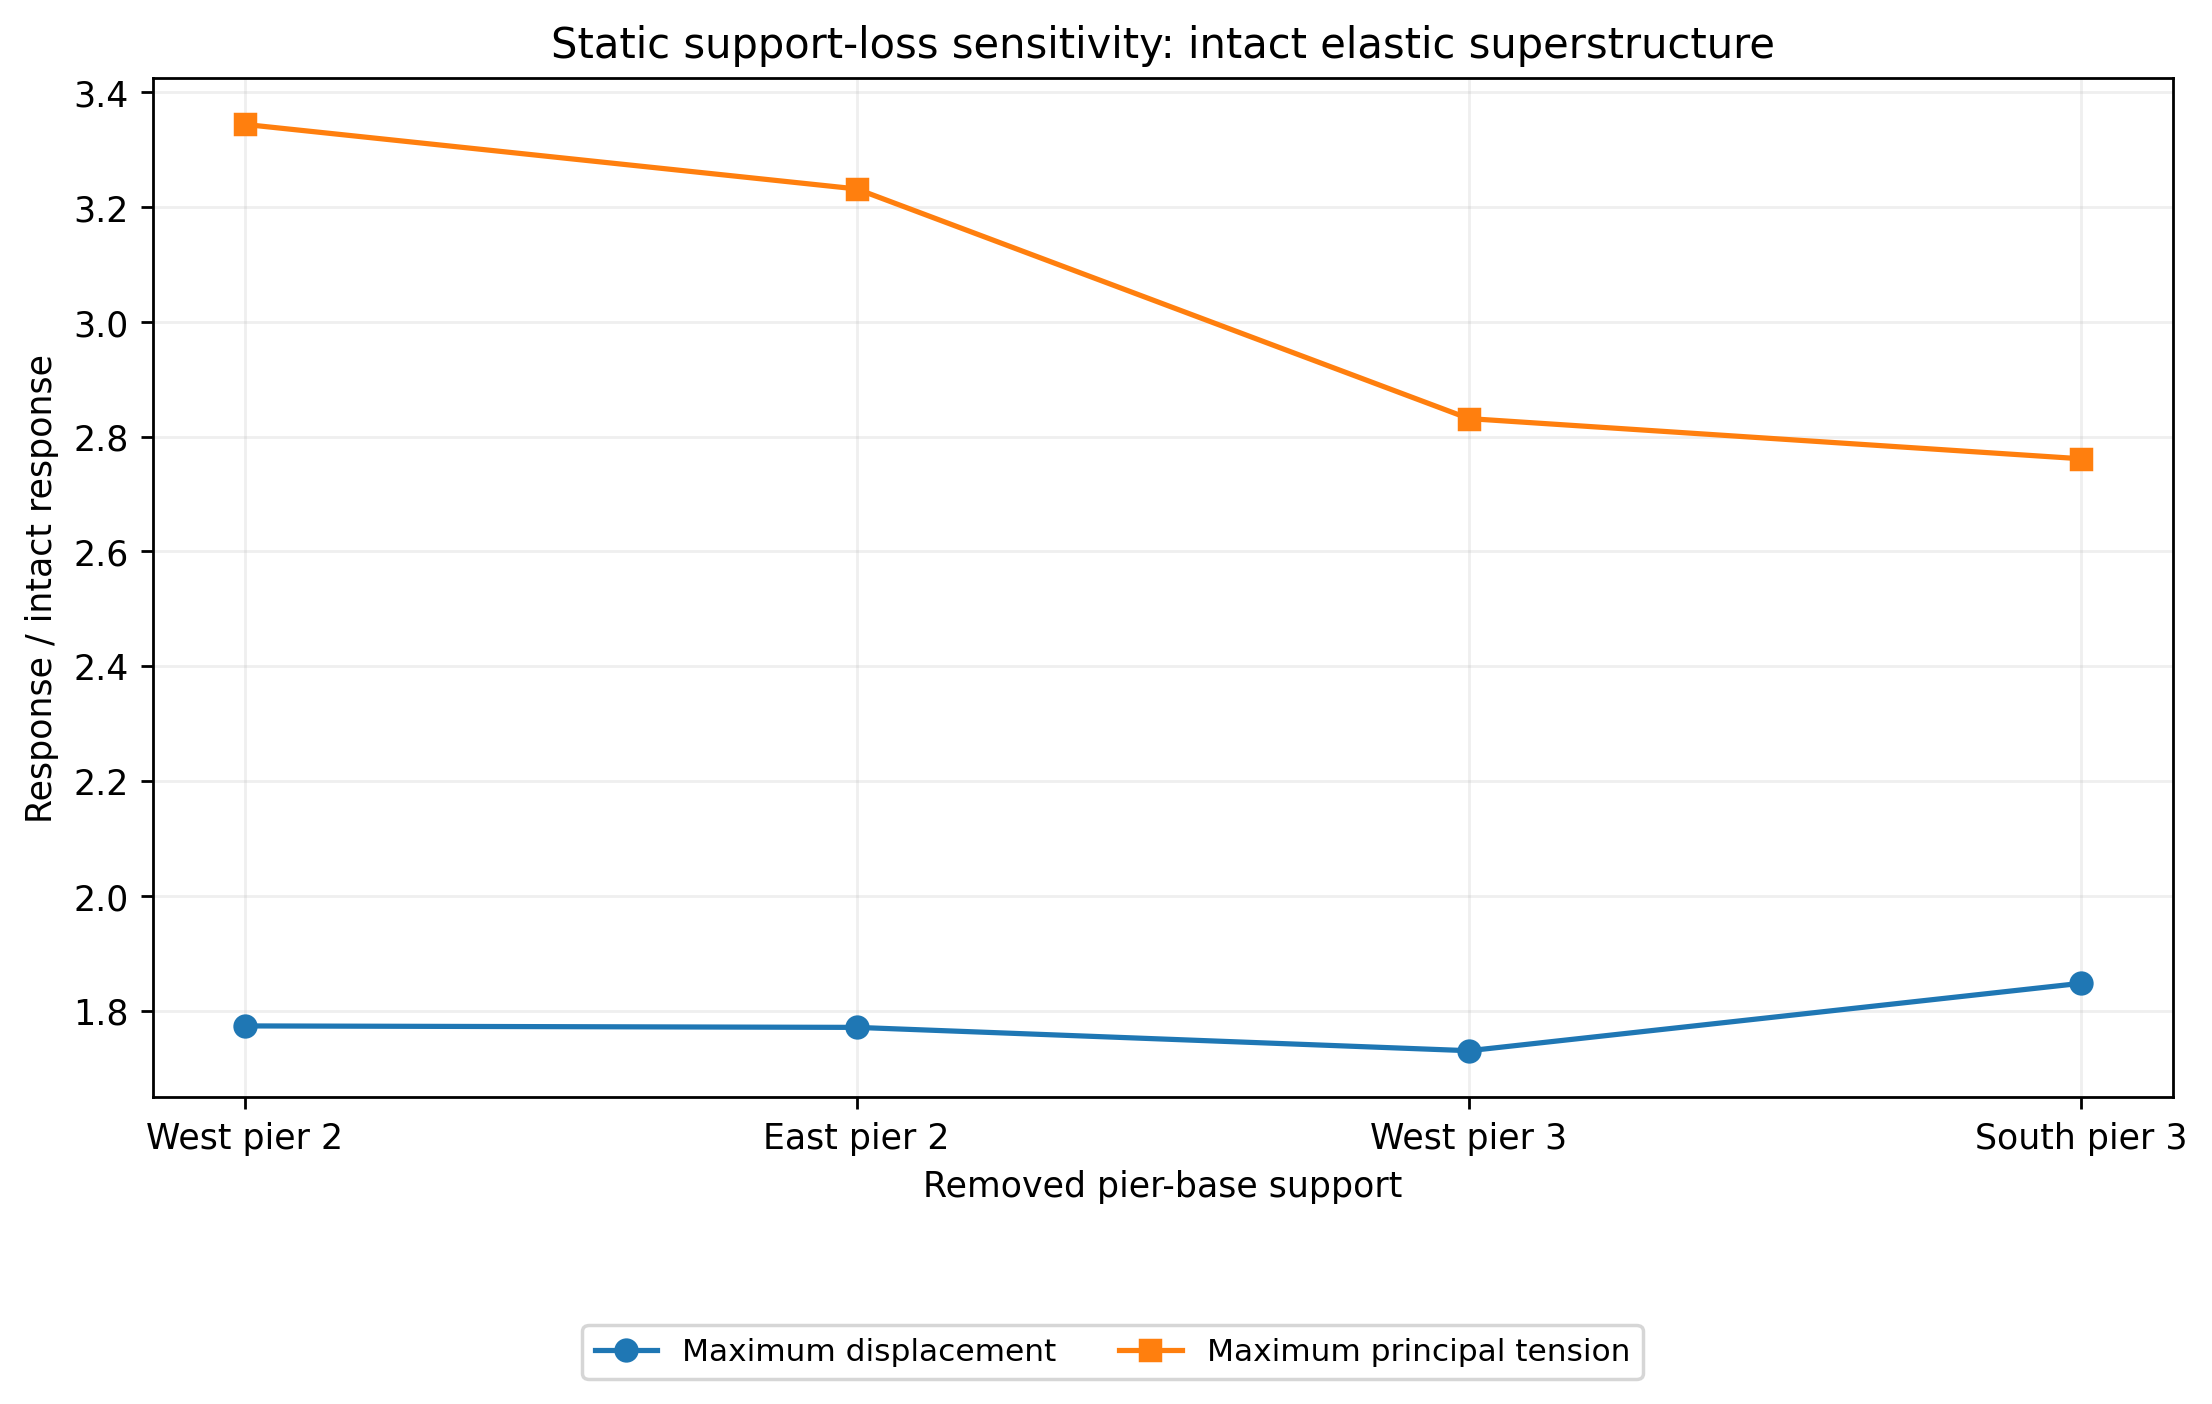

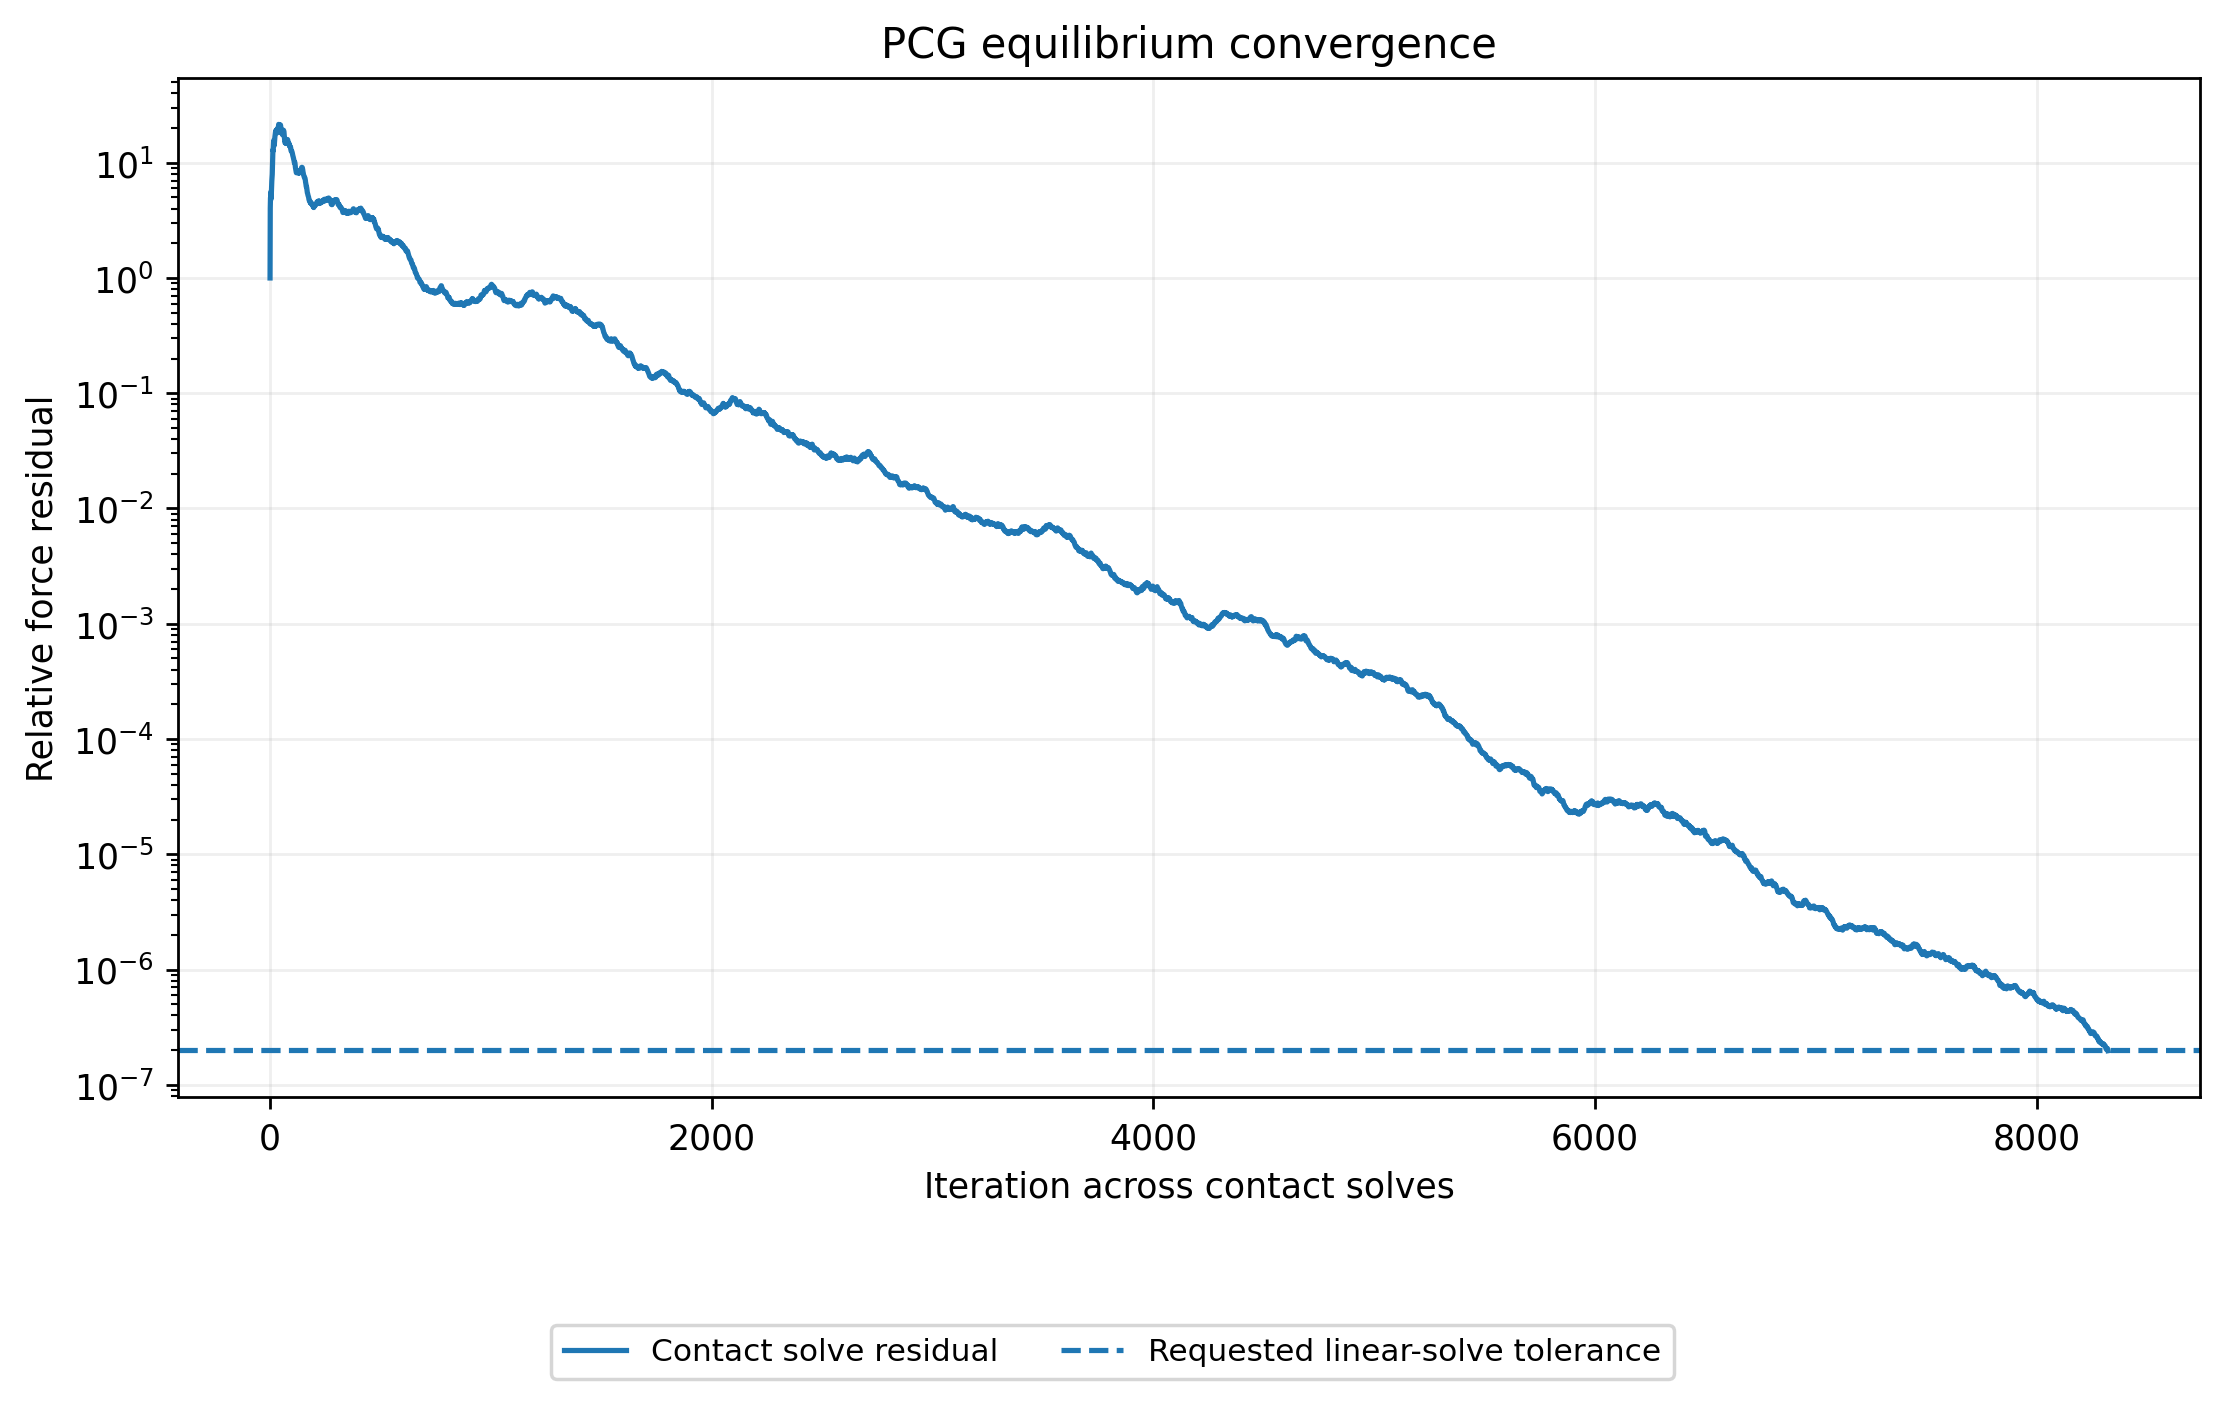

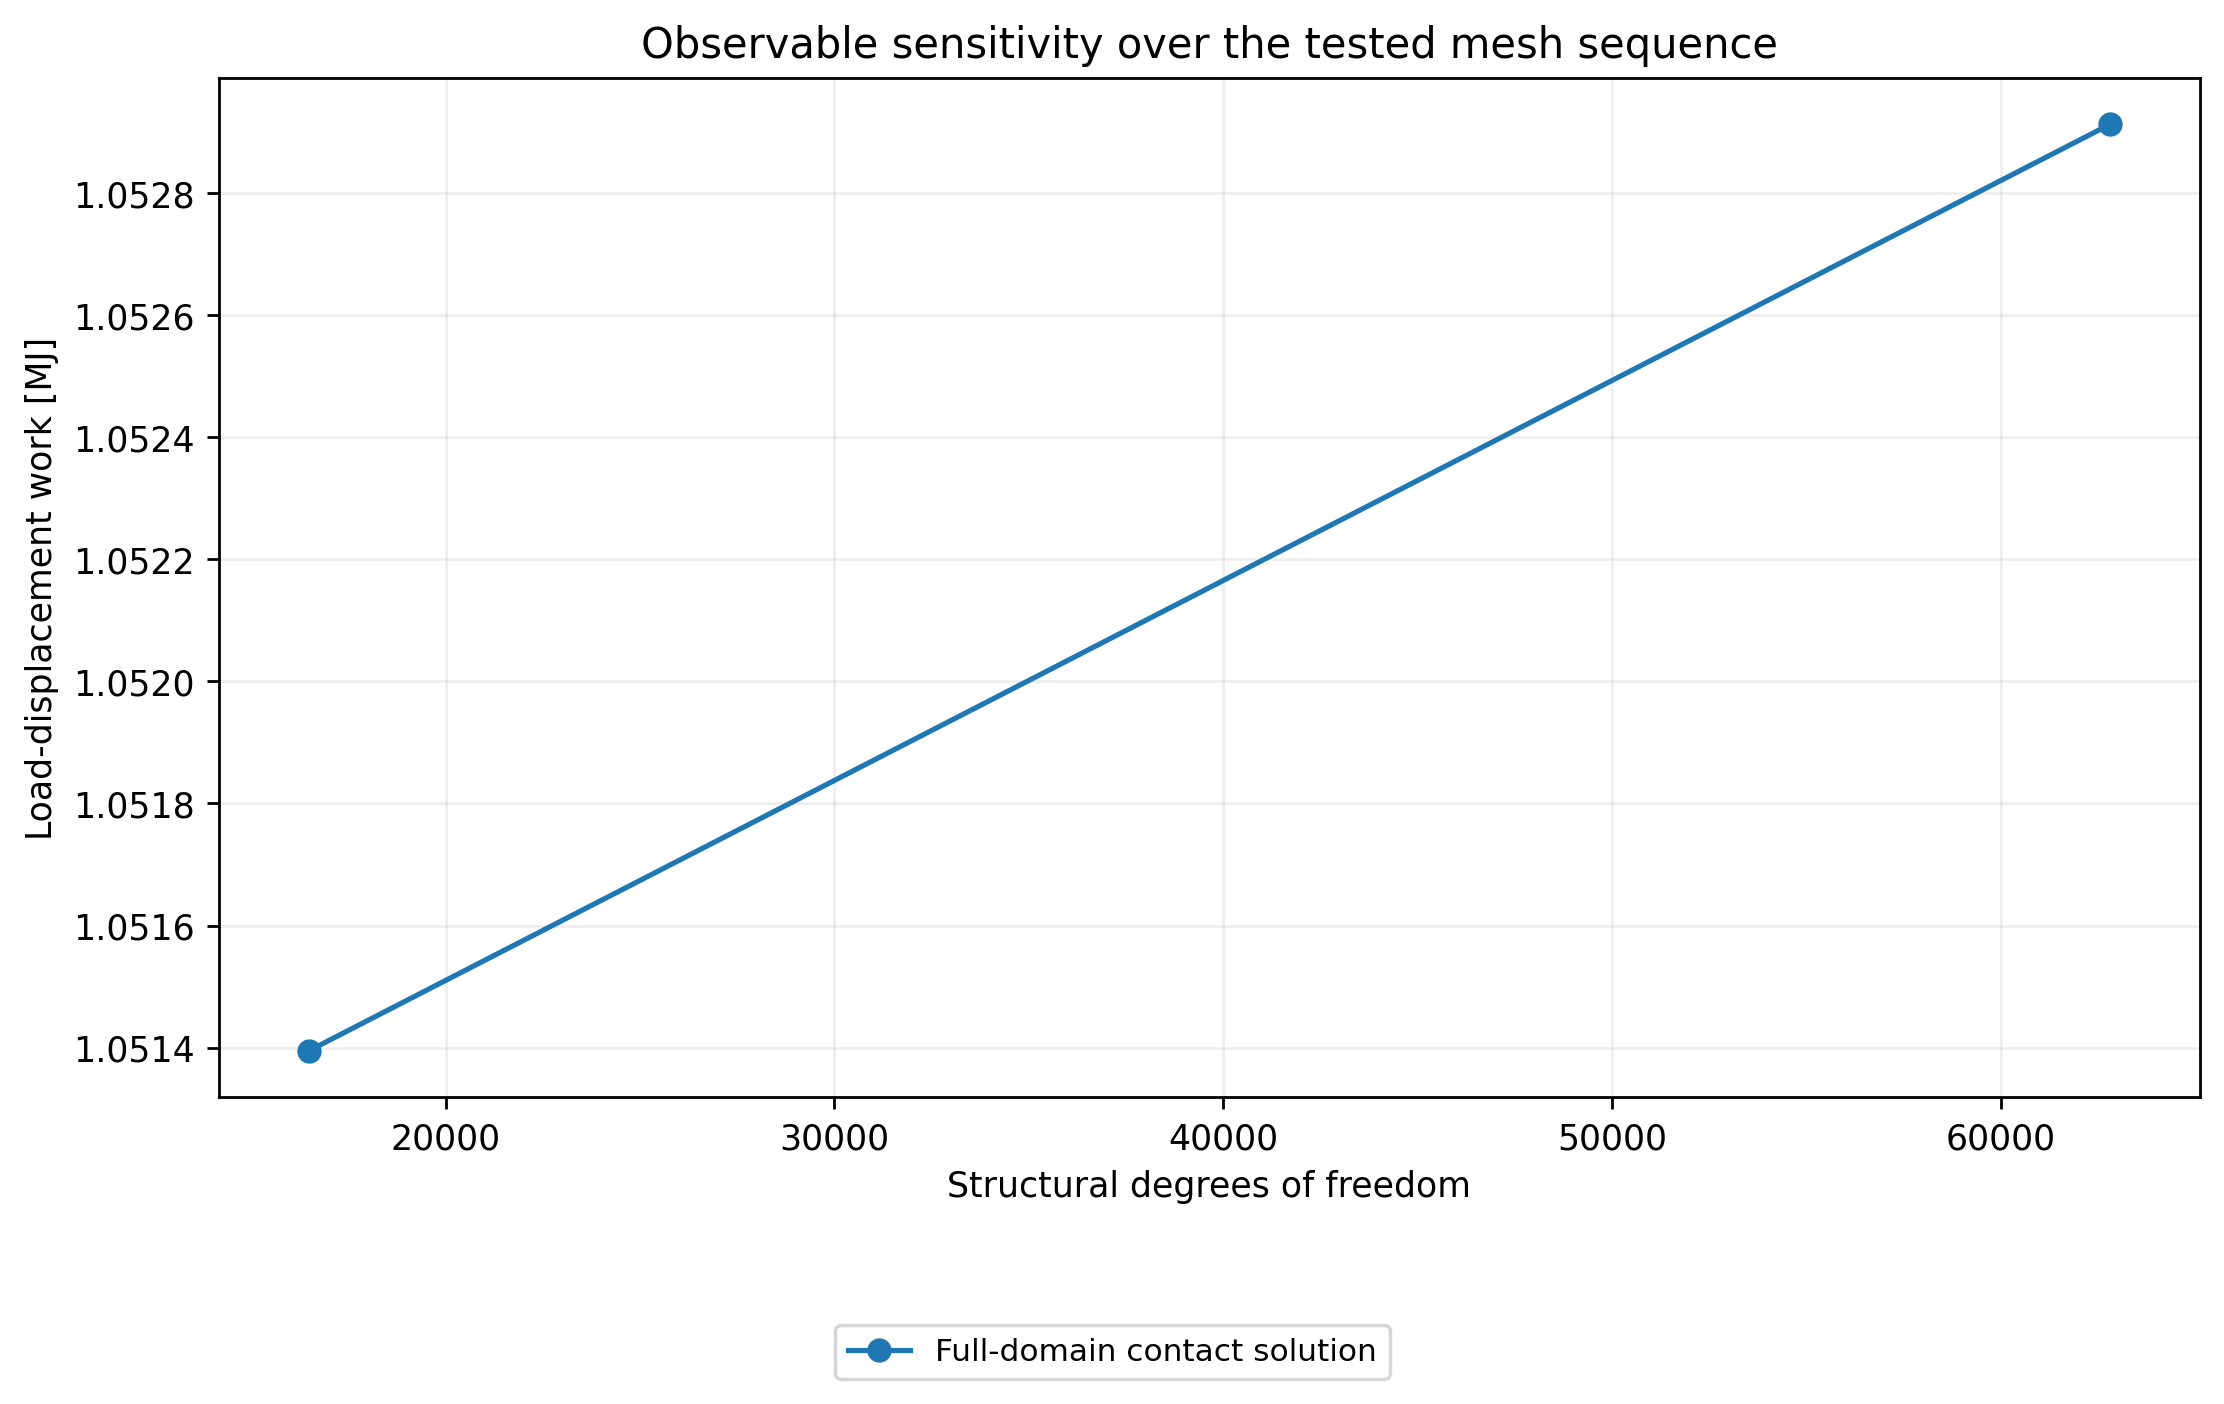

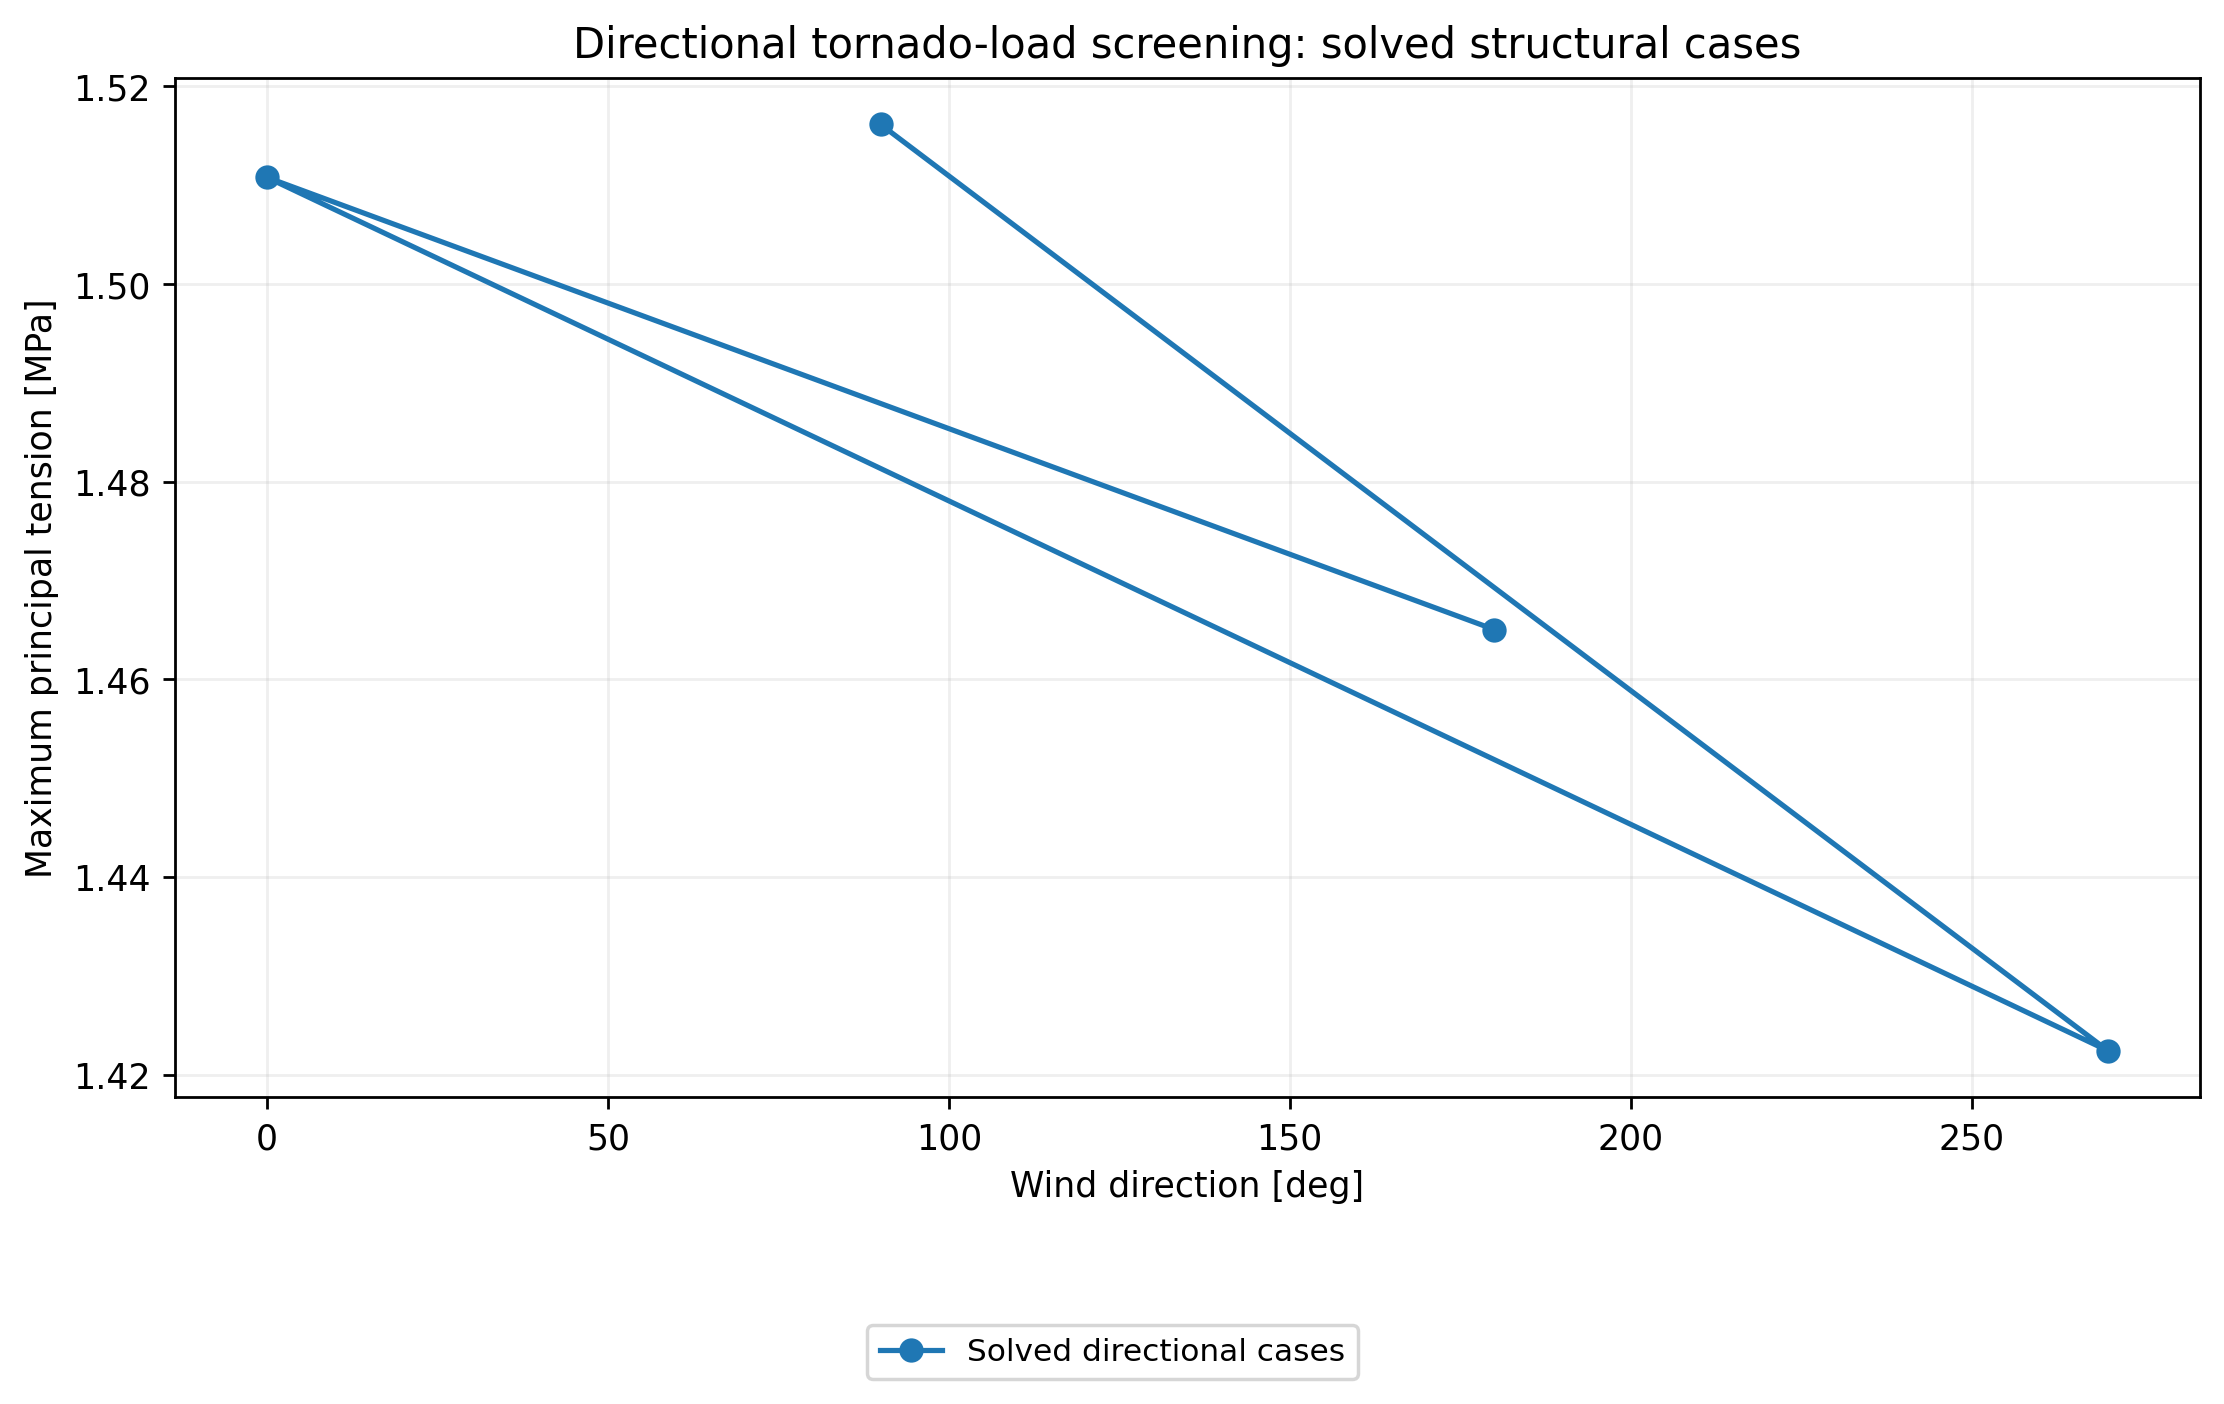

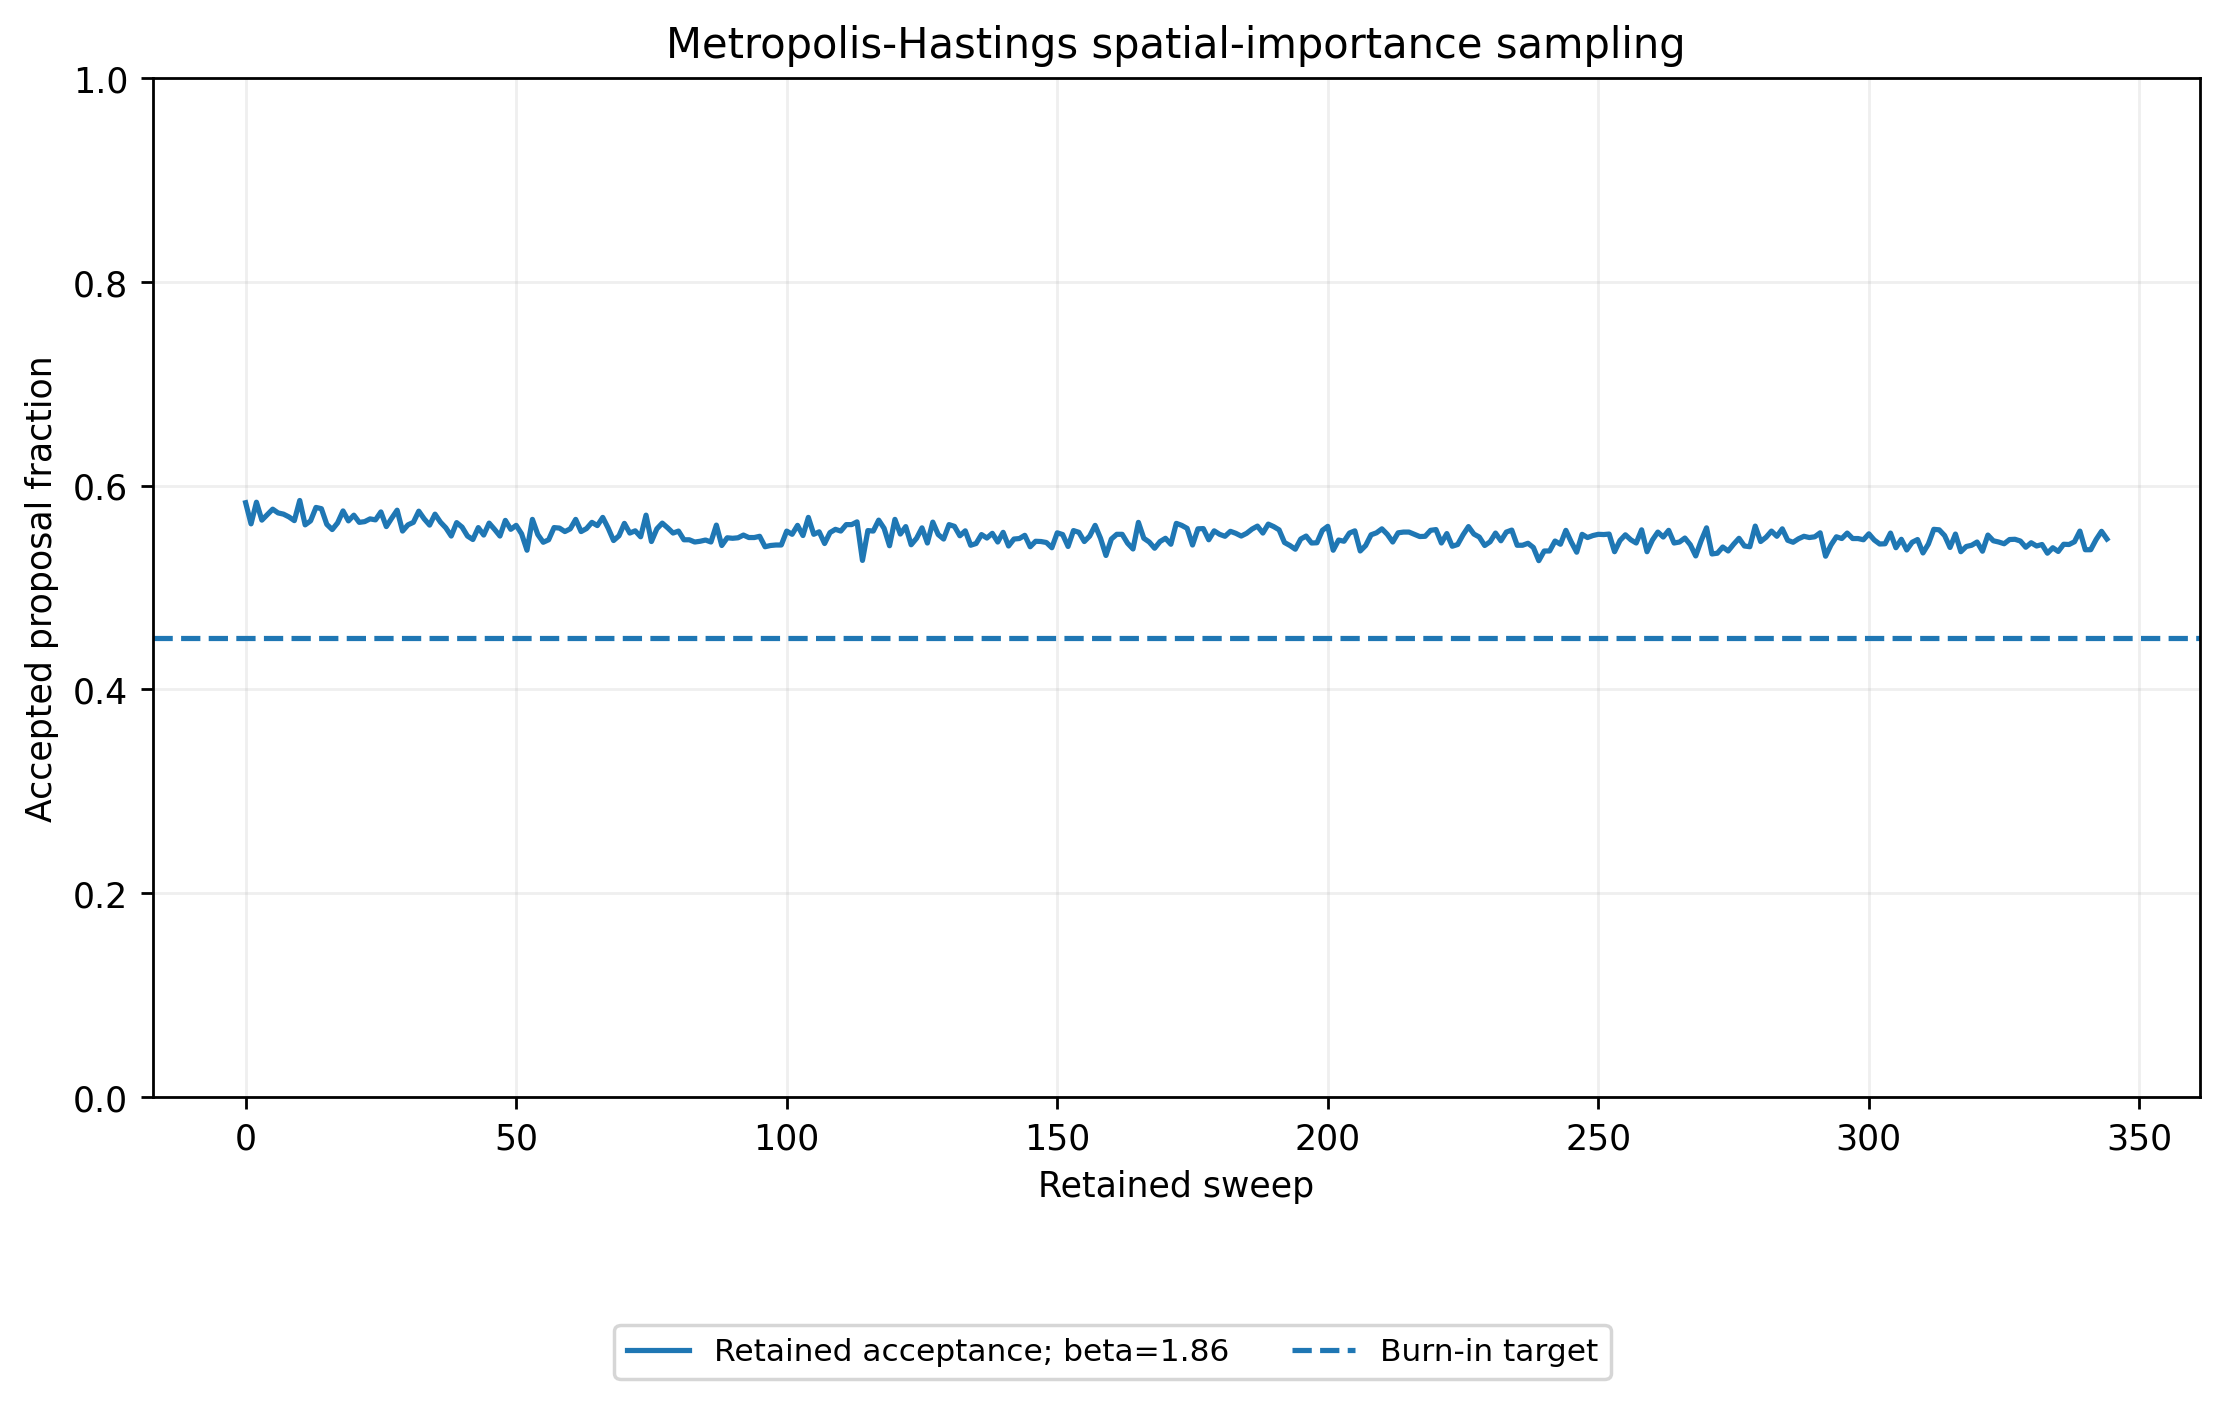

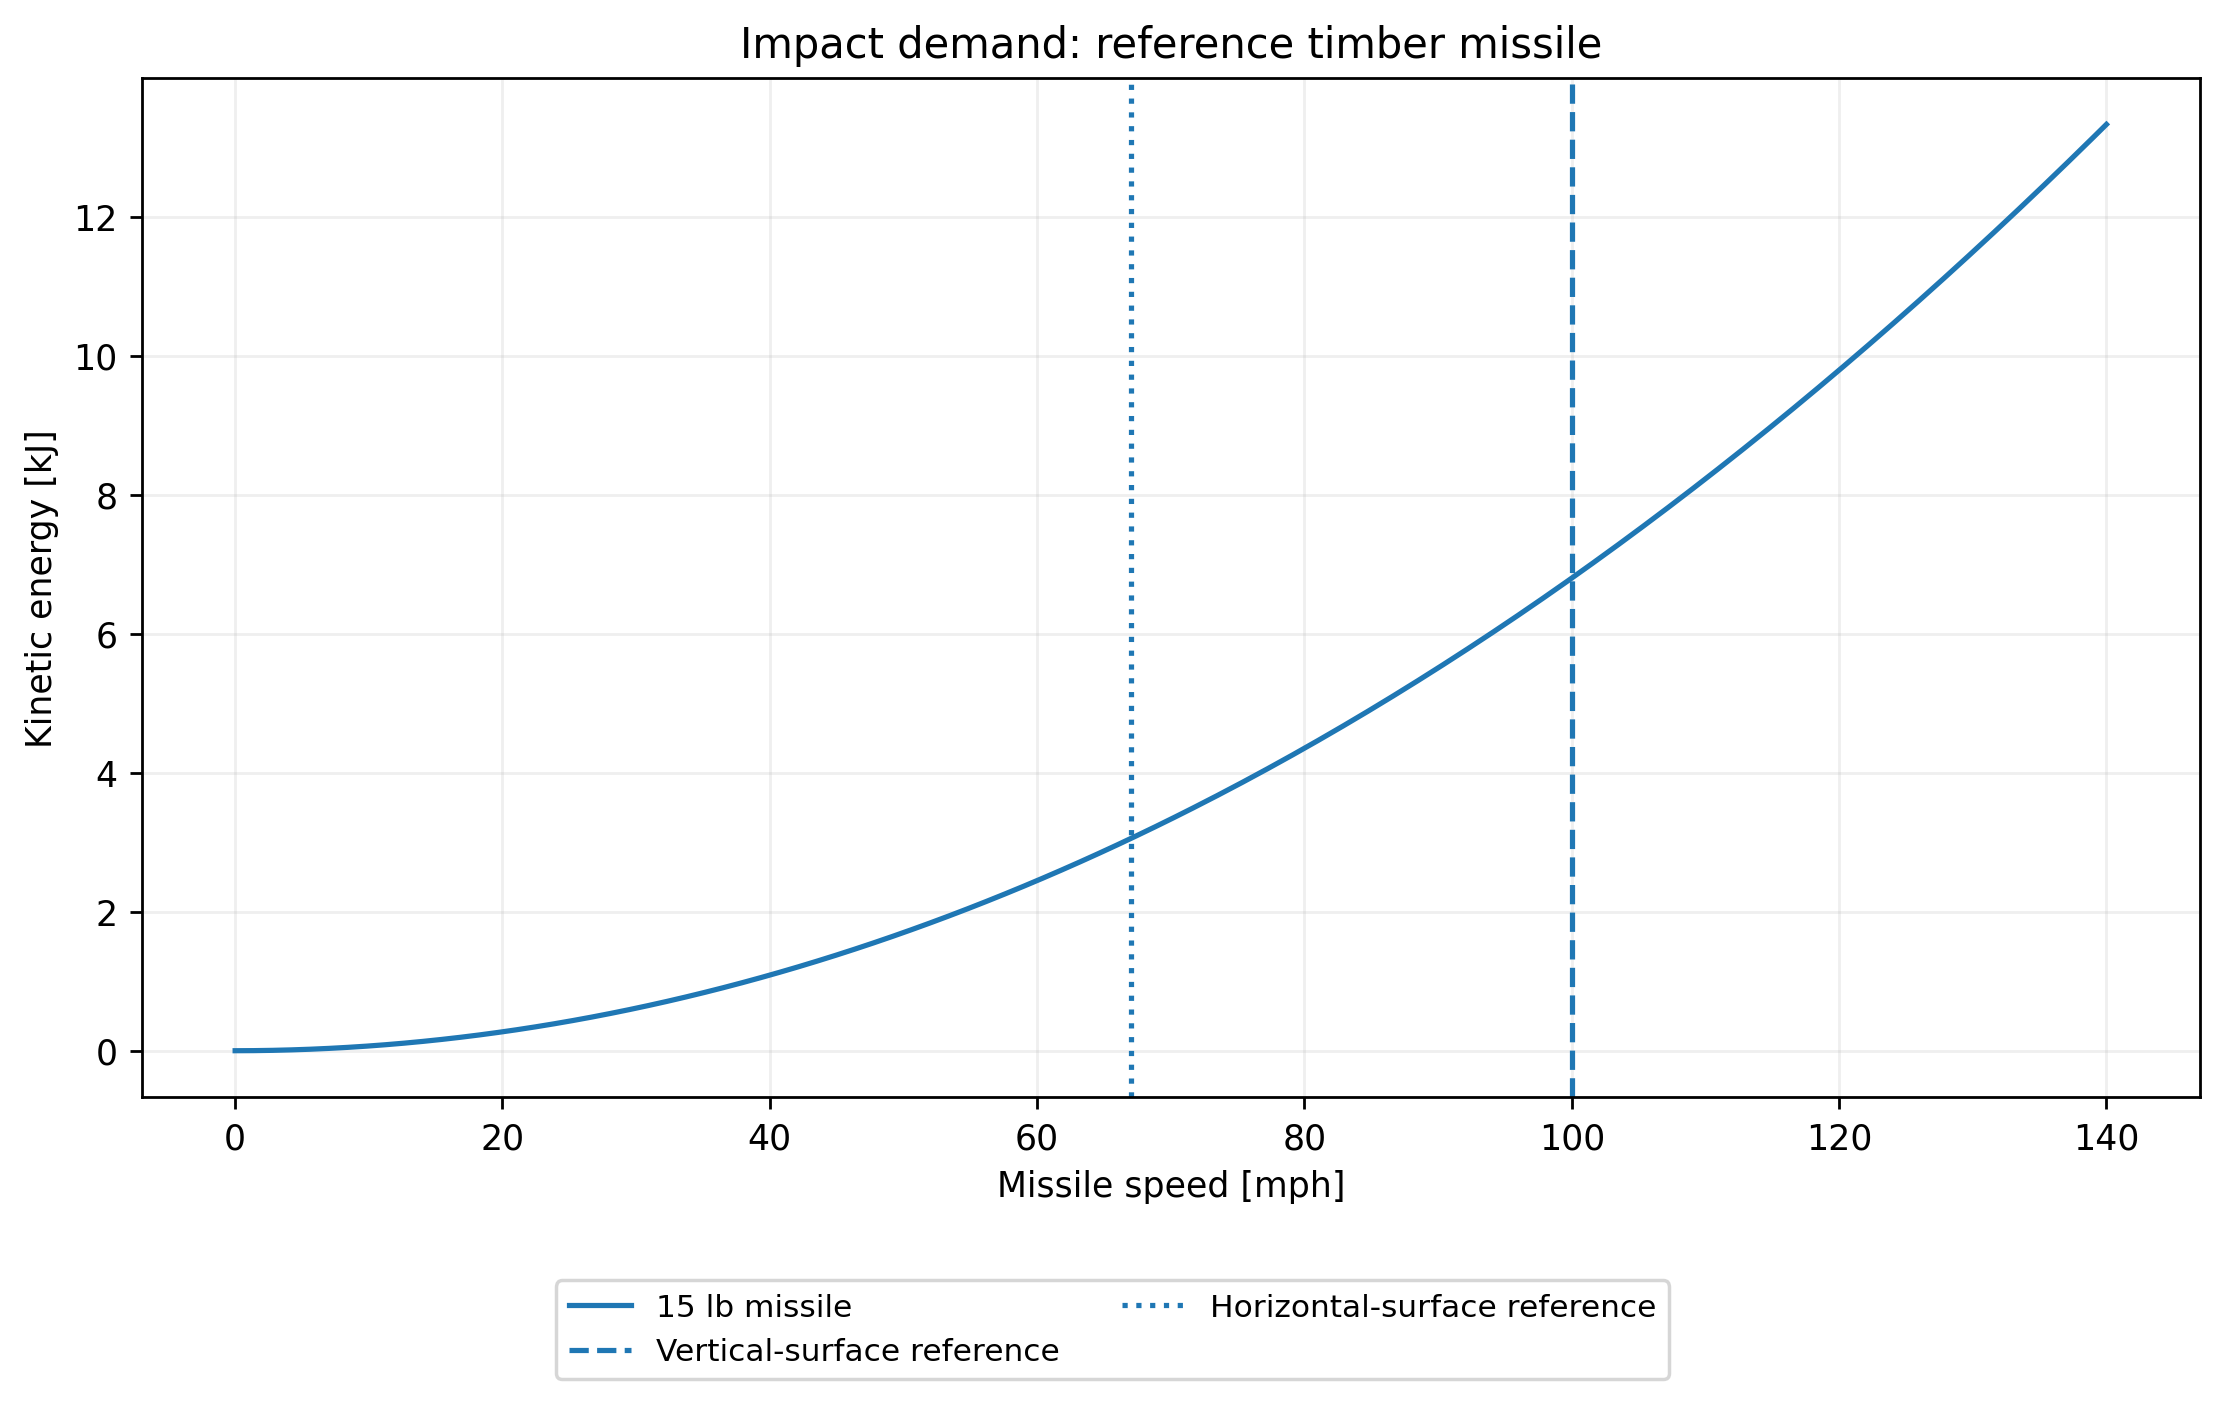

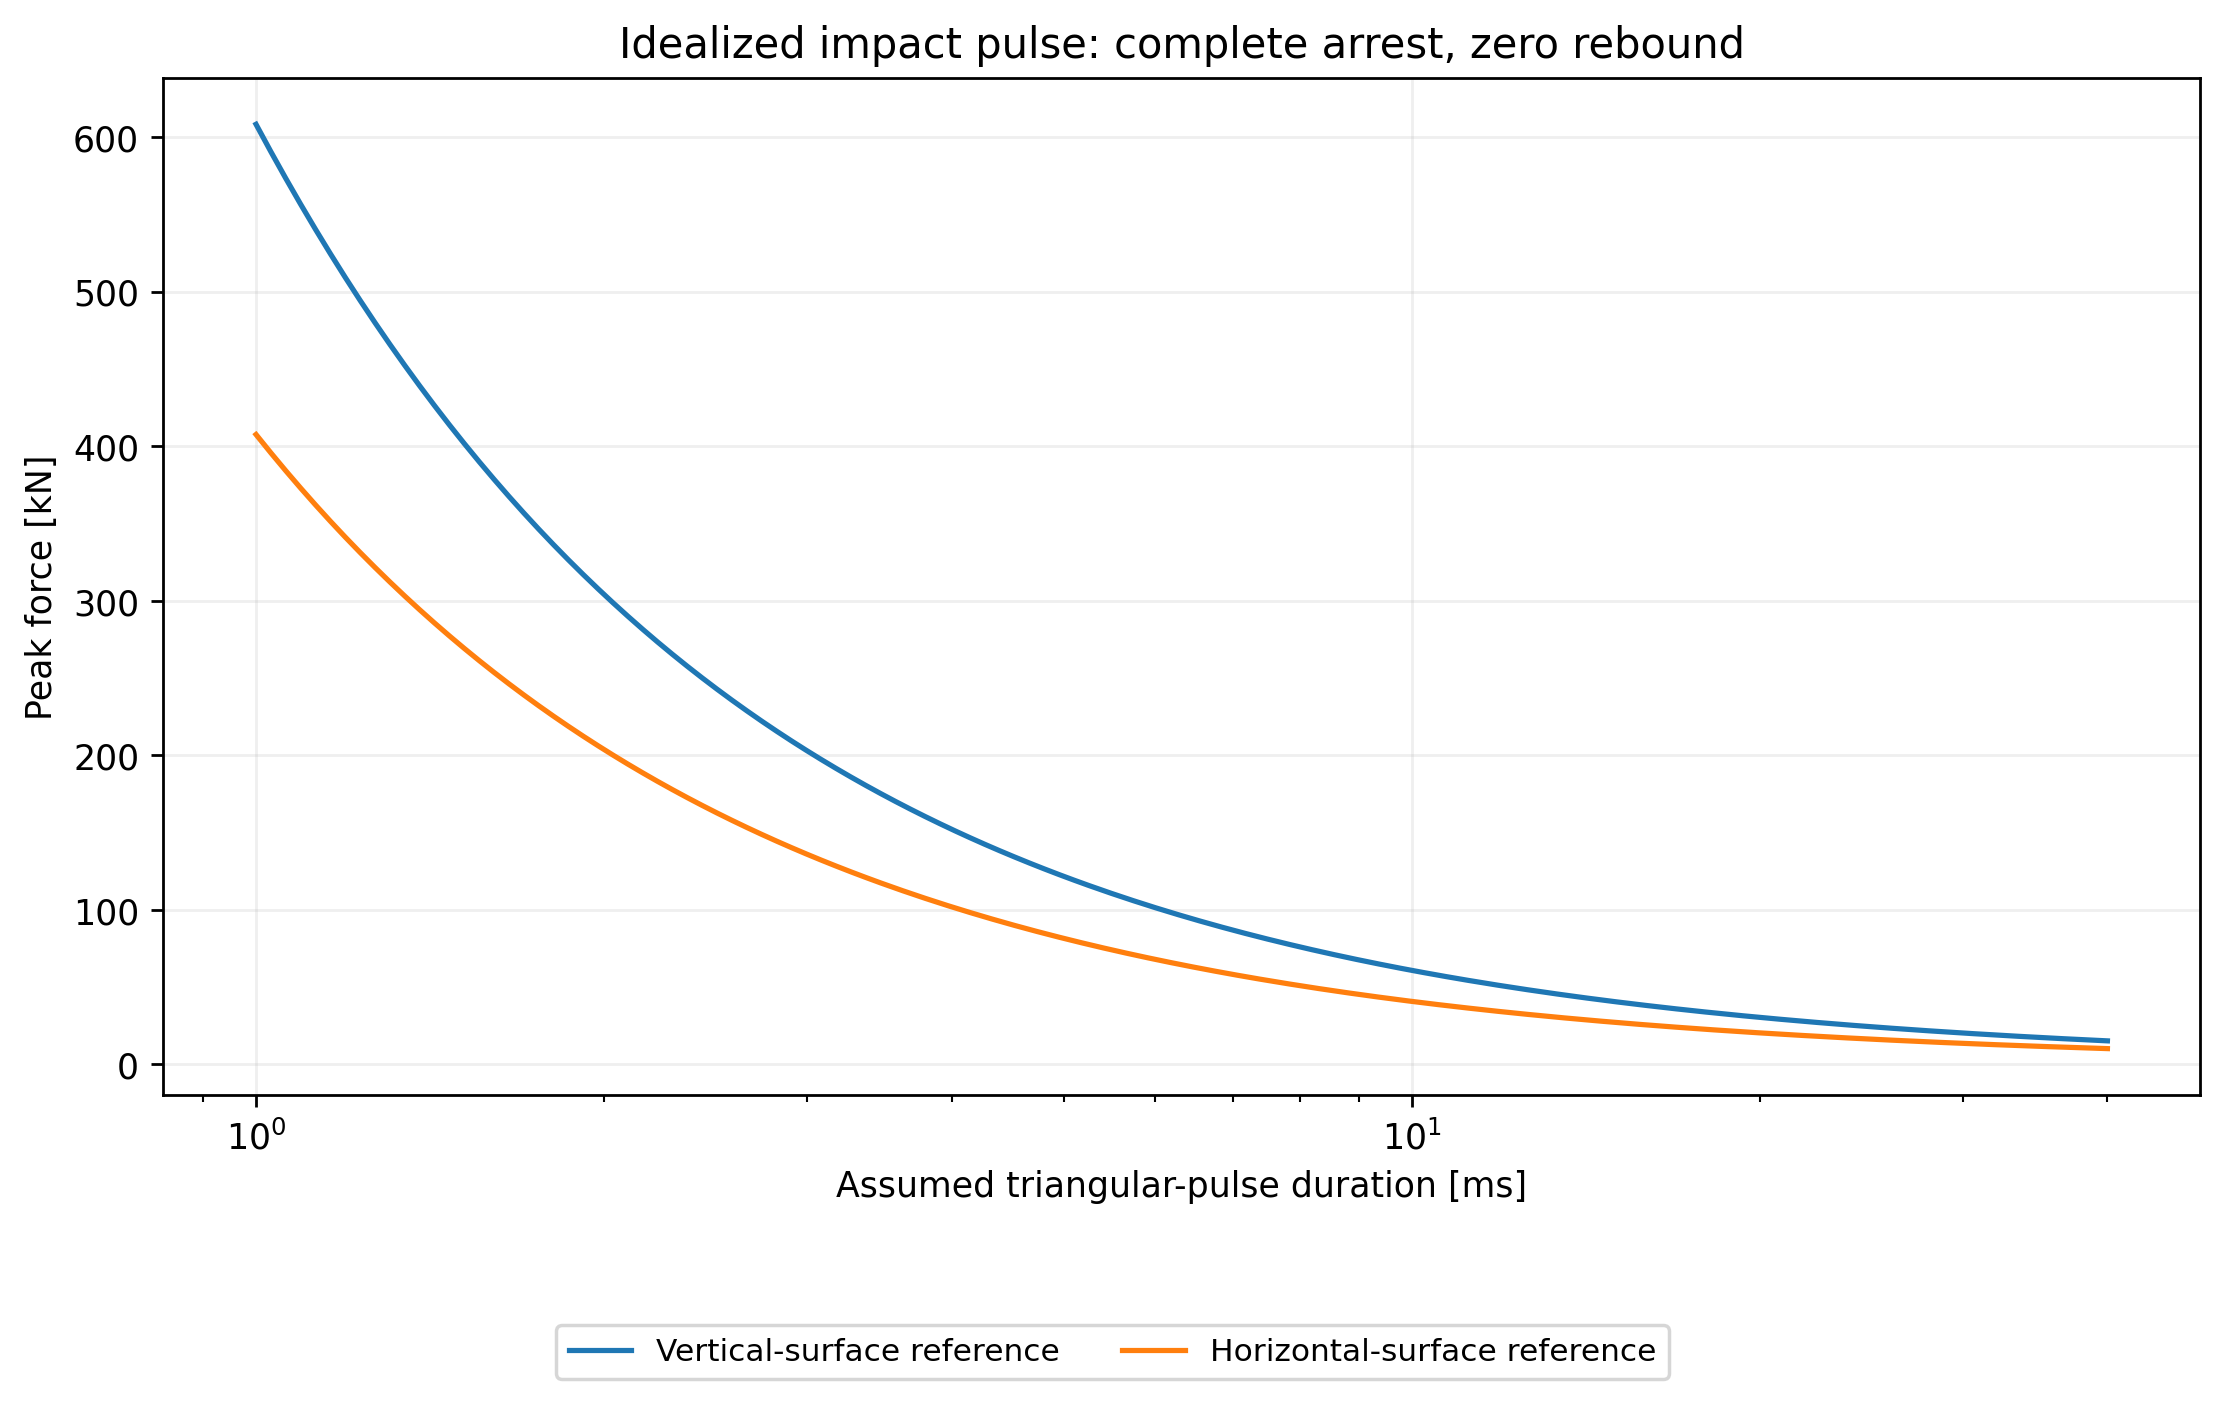

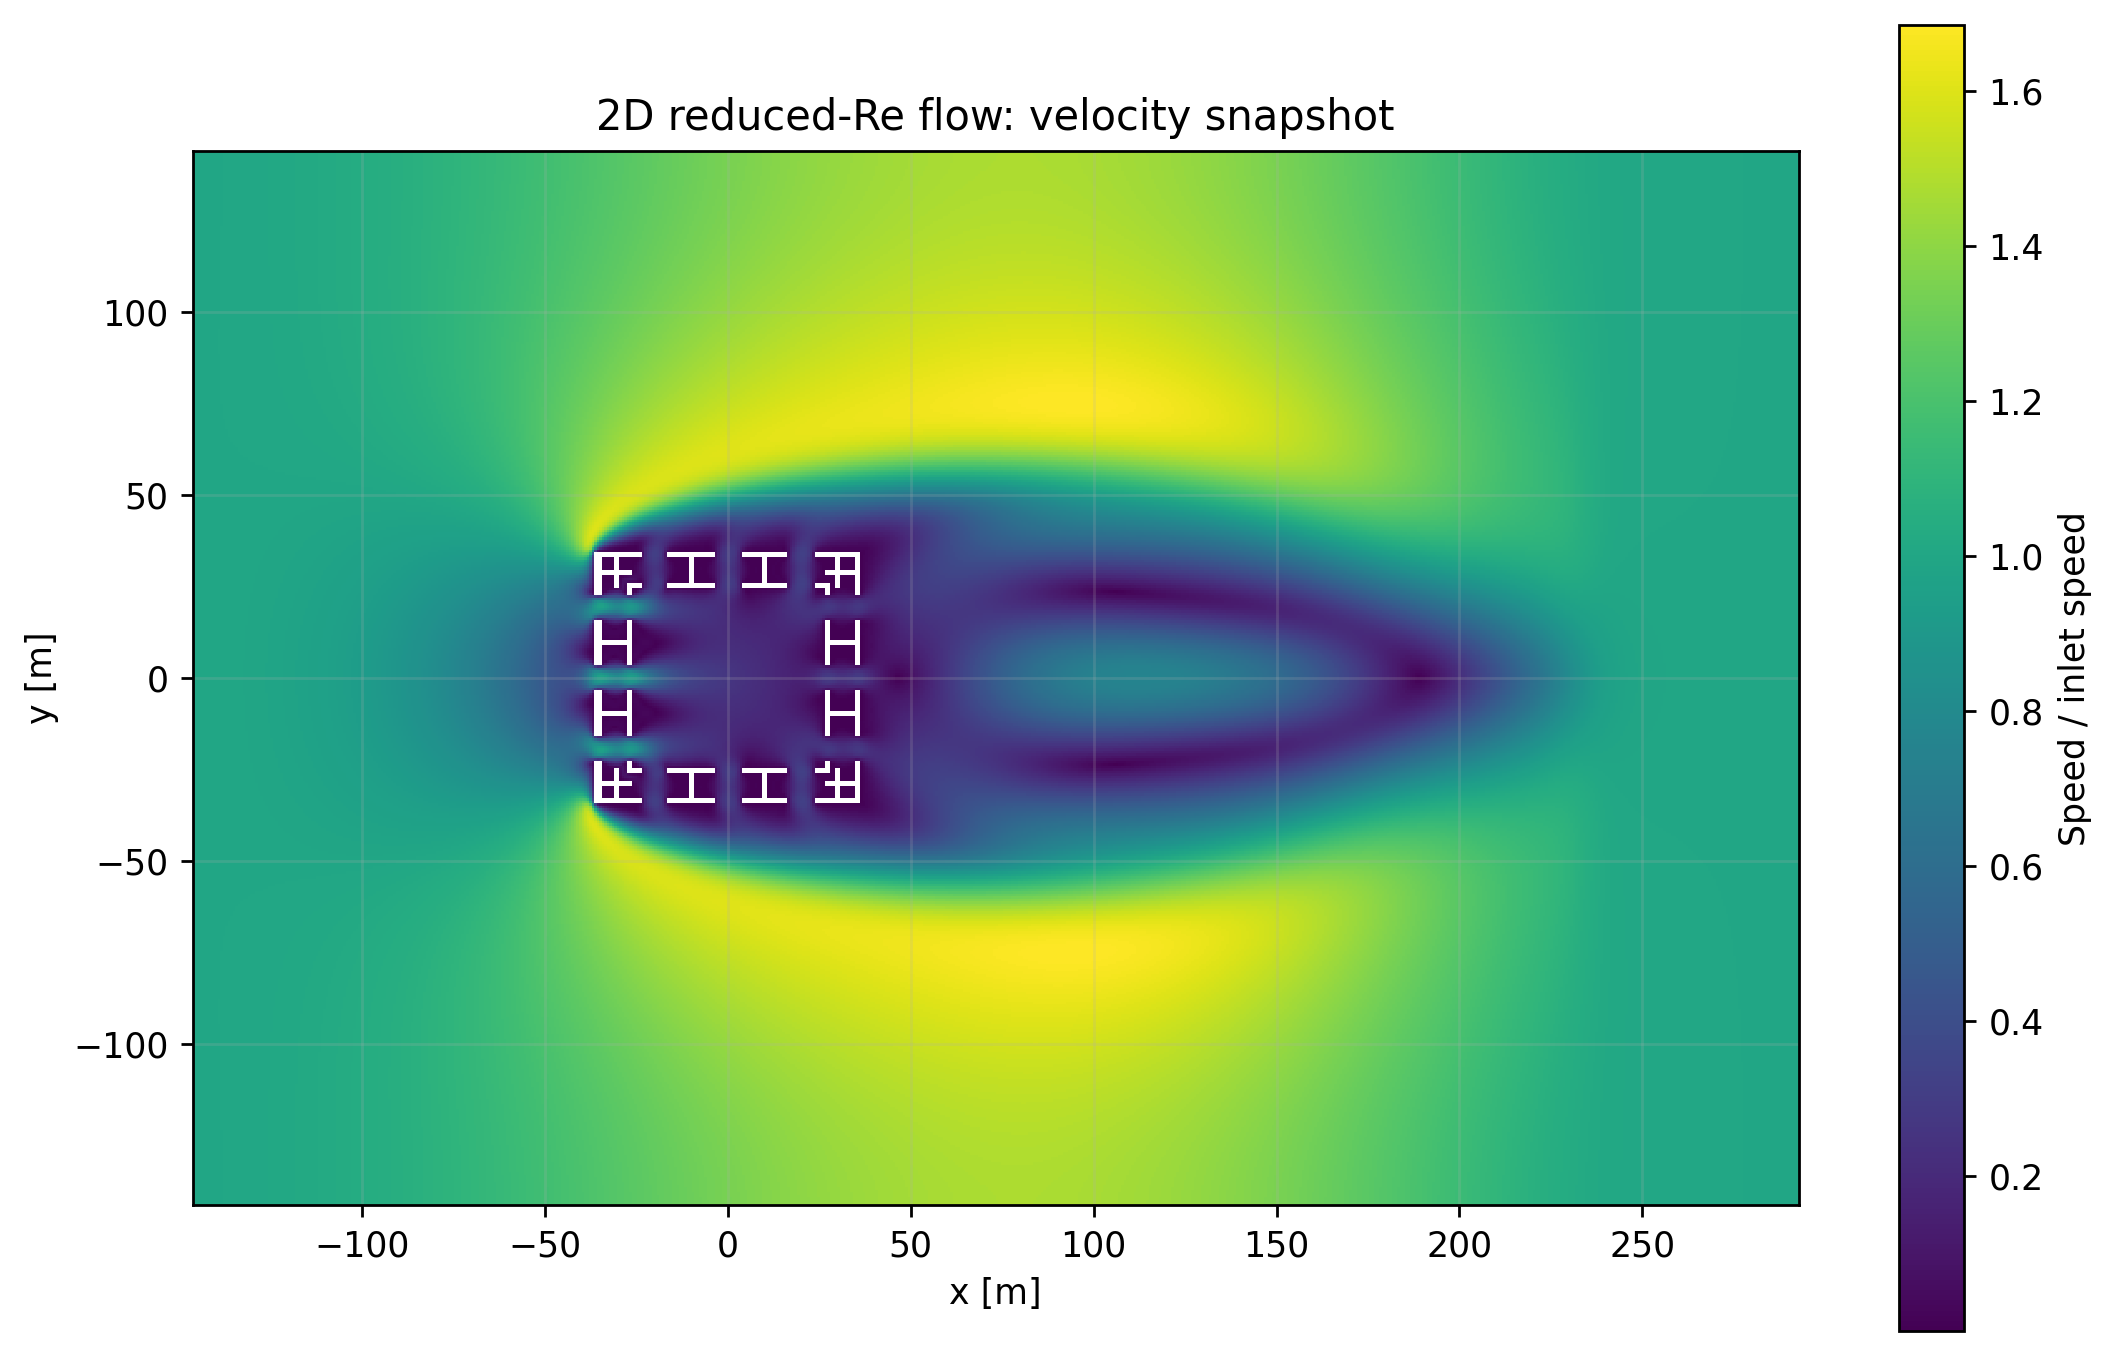

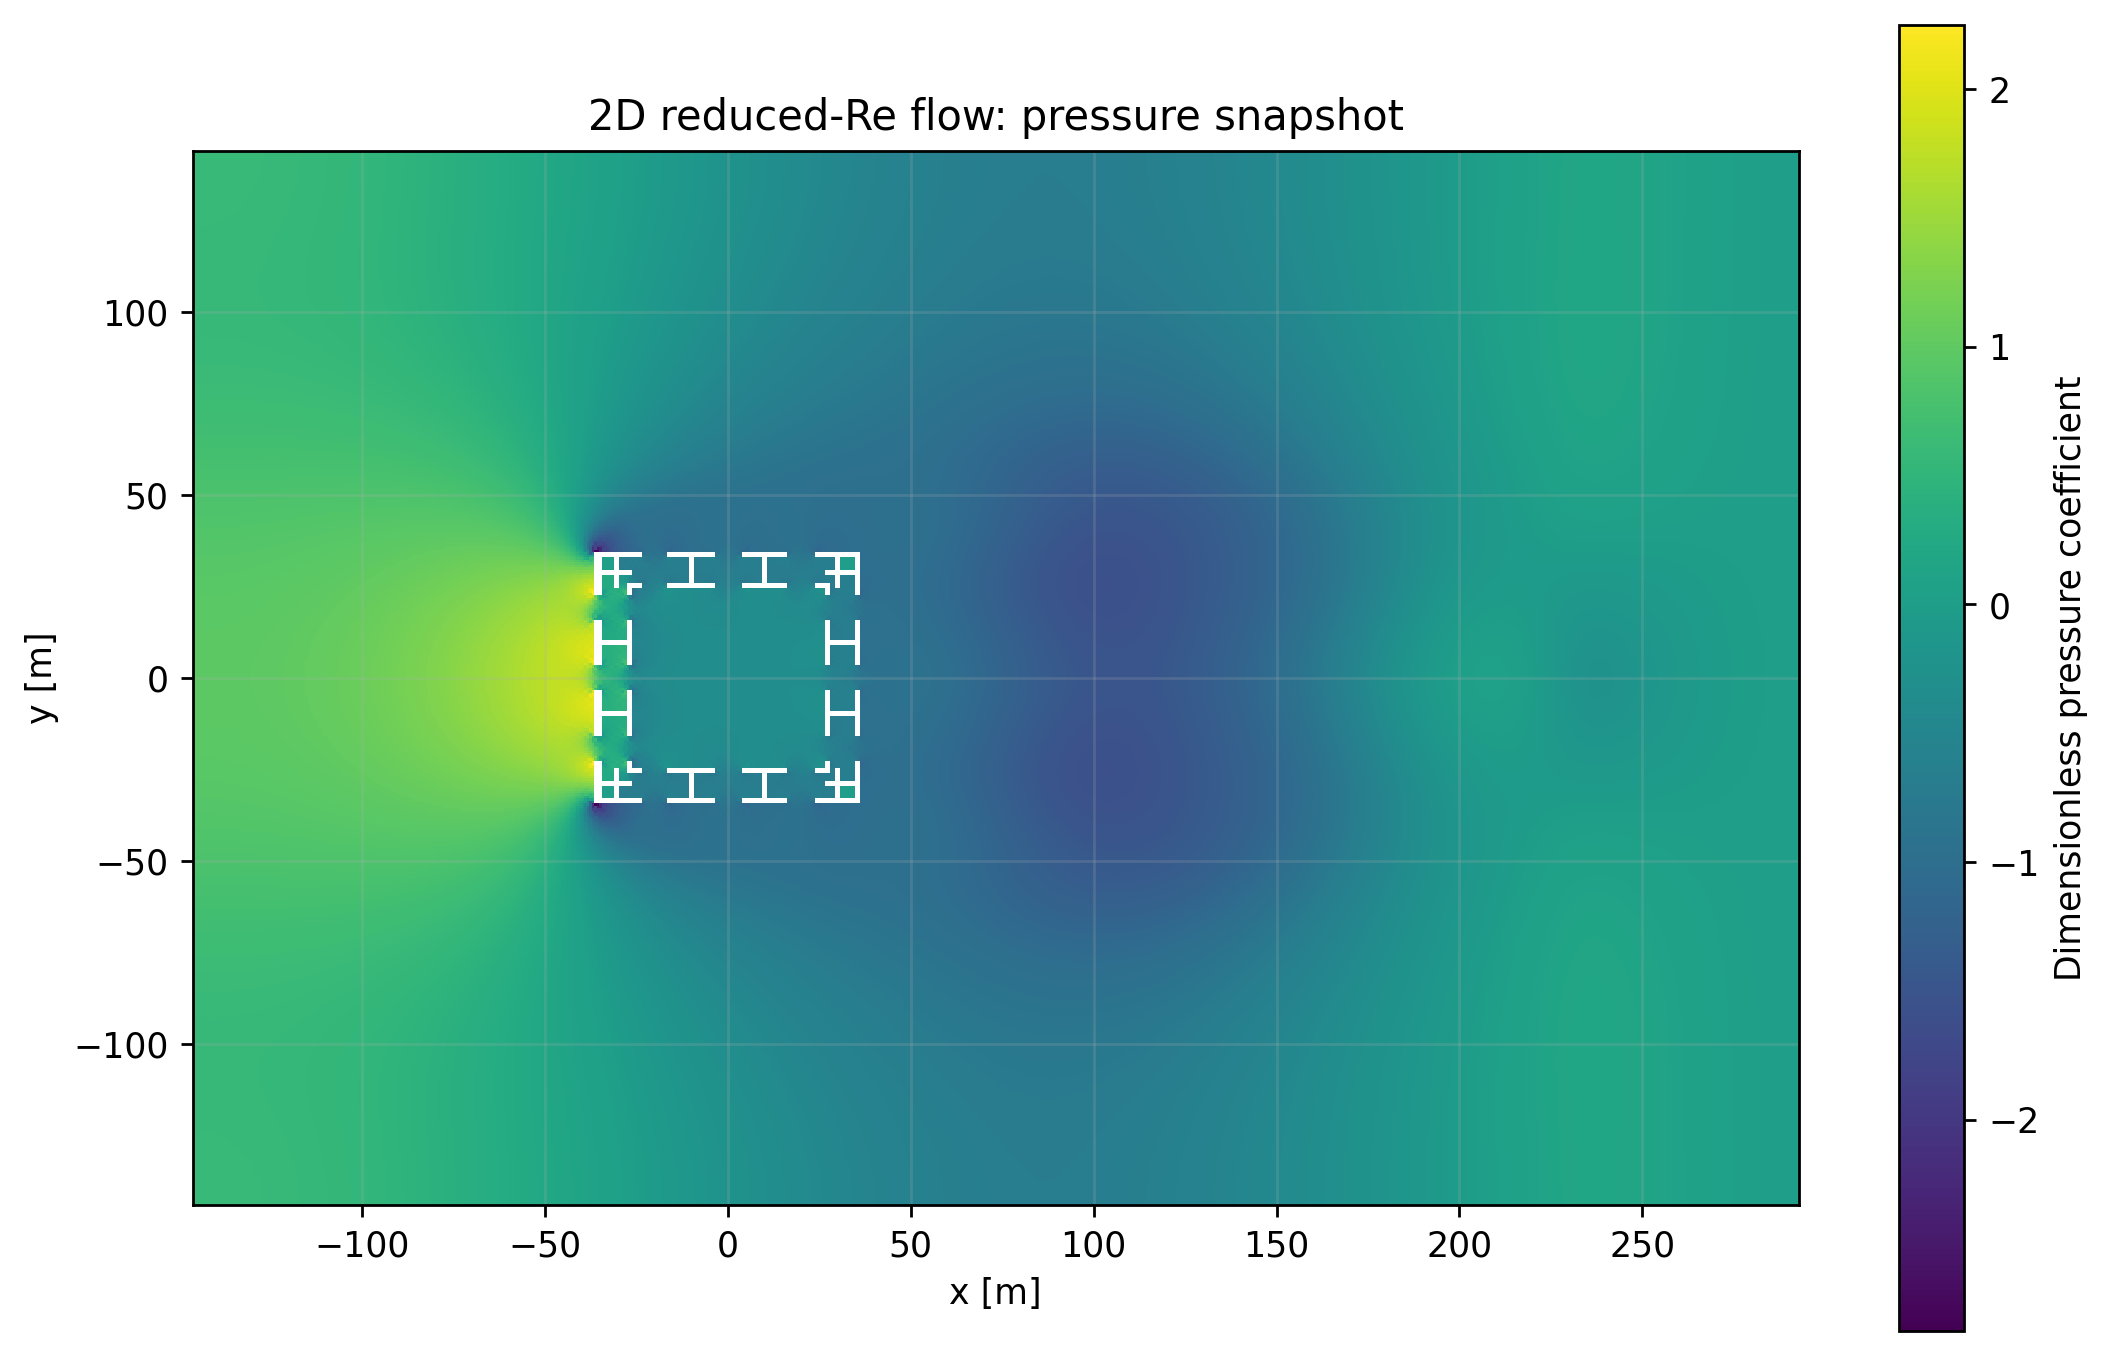

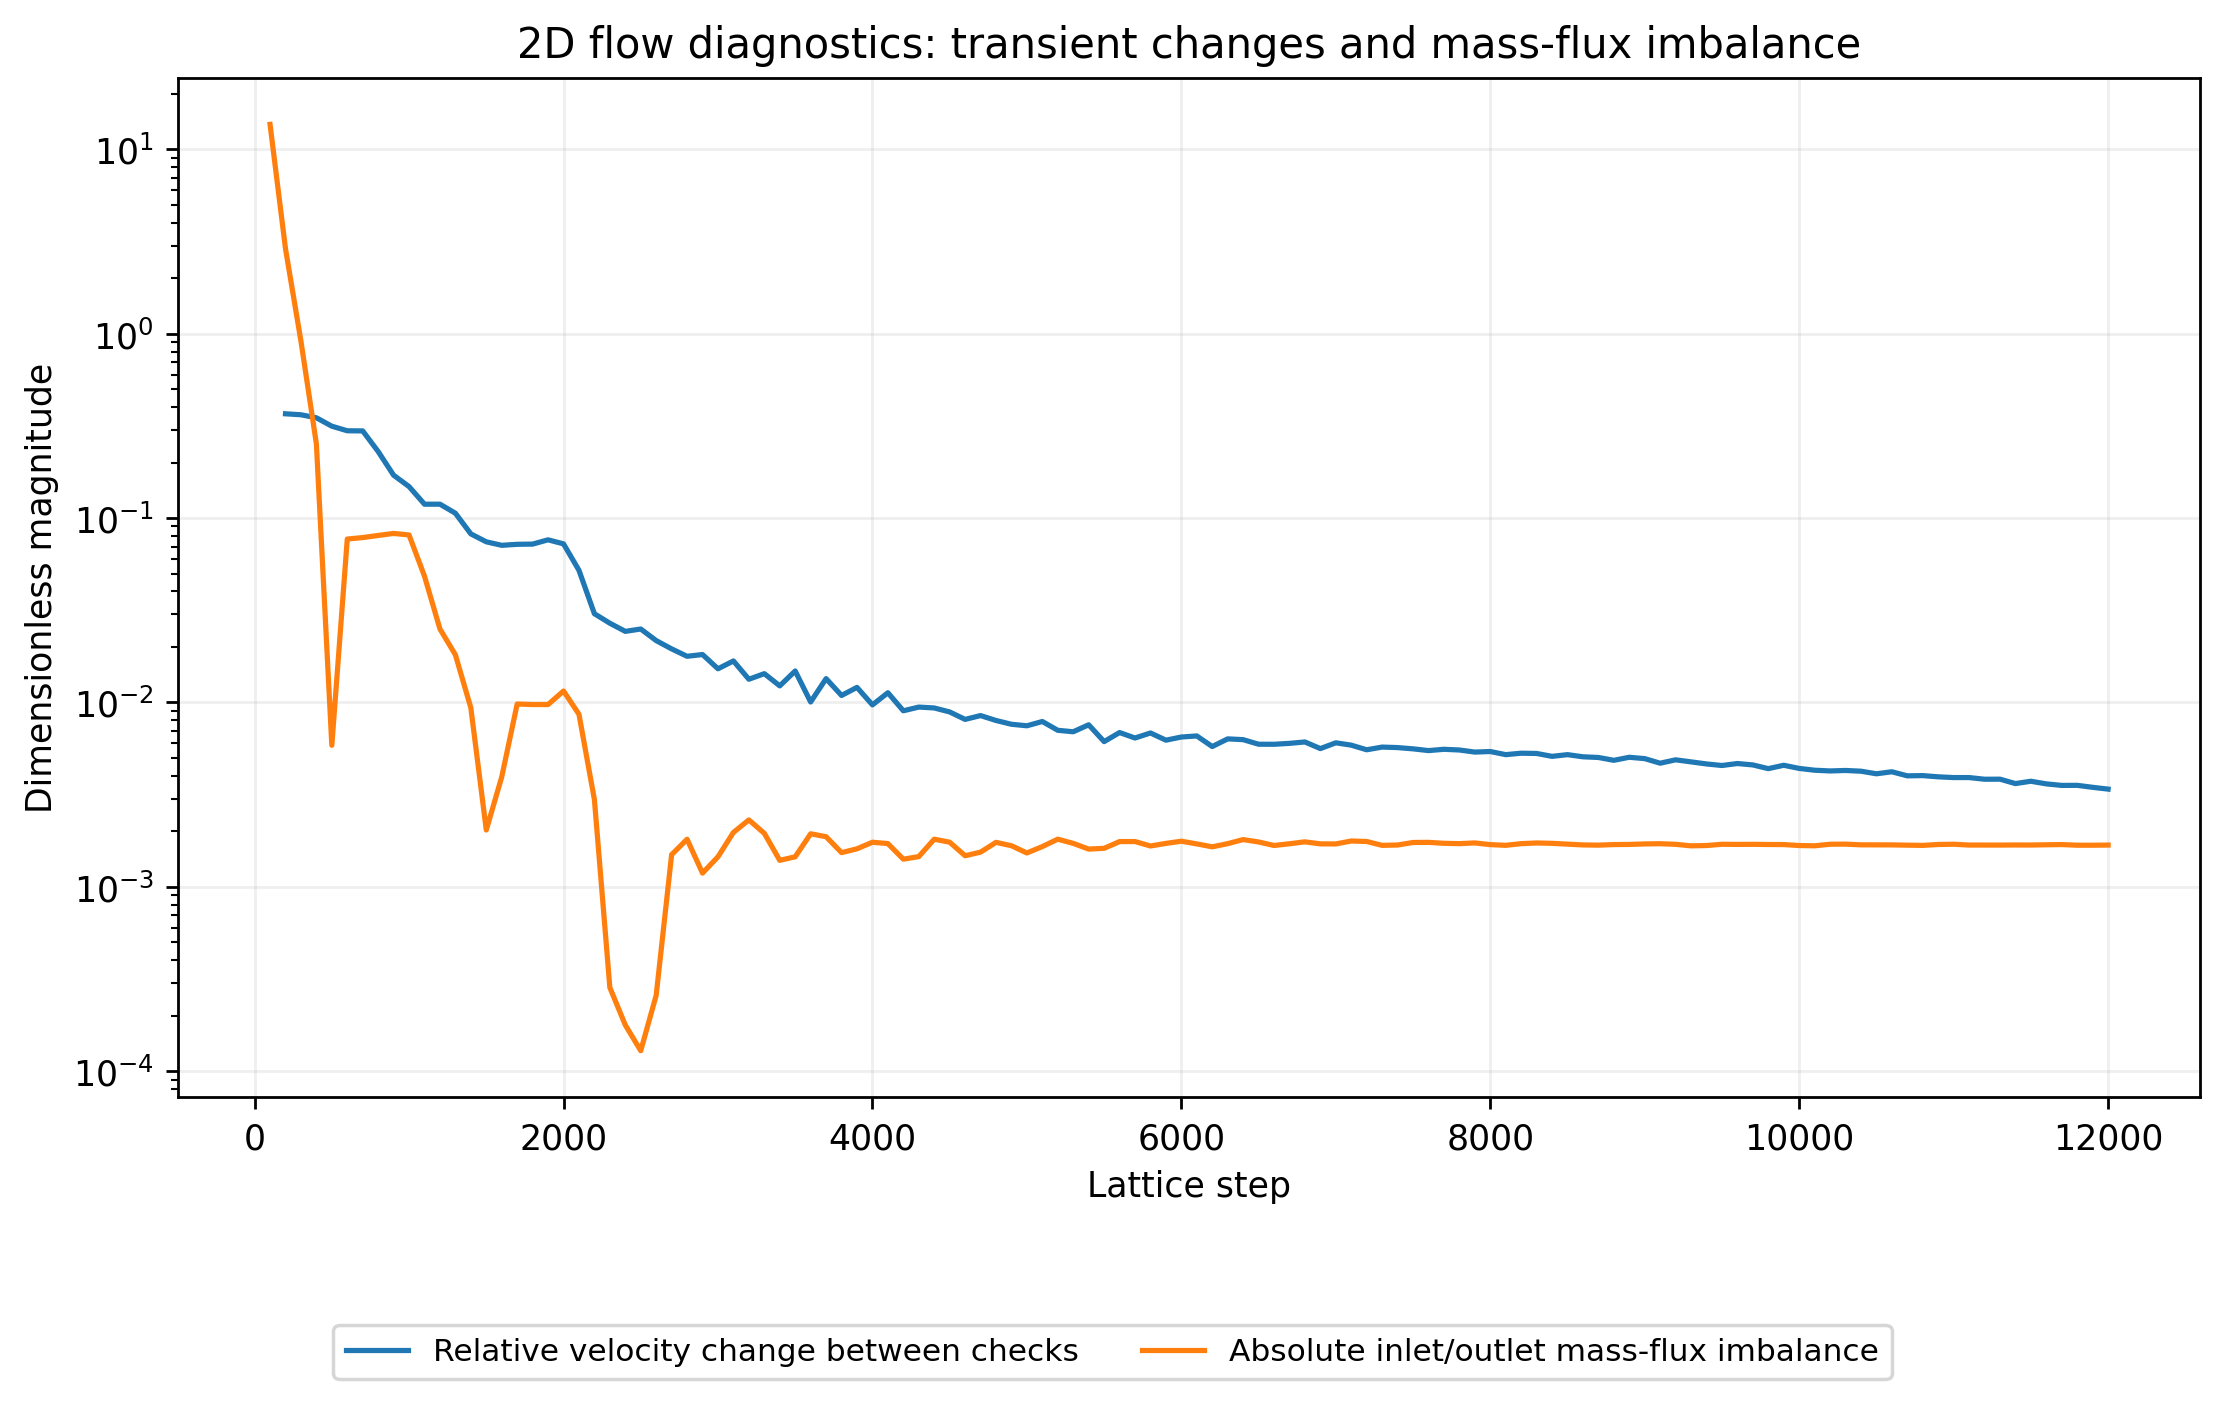

Elapsed 181.7 s; 15 in-memory figures.


In [8]:
"""GPU-accelerated structural and flow diagnostics for a tornado courtyard concept.

SI units are used unless an identifier gives another unit. The structural model is
an explicitly connected hollow concrete shell with twelve passages and transverse
webs. Linear elasticity, nodal foundation springs, directional wind screening,
static support removal, and reduced-Reynolds-number CFD are research models.
They do not establish storm-shelter qualification or construction approval.

The workflow automatically profiles an NVIDIA L4, expands sparse
GPU memory budgets, propagates one master tornado-speed control through all
speed-dependent structural and physical-reference calculations, performs mesh
sensitivity checks using compliance and stress
percentiles, screens multiple wind directions, adapts Metropolis-Hastings sampling,
and extends the LBM flow experiment with inlet ramping and an outlet sponge.
Code-dependent capacities remain gated on user-supplied site, geotechnical,
connection, detailing, and physical impact-test information.
"""

# - Control knobs ------------------------------------------------------------

TS_CONTROLS = {
    "backend": "gpu",                 # "gpu" or explicit "cpu_check".
    "auto_manage": True,
    "l4_profile": "auto",             # "auto" or "off".
    "seed": 20260905,
    "tornado_speed_mph": 320.0,        # Master simulated tornado speed.
    "sparse_mode": "auto",            # "auto", "on", or "off".
    "sparse_min_dofs": 1800,
    "csr_peak_budget_gib": 6.0,
    "gpu_work_fraction": 0.82,
    "gpu_pool_fraction": 0.92,
    "matrix_free_batch": 8192,
    "mesh_target_m": 3.0,
    "elements_through_wall": 2,
    "max_tetrahedra": 450_000,
    "max_mesh_levels": 3,
    "mesh_compliance_tolerance": 0.002,
    "mesh_stress_percentile": 99.5,
    "mesh_stress_tolerance": 0.03,
    "mesh_displacement_tolerance": 0.01,
    "refine_axis_intervals": 3,
    "pcg_rtol": 2.0e-7,
    "pcg_maxiter": 16_000,
    "contact_maxiter": 16,
    "contact_sign_tolerance_m": 1.0e-10,
    "large_displacement_ratio": 0.01,
    "wind_direction_sweep_deg": tuple(float(v) for v in range(0, 360, 30)),
    "wind_solve_cases": 4,
    "mh_walkers": 4096,
    "mh_burnin": 120,
    "mh_steps": 320,
    "mh_max_steps": 1600,
    "mh_target_visits_per_element": 16,
    "mh_beta": 0.75,
    "mh_adapt_beta": True,
    "mh_target_acceptance": 0.45,
    "mh_adapt_interval": 20,
    "mh_beta_min": 0.10,
    "mh_beta_max": 8.0,
    "mh_weight_floor": 0.02,
    "removal_cases": 4,
    "enable_cfd": True,
    "cfd_nx": 640,
    "cfd_ny": 420,
    "cfd_steps": 6000,
    "cfd_max_steps": 12_000,
    "cfd_min_steps": 2500,
    "cfd_max_cells": 1_100_000,
    "cfd_reynolds": 150.0,
    "cfd_lattice_speed": 0.04,
    "cfd_inlet_ramp_steps": 600,
    "cfd_sponge_fraction": 0.16,
    "cfd_sponge_strength": 0.08,
    "cfd_check_every": 100,
    "cfd_steady_tolerance": 1.0e-4,
    "cfd_flux_tolerance": 5.0e-3,
    "cfd_steady_checks_required": 6,
    "cfd_sample_height_fraction": 0.20,
    "cfd_length_widths": 6.0,
    "cfd_height_depths": 4.0,
    "cfd_inlet_widths": 2.0,
    "figure_dpi": 250,
    "stress_scatter_max_points": 18_000,
    "stress_scatter_fraction": 0.60,
    "stress_scatter_seed_offset": 7919,
    "show_plots": True,
    "keep_gpu_arrays": False,
}

# Explicit overrides take precedence over geometry inherited from the first cell.
TS_GEOMETRY_OVERRIDE = None
# Example: {"width_m": 72.0, "depth_m": 72.0, "height_m": 12.0,
#           "monolith_base_depth_m": 8.0, "rc_wall_thickness_m": 1.5,
#           "top_scale": 0.75}

TS_INPUTS = {
    "asce_edition": "ASCE 7-22",
    "icc_edition": "ICC 500-2023 (reference; confirm local adoption)",
    "fema_edition": "FEMA P-361 (2024), fifth edition (reference)",
    "aci_edition": "ACI CODE-318-25 (reference; confirm local adoption)",
    "site_tornado_speed_mph": None,  # Optional site-reference value; does not override simulation.
    "ground_elevation_factor": 1.0,
    "site_input_reference": "",
    "illustrative_speed_mph": 320.0,  # DERIVED compatibility mirror; do not edit directly.
    "illustrative_wind_direction_deg": 35.0,
    "outer_windward_cp": 0.8,
    "outer_leeward_cp": -0.5,
    "outer_side_cp": -0.5,
    "courtyard_pressure_cp": 0.0,
    "top_ledge_pressure_cp": 0.0,
    "dead_load_factor": 1.0,
    "wind_load_factor": 1.0,
    "prescribed_face_pressure_pa": None,
    "pressure_input_reference": "",
    "young_modulus_pa": 32.0e9,
    "poisson_ratio": 0.20,
    "concrete_density_kg_m3": 2450.0,
    "concrete_fc_pa": 69.0e6,
    "concrete_tension_screen_pa": 3.0e6,
    "steel_yield_pa": 500.0e6,
    "steel_modulus_pa": 200.0e9,
    "section_rebar_ratio_total": 0.010,
    "section_cover_m": 0.075,
    "section_concrete_peak_strain": 0.002,
    "section_concrete_limit_strain": 0.003,
    "soil_compression_modulus_n_m3": 50.0e6,
    "anchor_tension_modulus_n_m3": 200.0e6,
    "horizontal_foundation_modulus_n_m3": 30.0e6,
    "soil_bearing_limit_pa": None,
    "soil_friction_coefficient": None,
    "anchor_tension_capacity_pa": None,
    "connection_shear_capacity_pa": None,
    "geotechnical_reference": "",
    "connection_reference": "",
    "missile_mass_lb": 15.0,
    "missile_vertical_surface_speed_mph": 100.0,
    "missile_horizontal_surface_speed_mph": 67.0,
    "impact_test_report_reference": "",
}

# - Imports ------------------------------------------------------------------

from dataclasses import dataclass
import math
import os
import time
import warnings
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


@dataclass(frozen=True)
class TSGeometry:
    """Geometry shared by the continuum and flow studies."""

    width_m: float
    depth_m: float
    height_m: float
    monolith_base_depth_m: float
    rc_wall_thickness_m: float
    top_scale: float


@dataclass
class TSMesh:
    """Conforming tetrahedral mesh and its physical surface geometry."""

    points: np.ndarray
    tetra: np.ndarray
    centers: np.ndarray
    axes: tuple[np.ndarray, np.ndarray, np.ndarray]
    boundary: np.ndarray
    boundary_centers: np.ndarray
    normals: np.ndarray
    areas: np.ndarray
    base_area: np.ndarray
    neighbors: np.ndarray
    degree: np.ndarray


class TSRuntime:
    """Selects a numerical backend and manages GPU memory conservatively."""

    def __init__(self, controls: dict[str, Any]):
        """Initializes the selected backend and records accelerator properties."""
        self.controls = controls
        self.profile: dict[str, Any] = {}
        if controls["backend"] == "gpu":
            try:
                import cupy
            except ImportError as exc:
                raise RuntimeError(
                    "CuPy is unavailable. Use the Colab GPU runtime supplied CuPy."
                ) from exc
            try:
                device_count = cupy.cuda.runtime.getDeviceCount()
            except cupy.cuda.runtime.CUDARuntimeError as exc:
                raise RuntimeError(
                    "CUDA initialization failed before the structural solver started. "
                    "Use a fresh Colab GPU runtime without reinstalling CuPy."
                ) from exc
            if device_count < 1:
                raise RuntimeError("A CUDA device is required for backend='gpu'.")
            self.xp = cupy
            self.gpu = True
            self.xp.cuda.Device(0).use()
            pool = self.xp.get_default_memory_pool()
            pool.free_all_blocks()
            pool.set_limit(fraction=controls["gpu_pool_fraction"])
            props = self.xp.cuda.runtime.getDeviceProperties(0)
            raw_name = props.get("name", b"CUDA GPU")
            self.name = raw_name.decode() if isinstance(raw_name, bytes) else str(raw_name)
            free, total = self.xp.cuda.runtime.memGetInfo()
            self.profile = {
                "device_count": int(device_count),
                "driver_version": int(self.xp.cuda.runtime.driverGetVersion()),
                "runtime_version": int(self.xp.cuda.runtime.runtimeGetVersion()),
                "free_gib": float(free / 2**30),
                "total_gib": float(total / 2**30),
                "compute_capability": (
                    int(props.get("major", 0)),
                    int(props.get("minor", 0)),
                ),
            }
        elif controls["backend"] == "cpu_check":
            self.xp = np
            self.gpu = False
            self.name = "CPU diagnostic backend"
            self.profile = {"device_count": 0}
        else:
            raise ValueError("backend must be 'gpu' or 'cpu_check'.")
        self.allocation_errors = (MemoryError,)
        if self.gpu:
            self.allocation_errors += (self.xp.cuda.memory.OutOfMemoryError,)
        self.rng = self.xp.random.RandomState(controls["seed"])

    def host(self, value: Any) -> np.ndarray:
        """Copies a numerical array to host memory."""
        return self.xp.asnumpy(value) if self.gpu else np.asarray(value)

    def scalar(self, value: Any) -> float:
        """Returns a synchronized Python scalar."""
        return float(value.item()) if hasattr(value, "item") else float(value)

    def budget(self) -> int:
        """Returns the active conservative temporary-memory budget in bytes."""
        cap = int(self.controls["csr_peak_budget_gib"] * 2**30)
        if self.gpu:
            pool = self.xp.get_default_memory_pool()
            free, _ = self.xp.cuda.runtime.memGetInfo()
            reusable = pool.total_bytes() - pool.used_bytes()
            pool_room = max(0, pool.get_limit() - pool.used_bytes())
            available = min(free + reusable, pool_room)
            cap = min(cap, int(available * self.controls["gpu_work_fraction"]))
        return max(cap, 0)

    def sparse_module(self) -> Any:
        """Loads sparse functionality for the selected backend."""
        if self.gpu:
            import cupyx.scipy.sparse as sparse
        else:
            import scipy.sparse as sparse
        return sparse

    def memory_snapshot(self) -> dict[str, float]:
        """Returns live GPU memory telemetry without disturbing the memory pool."""
        if self.gpu is False:
            return {"free_gib": math.nan, "total_gib": math.nan, "pool_used_gib": 0.0}
        free, total = self.xp.cuda.runtime.memGetInfo()
        pool = self.xp.get_default_memory_pool()
        return {
            "free_gib": float(free / 2**30),
            "total_gib": float(total / 2**30),
            "pool_used_gib": float(pool.used_bytes() / 2**30),
        }

    def release(self, force: bool = False) -> None:
        """Synchronizes and optionally returns cached allocations to CUDA."""
        if self.gpu:
            self.xp.cuda.Stream.null.synchronize()
            if force:
                self.xp.get_default_memory_pool().free_all_blocks()


def ts_autotune_controls(
    controls: dict[str, Any],
    explicit_keys: set[str],
) -> tuple[dict[str, Any], dict[str, Any]]:
    """Expands numerical budgets for an L4 without overriding explicit knobs."""
    cfg = controls.copy()
    profile: dict[str, Any] = {"applied": False, "reason": "disabled or CPU"}
    if cfg["backend"] != "gpu" or cfg["l4_profile"] == "off":
        return cfg, profile
    try:
        import cupy as cp

        cp.cuda.Device(0).use()
        props = cp.cuda.runtime.getDeviceProperties(0)
        raw_name = props.get("name", b"CUDA GPU")
        name = raw_name.decode() if isinstance(raw_name, bytes) else str(raw_name)
        free, total = cp.cuda.runtime.memGetInfo()
    except Exception as exc:  # pylint: disable=broad-exception-caught
        profile["reason"] = f"GPU profile query unavailable: {exc}"
        return cfg, profile

    total_gib = total / 2**30
    free_gib = free / 2**30
    profile.update({"gpu": name, "free_gib": free_gib, "total_gib": total_gib})
    if "L4" not in name.upper():
        profile["reason"] = "GPU is not an NVIDIA L4; generic controls retained"
        return cfg, profile

    recommended = {
        "gpu_pool_fraction": 0.92,
        "gpu_work_fraction": 0.82,
        "csr_peak_budget_gib": min(7.5, max(3.0, total_gib * 0.30)),
        "matrix_free_batch": 8192,
        "max_tetrahedra": 450_000,
        "max_mesh_levels": 3,
        "mh_walkers": 4096,
        "cfd_nx": 640,
        "cfd_ny": 420,
        "cfd_max_cells": 1_100_000,
        "cfd_max_steps": 12_000,
    }
    applied = {}
    for key, value in recommended.items():
        if key not in explicit_keys:
            cfg[key] = value
            applied[key] = value
    profile["applied"] = True
    profile["reason"] = "NVIDIA L4 profile"
    profile["controls"] = applied
    return cfg, profile


def ts_resolve_geometry(namespace: dict[str, Any]) -> tuple[TSGeometry, str]:
    """Uses an explicit override, exported selection, or stated initial design."""
    source = "explicit TS_GEOMETRY_OVERRIDE"
    candidate = TS_GEOMETRY_OVERRIDE
    if candidate is None:
        for name in ("TORNADO_SELECTED_DESIGN", "selected"):
            if name in namespace and hasattr(namespace[name], "width_m"):
                candidate = namespace[name]
                source = name
                break
    if candidate is None and callable(namespace.get("initial_design")):
        candidate = namespace["initial_design"]()
        source = "initial_design() from the earlier cell"
    if candidate is None:
        candidate = dict(
            width_m=72.0, depth_m=72.0, height_m=12.0,
            monolith_base_depth_m=8.0, rc_wall_thickness_m=1.5, top_scale=0.75,
        )
        source = "explicit standalone starting geometry"
    names = tuple(TSGeometry.__dataclass_fields__)
    if isinstance(candidate, dict):
        values = {name: float(candidate[name]) for name in names}
    else:
        values = {name: float(getattr(candidate, name)) for name in names}
    geom = TSGeometry(**values)
    if all(math.isfinite(value) for value in values.values()) is False:
        raise ValueError("Geometry entries must be finite.")
    if min(values.values()) <= 0.0:
        raise ValueError("All geometry entries must be positive.")
    if geom.top_scale > 1.0:
        raise ValueError("top_scale must lie in (0, 1].")
    if 2.0 * geom.rc_wall_thickness_m >= geom.monolith_base_depth_m:
        raise ValueError("The hollow wing requires base depth > twice wall thickness.")
    if 2.0 * geom.monolith_base_depth_m >= min(geom.width_m, geom.depth_m):
        raise ValueError("The courtyard must have positive clear dimensions.")
    if source.startswith(("initial_design", "explicit standalone")):
        print(
            "Geometry uses the starting concept. The prior main() keeps its selected "
            "design local. For diagnostics of the optimized candidate, set "
            "TORNADO_SELECTED_DESIGN = selected inside that main() before it returns, "
            "or populate TS_GEOMETRY_OVERRIDE explicitly."
        )
    return geom, source


def ts_openings(length: float) -> np.ndarray:
    """Returns three rectangular opening intervals matching the first cell."""
    width = length * 0.10
    gap = (length - 3.0 * width) / 4.0
    starts = -length / 2.0 + gap + np.arange(3) * (width + gap)
    return np.column_stack((starts, starts + width))


def ts_solids(length: float) -> np.ndarray:
    """Returns the four solid pier intervals between passages."""
    openings = ts_openings(length)
    edges = np.r_[-length / 2.0, openings.ravel(), length / 2.0]
    return edges.reshape(4, 2)


def ts_axis(length: float, geom: TSGeometry, step: float, across: int) -> np.ndarray:
    """Builds a feature-conforming horizontal axis with wall subdivisions."""
    half = length / 2.0
    inner = half - geom.monolith_base_depth_m
    thick = geom.rc_wall_thickness_m
    openings = ts_openings(length)
    if np.max(np.abs(openings)) >= inner:
        raise ValueError("Passages must stay clear of the corner intersection zones.")
    centers = ts_solids(length).mean(axis=1)
    anchors = [-half, -half + thick, -inner - thick, -inner,
               inner, inner + thick, half - thick, half]
    anchors.extend(openings.ravel())
    for center in centers:
        anchors.extend((center - thick / 2.0, center + thick / 2.0))
    anchors = np.unique(np.clip(anchors, -half, half))
    entries = []
    for lower, upper in zip(anchors[:-1], anchors[1:]):
        count = max(1, int(math.ceil((upper - lower) / step)))
        mid = abs((lower + upper) / 2.0)
        is_wall = mid >= half - thick or inner <= mid <= inner + thick
        if is_wall:
            count = max(count, int(math.ceil((upper - lower) / (thick / across))))
        entries.extend(np.linspace(lower, upper, count + 1)[:-1])
    return np.r_[entries, anchors[-1]]


def ts_taper_axis(axis: np.ndarray, length: float, geom: TSGeometry,
                  z: float) -> np.ndarray:
    """Tapers wing depth while retaining fixed rectangular opening jambs."""
    half = length / 2.0
    inner = half - geom.monolith_base_depth_m
    thick = geom.rc_wall_thickness_m
    scale = 1.0 - (1.0 - geom.top_scale) * z / geom.height_m
    delta = geom.monolith_base_depth_m * (1.0 - scale) / 2.0
    source = np.r_[[-half, -half + thick, -inner - thick, -inner],
                   ts_openings(length).ravel(),
                   [inner, inner + thick, half - thick, half]]
    source = np.unique(source)
    target = source.copy()
    for sign in (-1.0, 1.0):
        for old, new in (
            (half, half - delta),
            (half - thick, half - delta - thick * scale),
            (inner, inner + delta),
            (inner + thick, inner + delta + thick * scale),
        ):
            target[np.isclose(source, sign * old)] = sign * new
    if np.any(np.diff(target) <= 0.0):
        raise ValueError("Taper mapping folds the mesh; reduce taper or revise features.")
    return np.interp(axis, source, target)


def ts_solid_mask(x: Any, y: Any, z: Any, geom: TSGeometry,
                  xp: Any = np) -> Any:
    """Classifies base-coordinate wall rings, webs, and the twelve passages."""
    w, d = geom.width_m, geom.depth_m
    b, t = geom.monolith_base_depth_m, geom.rc_wall_thickness_m
    ax, ay = xp.abs(x), xp.abs(y)
    ci_x, ci_y = w / 2.0 - b, d / 2.0 - b
    inside = (ax <= w / 2.0) & (ay <= d / 2.0)
    courtyard = (ax < ci_x) & (ay < ci_y)
    outer_ring = (ax >= w / 2.0 - t) | (ay >= d / 2.0 - t)
    inner_ring = ((ax <= ci_x + t) & (ay <= ci_y + t)
                  & ((ax >= ci_x) | (ay >= ci_y)))
    webs = xp.zeros_like(inside)
    for center in ts_solids(w).mean(axis=1):
        webs |= (xp.abs(x - center) <= t / 2.0) & (ay >= ci_y)
    for center in ts_solids(d).mean(axis=1):
        webs |= (xp.abs(y - center) <= t / 2.0) & (ax >= ci_x)
    opening = xp.zeros_like(inside)
    for lower, upper in ts_openings(w):
        opening |= (x > lower) & (x < upper) & (ay >= ci_y)
    for lower, upper in ts_openings(d):
        opening |= (y > lower) & (y < upper) & (ax >= ci_x)
    return inside & (~courtyard) & (outer_ring | inner_ring | webs) & (
        (~opening) | (z >= 0.40 * geom.height_m)
    )


def ts_mesh_from_axes(geom: TSGeometry,
                      axes: tuple[np.ndarray, np.ndarray, np.ndarray]) -> TSMesh:
    """Creates conforming six-tetrahedron cells and a face-adjacency graph."""
    x, y, z = axes
    xc, yc, zc = [(a[1:] + a[:-1]) / 2.0 for a in axes]
    mx, my, mz = np.meshgrid(xc, yc, zc, indexing="ij")
    occupied = ts_solid_mask(mx, my, mz, geom)
    ii, jj, kk = np.where(occupied)
    grid = np.arange(len(x) * len(y) * len(z)).reshape(len(x), len(y), len(z))
    offsets = np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0],
                        [0, 0, 1], [1, 0, 1], [0, 1, 1], [1, 1, 1]])
    hexes = np.stack([grid[ii + a, jj + b, kk + c] for a, b, c in offsets], axis=1)
    pattern = np.array([[0, 1, 3, 7], [0, 1, 5, 7], [0, 2, 3, 7],
                        [0, 2, 6, 7], [0, 4, 5, 7], [0, 4, 6, 7]])
    tetra = hexes[:, pattern].reshape(-1, 4)
    points = np.empty((len(x), len(y), len(z), 3))
    for k, value in enumerate(z):
        xx, yy = np.meshgrid(ts_taper_axis(x, geom.width_m, geom, value),
                             ts_taper_axis(y, geom.depth_m, geom, value), indexing="ij")
        points[:, :, k, 0] = xx
        points[:, :, k, 1] = yy
        points[:, :, k, 2] = value
    points = points.reshape(-1, 3)
    used, inverse = np.unique(tetra, return_inverse=True)
    tetra = inverse.reshape(-1, 4).astype(np.int32)
    points = points[used]
    centers = points[tetra].mean(axis=1)
    faces_local = np.array([[1, 2, 3], [0, 2, 3], [0, 1, 3], [0, 1, 2]])
    faces = tetra[:, faces_local].reshape(-1, 3)
    owners = np.repeat(np.arange(len(tetra)), 4)
    sorted_faces = np.sort(faces, axis=1)
    _, first, inv, counts = np.unique(sorted_faces, axis=0, return_index=True,
                                     return_inverse=True, return_counts=True)
    if np.any(counts > 2):
        raise RuntimeError("Nonmanifold mesh face encountered.")
    boundary = faces[first[counts == 1]]
    face_owner = owners[first[counts == 1]]
    face_points = points[boundary]
    fc = face_points.mean(axis=1)
    cross = np.cross(face_points[:, 1] - face_points[:, 0],
                     face_points[:, 2] - face_points[:, 0])
    norm = np.linalg.norm(cross, axis=1)
    normals = cross / norm[:, None]
    wrong = np.einsum("ij,ij->i", normals, fc - centers[face_owner]) < 0.0
    normals[wrong] *= -1.0
    areas = norm / 2.0
    base_area = np.zeros(len(points))
    bottom = np.isclose(fc[:, 2], 0.0)
    np.add.at(base_area, boundary[bottom].ravel(), np.repeat(areas[bottom] / 3.0, 3))
    order = np.argsort(inv, kind="stable")
    starts = np.r_[0, np.cumsum(counts)[:-1]]
    pairs = starts[counts == 2]
    owner_a, owner_b = owners[order[pairs]], owners[order[pairs + 1]]
    degree = np.bincount(np.r_[owner_a, owner_b], minlength=len(tetra)).astype(np.int32)
    neighbors = np.full((len(tetra), 4), -1, dtype=np.int32)
    cursor = np.zeros(len(tetra), dtype=np.int32)
    for a, b in zip(owner_a, owner_b):
        neighbors[a, cursor[a]] = b
        neighbors[b, cursor[b]] = a
        cursor[a] += 1
        cursor[b] += 1
    if np.any(degree == 0):
        raise RuntimeError("Isolated tetrahedron in the mesh.")
    return TSMesh(points, tetra, centers, axes, boundary, fc, normals, areas,
                  base_area, neighbors, degree)


def ts_initial_mesh(geom: TSGeometry, controls: dict[str, Any]) -> TSMesh:
    """Chooses a mesh within the element cap without erasing small features."""
    step = controls["mesh_target_m"]
    for _ in range(8):
        x = ts_axis(geom.width_m, geom, step, controls["elements_through_wall"])
        y = ts_axis(geom.depth_m, geom, step, controls["elements_through_wall"])
        z = np.unique(np.r_[np.linspace(0.0, geom.height_m,
                                        int(math.ceil(geom.height_m / step)) + 1),
                            0.40 * geom.height_m])
        mesh = ts_mesh_from_axes(geom, (x, y, z))
        if len(mesh.tetra) <= controls["max_tetrahedra"]:
            return mesh
        if controls["auto_manage"] is False:
            break
        step *= 1.35
    raise MemoryError("Feature-preserving mesh exceeds max_tetrahedra; raise its cap.")


class TSNumericalError(RuntimeError):
    """Signals unresolved numerical equilibrium or a failed verification check."""


class TSElasticity:
    """Three-dimensional TET4 elasticity with tensor and adjacency operators."""

    def __init__(self, mesh: TSMesh, runtime: TSRuntime, inputs: dict[str, Any]):
        """Builds element stiffness tensors and optional sparse storage."""
        self.mesh = mesh
        self.rt = runtime
        self.inputs = inputs
        xp = runtime.xp
        self.conn = xp.asarray(mesh.tetra, dtype=xp.int32)
        self.ndof = 3 * len(mesh.points)
        self.edof = (3 * self.conn[:, :, None] + xp.arange(3)).reshape(-1, 12)
        self.coords = xp.asarray(mesh.points, dtype=xp.float64)
        coords = self.coords[self.conn]
        affine = xp.concatenate((xp.ones((*coords.shape[:2], 1)), coords), axis=2)
        determinants = xp.linalg.det(affine)
        self.volume = xp.abs(determinants) / 6.0
        if runtime.scalar(xp.min(self.volume)) <= 1.0e-12:
            raise TSNumericalError("Degenerate tetrahedron encountered.")
        gradients = xp.linalg.inv(affine)[:, 1:, :].transpose(0, 2, 1)
        self.bmat = xp.zeros((len(mesh.tetra), 6, 12), dtype=xp.float64)
        for node in range(4):
            gx, gy, gz = (gradients[:, node, j] for j in range(3))
            j = 3 * node
            self.bmat[:, 0, j] = gx
            self.bmat[:, 1, j + 1] = gy
            self.bmat[:, 2, j + 2] = gz
            self.bmat[:, 3, j] = gy
            self.bmat[:, 3, j + 1] = gx
            self.bmat[:, 4, j + 1] = gz
            self.bmat[:, 4, j + 2] = gy
            self.bmat[:, 5, j] = gz
            self.bmat[:, 5, j + 2] = gx
        young = inputs["young_modulus_pa"]
        nu = inputs["poisson_ratio"]
        if young <= 0.0 or nu <= -1.0 or nu >= 0.499:
            raise ValueError("Elastic modulus or Poisson ratio is outside its range.")
        lam = young * nu / ((1.0 + nu) * (1.0 - 2.0 * nu))
        mu = young / (2.0 * (1.0 + nu))
        self.dmat = xp.zeros((6, 6), dtype=xp.float64)
        self.dmat[:3, :3] = lam
        for j in range(3):
            self.dmat[j, j] += 2.0 * mu
            self.dmat[j + 3, j + 3] = mu
        self.ke = (self.bmat.transpose(0, 2, 1) @ self.dmat @ self.bmat
                   * self.volume[:, None, None])
        self.diagonal_blocks = xp.zeros((len(mesh.points), 3, 3))
        for i in range(3):
            for j in range(3):
                local = xp.stack([self.ke[:, 3 * n + i, 3 * n + j]
                                  for n in range(4)], axis=1)
                self.diagonal_blocks[:, i, j] = xp.bincount(
                    self.conn.ravel(), weights=local.ravel(), minlength=len(mesh.points)
                )
        self.base_area = xp.asarray(mesh.base_area)
        self.matrix = None
        self.storage = "matrix-free tensor adjacency"
        policy = runtime.controls["sparse_mode"]
        if policy not in ("auto", "on", "off"):
            raise ValueError("sparse_mode must be 'auto', 'on', or 'off'.")
        # Includes COO sorting, duplicate reduction, CSR, and construction work.
        self.csr_peak_estimate = len(mesh.tetra) * 144 * 56 + self.ndof * 24
        want_sparse = policy == "on" or (
            policy == "auto" and self.ndof >= runtime.controls["sparse_min_dofs"]
            and self.csr_peak_estimate <= runtime.budget()
        )
        if policy == "on" and self.csr_peak_estimate > runtime.budget():
            raise MemoryError("Forced CSR exceeds the current conservative memory budget.")
        if want_sparse:
            try:
                sparse = runtime.sparse_module()
                rows = xp.repeat(self.edof, 12, axis=1).ravel().astype(xp.int32)
                cols = xp.tile(self.edof, (1, 12)).ravel().astype(xp.int32)
                self.matrix = sparse.coo_matrix(
                    (self.ke.ravel(), (rows, cols)), shape=(self.ndof, self.ndof)
                ).tocsr()
                self.matrix.sum_duplicates()
                self.matrix.sort_indices()
                del rows, cols
                self.storage = "CSR sparse adjacency"
            except ImportError:
                if policy == "on":
                    raise
                warnings.warn("Sparse module unavailable; using exact matrix-free action.")
            except runtime.allocation_errors:
                self.matrix = None
                if "rows" in locals():
                    del rows
                if "cols" in locals():
                    del cols
                runtime.release()
                if policy == "on":
                    raise
                warnings.warn("CSR allocation exceeded memory; using matrix-free action.")
        self.verify_element_tensor()

    def tensor_action(self, vector: Any) -> Any:
        """Applies all element tensors without constructing a dense global matrix."""
        xp = self.rt.xp
        out = xp.zeros(self.ndof, dtype=xp.float64)
        size = self.rt.controls["matrix_free_batch"]
        for start in range(0, len(self.mesh.tetra), size):
            sl = slice(start, start + size)
            dof = self.edof[sl]
            local = xp.einsum("eij,ej->ei", self.ke[sl], vector[dof])
            out += xp.bincount(dof.ravel(), weights=local.ravel(), minlength=self.ndof)
        return out

    def action(self, vector: Any, spring: Any) -> Any:
        """Applies elastic stiffness and current contact/anchor stiffness."""
        elastic = self.matrix @ vector if self.matrix is not None else self.tensor_action(vector)
        return elastic + spring.ravel() * vector

    def verify_element_tensor(self) -> None:
        """Checks affine-strain reproduction, rigid translation, and symmetry."""
        xp = self.rt.xp
        grad = xp.asarray([[1.0e-4, 2.0e-5, 0.0], [0.0, -2.0e-5, 1.0e-5],
                           [3.0e-5, 0.0, 2.0e-5]])
        displacement = (self.coords @ grad.T).ravel()
        predicted = xp.einsum("eij,ej->ei", self.bmat, displacement[self.edof])
        expected = xp.stack([grad[0, 0], grad[1, 1], grad[2, 2],
                               grad[0, 1] + grad[1, 0], grad[1, 2] + grad[2, 1],
                               grad[0, 2] + grad[2, 0]])
        error = self.rt.scalar(xp.max(xp.abs(predicted - expected)))
        symmetry = self.rt.scalar(xp.max(xp.abs(self.ke - self.ke.transpose(0, 2, 1))))
        scale = self.rt.scalar(xp.max(xp.abs(self.ke)))
        translation = xp.tile(xp.asarray([0.12, -0.23, 0.31]), 4)
        rigid = self.rt.scalar(xp.max(xp.abs(self.ke @ translation))) / max(scale, 1.0)
        if error > 1.0e-10 or symmetry / max(scale, 1.0) > 1.0e-11 or rigid > 1.0e-10:
            raise TSNumericalError("Element tensor verification failed.")
        self.tensor_tests = {"affine_strain_max_error": error,
                             "relative_symmetry_error": symmetry / max(scale, 1.0),
                             "rigid_translation_relative_error": rigid}
        if self.matrix is not None:
            vector = xp.sin(xp.arange(self.ndof, dtype=xp.float64) * 0.13)
            a = self.matrix @ vector
            b = self.tensor_action(vector)
            parity = self.rt.scalar(xp.linalg.norm(a - b) / xp.linalg.norm(a))
            self.tensor_tests["csr_tensor_relative_error"] = parity
            if parity > 2.0e-11:
                raise TSNumericalError("CSR and tensor actions disagree.")

    def fields(self, displacement: Any) -> dict[str, Any]:
        """Recovers strain, stress, principal stresses, and strain energy."""
        xp = self.rt.xp
        strain = xp.einsum("eij,ej->ei", self.bmat, displacement[self.edof])
        stress = strain @ self.dmat.T
        tensor = xp.zeros((len(stress), 3, 3), dtype=xp.float64)
        tensor[:, 0, 0], tensor[:, 1, 1], tensor[:, 2, 2] = (
            stress[:, 0], stress[:, 1], stress[:, 2]
        )
        tensor[:, 0, 1] = tensor[:, 1, 0] = stress[:, 3]
        tensor[:, 1, 2] = tensor[:, 2, 1] = stress[:, 4]
        tensor[:, 0, 2] = tensor[:, 2, 0] = stress[:, 5]
        principal = xp.linalg.eigvalsh(tensor)
        energy = 0.5 * self.volume * xp.sum(strain * stress, axis=1)
        return {"strain": strain, "stress": stress, "principal": principal,
                "energy": energy}


def ts_pcg(model: TSElasticity, load: Any, springs: Any,
           initial: Any = None) -> tuple[Any, list[float]]:
    """Solves SPD equilibrium with a nodal 3x3 block-Jacobi PCG method."""
    rt, xp = model.rt, model.rt.xp
    controls = rt.controls
    x = xp.zeros_like(load) if initial is None else initial.copy()
    blocks = model.diagonal_blocks.copy()
    for j in range(3):
        blocks[:, j, j] += springs[:, j]
    inverse = xp.linalg.inv(blocks)

    def precondition(vector: Any) -> Any:
        """Applies the inverse nodal stiffness blocks."""
        return xp.einsum("nij,nj->ni", inverse, vector.reshape(-1, 3)).ravel()

    bnorm = rt.scalar(xp.linalg.norm(load))
    if bnorm == 0.0:
        return xp.zeros_like(load), [0.0]
    residual = load - model.action(x, springs)
    z = precondition(residual)
    direction = z.copy()
    rz = xp.dot(residual, z)
    history = [rt.scalar(xp.linalg.norm(residual)) / bnorm]
    tolerance = controls["pcg_rtol"]
    if history[-1] <= tolerance:
        return x, history
    for iteration in range(controls["pcg_maxiter"]):
        ad = model.action(direction, springs)
        denominator = xp.dot(direction, ad)
        if rt.scalar(denominator) <= 0.0:
            raise TSNumericalError("PCG detected loss of positive stiffness.")
        alpha = rz / denominator
        x += alpha * direction
        residual -= alpha * ad
        # True residual replacement controls accumulated floating-point drift.
        if (iteration + 1) % 100 == 0:
            residual = load - model.action(x, springs)
        norm = rt.scalar(xp.linalg.norm(residual)) / bnorm
        history.append(norm)
        if math.isfinite(norm) is False:
            raise TSNumericalError("Nonfinite PCG residual.")
        if norm <= tolerance:
            true_norm = rt.scalar(xp.linalg.norm(load - model.action(x, springs))) / bnorm
            if true_norm <= tolerance * 2.0:
                history[-1] = true_norm
                return x, history
            residual = load - model.action(x, springs)
            z = precondition(residual)
            direction = z.copy()
            rz = xp.dot(residual, z)
            continue
        z = precondition(residual)
        next_rz = xp.dot(residual, z)
        direction = z + (next_rz / rz) * direction
        rz = next_rz
    raise TSNumericalError(
        f"PCG stopped at residual {history[-1]:.3e}; equilibrium is unresolved."
    )


def ts_velocity_pressure(speed_mph: Any, z_m: Any,
                         ground_factor: float = 1.0, xp: Any = np) -> Any:
    """Implements ASCE 7-22 Eq. 32.10-1 using SI velocity units.

    q_zT = 0.613 K_zTor K_e V_T^2, with V_T in m/s and q_zT in Pa.
    The exposure profile follows the NIST/FEMA 2023 design guide.
    This kernel alone does not determine required surface design pressure.
    """
    height_ft = xp.asarray(z_m) / 0.3048
    kz = xp.where(height_ft <= 200.0, 1.0,
                  xp.where(height_ft >= 328.0, 0.9,
                           1.0 - 0.1 * (height_ft - 200.0) / 128.0))
    return 0.613 * kz * ground_factor * (xp.asarray(speed_mph) * 0.44704)**2


def ts_surface_pressure(mesh: TSMesh, geom: TSGeometry,
                         inputs: dict[str, Any]) -> tuple[np.ndarray, str]:
    """Returns prescribed pressure or an explicitly illustrative pressure field."""
    prescribed = inputs["prescribed_face_pressure_pa"]
    if prescribed is not None:
        if len(inputs["pressure_input_reference"].strip()) == 0:
            raise ValueError("Prescribed pressure requires pressure_input_reference.")
        pressure = np.asarray(prescribed(mesh.boundary_centers.copy(),
                                         mesh.normals.copy()), dtype=float)
        if pressure.shape != (len(mesh.boundary),) or bool(np.all(np.isfinite(pressure))) is False:
            raise ValueError("Pressure callback must return one finite Pa value per face.")
        return pressure, "user-prescribed surface pressures"
    z = mesh.boundary_centers[:, 2]
    # The master simulation speed is synchronized from TS_CONTROLS in ts_run().
    # A site-specific speed remains a reference/assessment input and does not
    # silently override the requested simulation scenario.
    speed = float(inputs["illustrative_speed_mph"])
    q = ts_velocity_pressure(speed, z, inputs["ground_elevation_factor"])
    x, y = mesh.boundary_centers[:, :2].T
    delta = geom.monolith_base_depth_m * (1.0 - geom.top_scale) * z / (2.0 * geom.height_m)
    outer = (np.isclose(np.abs(x), geom.width_m / 2.0 - delta, atol=1.0e-7)
             | np.isclose(np.abs(y), geom.depth_m / 2.0 - delta, atol=1.0e-7))
    courtyard = (np.isclose(np.abs(x), geom.width_m / 2.0 - geom.monolith_base_depth_m + delta,
                            atol=1.0e-7)
                 | np.isclose(np.abs(y), geom.depth_m / 2.0 - geom.monolith_base_depth_m + delta,
                              atol=1.0e-7))
    angle = math.radians(inputs["illustrative_wind_direction_deg"])
    direction = np.array([math.cos(angle), math.sin(angle), 0.0])
    projection = mesh.normals @ direction
    side = inputs["outer_side_cp"] * (1.0 - projection**2)
    exterior_cp = side + np.where(projection < 0.0,
                                  inputs["outer_windward_cp"],
                                  inputs["outer_leeward_cp"]) * projection**2
    pressure = np.where(outer, exterior_cp * q, 0.0)
    pressure += np.where(courtyard & (~outer), inputs["courtyard_pressure_cp"] * q, 0.0)
    top = np.isclose(z, geom.height_m)
    pressure[top] = inputs["top_ledge_pressure_cp"] * q[top]
    pressure[np.isclose(z, 0.0)] = 0.0
    return pressure, "illustrative coefficients; code surface loads unverified"


def ts_load_vector(model: TSElasticity, pressure: np.ndarray) -> tuple[Any, Any]:
    """Integrates gravity and pressure on the actual modeled shell surfaces."""
    xp, rt = model.rt.xp, model.rt
    mesh, inputs = model.mesh, model.inputs
    nodal_mass = xp.bincount(model.conn.ravel(),
                             weights=xp.repeat(model.volume * inputs["concrete_density_kg_m3"] / 4.0, 4),
                             minlength=len(mesh.points))
    gravity = xp.zeros((len(mesh.points), 3), dtype=xp.float64)
    gravity[:, 2] = -9.80665 * nodal_mass * inputs["dead_load_factor"]
    traction = (-pressure[:, None] * mesh.normals * mesh.areas[:, None]
                * inputs["wind_load_factor"] / 3.0)
    wind = xp.zeros_like(gravity)
    faces = xp.asarray(mesh.boundary, dtype=xp.int32)
    for j in range(3):
        wind[:, j] = xp.bincount(faces.ravel(),
                                 weights=xp.repeat(xp.asarray(traction[:, j]), 3),
                                 minlength=len(mesh.points))
    return (gravity + wind).ravel(), wind.ravel()


def ts_solve_contact(
    model: TSElasticity,
    load: Any,
    remove_base: np.ndarray | None = None,
) -> dict[str, Any]:
    """Solves compression-only soil with separate tension-only anchor springs."""
    xp, rt, inputs = model.rt.xp, model.rt, model.inputs
    area = model.base_area.copy()
    if remove_base is not None:
        area[xp.asarray(remove_base)] = 0.0
    node_count = len(model.mesh.points)
    u = xp.zeros(model.ndof, dtype=xp.float64)
    compression = xp.ones(node_count, dtype=bool)
    history: list[float] = []
    history_segments: list[np.ndarray] = []
    for active_iteration in range(rt.controls["contact_maxiter"]):
        spring = xp.zeros((node_count, 3), dtype=xp.float64)
        spring[:, :2] = area[:, None] * inputs["horizontal_foundation_modulus_n_m3"]
        spring[:, 2] = area * xp.where(
            compression,
            inputs["soil_compression_modulus_n_m3"],
            inputs["anchor_tension_modulus_n_m3"],
        )
        u, local_history = ts_pcg(model, load, spring, initial=u)
        local_array = np.asarray(local_history, dtype=float)
        history_segments.append(local_array)
        history.extend(local_array.tolist())
        uz = u.reshape(-1, 3)[:, 2]
        tolerance = rt.controls["contact_sign_tolerance_m"]
        next_compression = xp.where(
            xp.abs(uz) <= tolerance,
            compression,
            uz <= 0.0,
        )
        same = (
            rt.scalar(
                xp.count_nonzero((next_compression != compression) & (area > 0.0))
            )
            == 0.0
        )
        if same:
            break
        compression = next_compression
    else:
        raise TSNumericalError("Foundation contact active set failed to settle.")

    reactions = -spring * u.reshape(-1, 3)
    external = load.reshape(-1, 3)
    force_sum = xp.sum(external + reactions, axis=0)
    force_scale = max(rt.scalar(xp.linalg.norm(xp.sum(external, axis=0))), 1.0)
    force_error = rt.scalar(xp.linalg.norm(force_sum)) / force_scale
    moment_sum = xp.sum(xp.cross(model.coords, external + reactions), axis=0)
    moment_scale = max(
        rt.scalar(xp.sum(xp.linalg.norm(xp.cross(model.coords, external), axis=1))),
        1.0,
    )
    moment_error = rt.scalar(xp.linalg.norm(moment_sum)) / moment_scale
    fields = model.fields(u)
    strain_energy = rt.scalar(xp.sum(fields["energy"]))
    spring_energy = rt.scalar(0.5 * xp.sum(spring * u.reshape(-1, 3) ** 2))
    work = rt.scalar(xp.dot(load, u))
    energy_error = abs(work - 2.0 * (strain_energy + spring_energy)) / max(
        abs(work), 1.0
    )
    if max(force_error, moment_error, energy_error) > 2.0e-4:
        raise TSNumericalError("Global force, moment, or work balance failed.")
    return {
        "u": u,
        "reactions": reactions,
        "spring": spring,
        "fields": fields,
        "residual_history": np.asarray(history),
        "residual_segments": history_segments,
        "active_iterations": active_iteration + 1,
        "force_balance_error": force_error,
        "moment_balance_error": moment_error,
        "energy_balance_error": energy_error,
        "compliance_j": work,
        "spring_area": area,
    }


def ts_mh_hotspots(model: TSElasticity, energy: Any) -> dict[str, Any]:
    """Samples element importance with an adaptive burn-in and frozen MH target."""
    rt, xp, cfg = model.rt, model.rt.xp, model.rt.controls
    n = len(model.mesh.tetra)
    walkers = (
        min(cfg["mh_walkers"], max(64, n))
        if cfg["auto_manage"]
        else cfg["mh_walkers"]
    )
    mean_energy = max(rt.scalar(xp.mean(energy)), 1.0e-30)
    neighbors = xp.asarray(model.mesh.neighbors, dtype=xp.int32)
    degree = xp.asarray(model.mesh.degree, dtype=xp.int32)
    state = rt.rng.randint(0, n, size=walkers).astype(xp.int32)
    beta = float(cfg["mh_beta"])
    burnin_acceptance: list[float] = []

    def log_weights(beta_value: float) -> Any:
        return beta_value * xp.log(cfg["mh_weight_floor"] + energy / mean_energy)

    log_weight = log_weights(beta)
    for step in range(cfg["mh_burnin"]):
        global_move = rt.rng.random_sample(walkers) < 0.15
        slots = (rt.rng.random_sample(walkers) * degree[state]).astype(xp.int32)
        local = neighbors[state, slots]
        global_proposal = rt.rng.randint(0, n, size=walkers).astype(xp.int32)
        proposal = xp.where(global_move, global_proposal, local)
        correction = xp.where(
            global_move,
            0.0,
            xp.log(degree[state]) - xp.log(degree[proposal]),
        )
        log_alpha = log_weight[proposal] - log_weight[state] + correction
        accepted = (
            xp.log(xp.maximum(rt.rng.random_sample(walkers), 1.0e-300))
            < xp.minimum(log_alpha, 0.0)
        )
        state = xp.where(accepted, proposal, state)
        acc = rt.scalar(xp.mean(accepted))
        burnin_acceptance.append(acc)
        if (
            cfg["mh_adapt_beta"]
            and (step + 1) % cfg["mh_adapt_interval"] == 0
        ):
            recent = float(np.mean(burnin_acceptance[-cfg["mh_adapt_interval"] :]))
            adjustment = math.exp(0.65 * (recent - cfg["mh_target_acceptance"]))
            beta = float(np.clip(
                beta * adjustment,
                cfg["mh_beta_min"],
                cfg["mh_beta_max"],
            ))
            log_weight = log_weights(beta)

    retained_steps = cfg["mh_steps"]
    if cfg["auto_manage"]:
        retained_steps = min(
            cfg["mh_max_steps"],
            max(
                retained_steps,
                int(
                    math.ceil(
                        cfg["mh_target_visits_per_element"] * n / walkers
                    )
                ),
            ),
        )

    visits = xp.zeros(n, dtype=xp.int64)
    acceptance: list[float] = []
    trace: list[float] = []
    log_weight = log_weights(beta)
    for _ in range(retained_steps):
        global_move = rt.rng.random_sample(walkers) < 0.15
        slots = (rt.rng.random_sample(walkers) * degree[state]).astype(xp.int32)
        local = neighbors[state, slots]
        global_proposal = rt.rng.randint(0, n, size=walkers).astype(xp.int32)
        proposal = xp.where(global_move, global_proposal, local)
        correction = xp.where(
            global_move,
            0.0,
            xp.log(degree[state]) - xp.log(degree[proposal]),
        )
        log_alpha = log_weight[proposal] - log_weight[state] + correction
        accepted = (
            xp.log(xp.maximum(rt.rng.random_sample(walkers), 1.0e-300))
            < xp.minimum(log_alpha, 0.0)
        )
        state = xp.where(accepted, proposal, state)
        visits += xp.bincount(state, minlength=n)
        acceptance.append(rt.scalar(xp.mean(accepted)))
        trace.append(rt.scalar(xp.mean(energy[state])) / mean_energy)

    target = xp.exp(log_weight - xp.max(log_weight))
    target /= xp.sum(target)
    sampled = visits / max(rt.scalar(xp.sum(visits)), 1.0)
    total_variation = 0.5 * rt.scalar(xp.sum(xp.abs(sampled - target)))
    return {
        "visits": rt.host(visits),
        "target": rt.host(target),
        "acceptance": np.asarray(acceptance),
        "burnin_acceptance": np.asarray(burnin_acceptance),
        "energy_trace": np.asarray(trace),
        "total_variation_sample_vs_target": total_variation,
        "walkers": walkers,
        "retained_steps": retained_steps,
        "final_beta": beta,
        "purpose": "spatial importance, excluding failure inference",
    }


def ts_refine_mesh(mesh: TSMesh, geom: TSGeometry, mh: dict[str, Any],
                    controls: dict[str, Any]) -> TSMesh | None:
    """Refines wall thickness and height, adding MH-prioritized coordinate planes.

    A conforming global tensor grid preserves every load path. The importance
    indicator ranks extra planes; deterministic equilibrium always covers every
    element. Compliance differences measure only the tested mesh sequence.
    """
    axes = []
    for j, old in enumerate(mesh.axes):
        mids = (old[:-1] + old[1:]) / 2.0
        if j == 2:
            added = list(mids)
        else:
            length = (geom.width_m, geom.depth_m)[j]
            inner = length / 2.0 - geom.monolith_base_depth_m
            t = geom.rc_wall_thickness_m
            wall = ((np.abs(mids) > length / 2.0 - t)
                    | ((np.abs(mids) > inner) & (np.abs(mids) < inner + t)))
            added = list(mids[wall])
            bins = np.clip(np.searchsorted(old, mesh.centers[:, j]) - 1, 0, len(mids) - 1)
            scores = np.bincount(bins, weights=mh["visits"], minlength=len(mids))
            scores[(np.diff(old) < t / 2.0) | wall] = 0.0
            ranked = np.argsort(scores)[::-1][:controls["refine_axis_intervals"]]
            added.extend(mids[ranked[scores[ranked] > 0.0]])
        axes.append(np.unique(np.r_[old, added]))
    # Estimate occupied cells before constructing face adjacency.
    centers = [(a[:-1] + a[1:]) / 2.0 for a in axes]
    xx, yy, zz = np.meshgrid(*centers, indexing="ij")
    estimate = 6 * np.count_nonzero(ts_solid_mask(xx, yy, zz, geom))
    if estimate > controls["max_tetrahedra"]:
        return None
    return ts_mesh_from_axes(geom, tuple(axes))


def ts_directional_envelope(
    model: TSElasticity,
    geom: TSGeometry,
    inputs: dict[str, Any],
) -> tuple[pd.DataFrame, dict[str, Any], np.ndarray, Any, Any, str, float]:
    """Screens many directions cheaply, then solves the strongest GPU load cases."""
    rt, xp, cfg = model.rt, model.rt.xp, model.rt.controls
    if inputs["prescribed_face_pressure_pa"] is not None:
        pressure, source = ts_surface_pressure(model.mesh, geom, inputs)
        load, wind = ts_load_vector(model, pressure)
        solution = ts_solve_contact(model, load)
        principal = solution["fields"]["principal"]
        displacement = solution["u"].reshape(-1, 3)
        row = {
            "direction_deg": math.nan,
            "wind_load_norm_mn": rt.scalar(xp.linalg.norm(wind)) / 1.0e6,
            "max_displacement_mm": 1000.0 * rt.scalar(
                xp.max(xp.linalg.norm(displacement, axis=1))
            ),
            "max_principal_tension_mpa": rt.scalar(xp.max(principal[:, -1])) / 1.0e6,
            "solved": True,
        }
        return pd.DataFrame([row]), solution, pressure, load, wind, source, math.nan

    directions = tuple(float(v) for v in cfg["wind_direction_sweep_deg"])
    if len(directions) == 0:
        directions = (float(inputs["illustrative_wind_direction_deg"]),)
    screened: list[dict[str, Any]] = []
    for angle in directions:
        local_inputs = inputs.copy()
        local_inputs["illustrative_wind_direction_deg"] = angle
        pressure, source = ts_surface_pressure(model.mesh, geom, local_inputs)
        _, wind = ts_load_vector(model, pressure)
        screened.append({
            "direction_deg": angle,
            "wind_load_norm_mn": rt.scalar(xp.linalg.norm(wind)) / 1.0e6,
            "solved": False,
        })
        del wind

    ranking = sorted(
        range(len(screened)),
        key=lambda index: screened[index]["wind_load_norm_mn"],
        reverse=True,
    )
    solve_count = min(max(1, cfg["wind_solve_cases"]), len(ranking))
    best: tuple[float, float, dict[str, Any], np.ndarray, Any, Any, str, float] | None = None
    for index in ranking[:solve_count]:
        angle = screened[index]["direction_deg"]
        local_inputs = inputs.copy()
        local_inputs["illustrative_wind_direction_deg"] = angle
        pressure, source = ts_surface_pressure(model.mesh, geom, local_inputs)
        load, wind = ts_load_vector(model, pressure)
        solution = ts_solve_contact(model, load)
        principal = solution["fields"]["principal"]
        displacement = solution["u"].reshape(-1, 3)
        max_tension = rt.scalar(xp.max(principal[:, -1]))
        max_displacement = rt.scalar(xp.max(xp.linalg.norm(displacement, axis=1)))
        screened[index].update({
            "max_displacement_mm": 1000.0 * max_displacement,
            "max_principal_tension_mpa": max_tension / 1.0e6,
            "solved": True,
        })
        score = (max_tension, max_displacement)
        if best is None or score > (best[0], best[1]):
            best = (
                max_tension,
                max_displacement,
                solution,
                pressure,
                load,
                wind,
                source,
                float(angle),
            )
        else:
            del solution, load, wind

    if best is None:
        raise TSNumericalError("Directional wind screening produced no solved case.")
    _, _, solution, pressure, load, wind, source, governing_direction = best
    frame = pd.DataFrame(screened).sort_values(
        "wind_load_norm_mn", ascending=False
    ).reset_index(drop=True)
    return frame, solution, pressure, load, wind, source, governing_direction


def ts_support_removal(model: TSElasticity, load: Any, baseline: dict[str, Any],
                        geom: TSGeometry, mh: dict[str, Any]) -> pd.DataFrame:
    """Re-solves static equilibrium after removal of complete pier-base supports."""
    mesh, rt, xp = model.mesh, model.rt, model.rt.xp
    points = mesh.points
    patches = []
    b = geom.monolith_base_depth_m
    # Distinct corners are assigned by geometric masks; each case is independent.
    for wing, long_axis, sign, edge in (
        ("North", 0, 1, geom.depth_m / 2.0 - b),
        ("South", 0, -1, geom.depth_m / 2.0 - b),
        ("East", 1, 1, geom.width_m / 2.0 - b),
        ("West", 1, -1, geom.width_m / 2.0 - b),
    ):
        length = geom.width_m if long_axis == 0 else geom.depth_m
        other = 1 - long_axis
        for k, (lower, upper) in enumerate(ts_solids(length)):
            nodes = ((points[:, long_axis] >= lower - 1.0e-8)
                     & (points[:, long_axis] <= upper + 1.0e-8)
                     & (sign * points[:, other] >= edge - 1.0e-8)
                     & (mesh.base_area > 0.0))
            elements = ((mesh.centers[:, long_axis] >= lower)
                        & (mesh.centers[:, long_axis] <= upper)
                        & (sign * mesh.centers[:, other] >= edge)
                        & (mesh.centers[:, 2] < geom.height_m * 0.40))
            priority = float(np.sum(mh["visits"][elements]))
            patches.append((priority, f"{wing} pier {k + 1}", nodes))
    patches.sort(key=lambda item: item[0], reverse=True)
    base_displacement = rt.scalar(xp.max(xp.linalg.norm(baseline["u"].reshape(-1, 3), axis=1)))
    base_tension = rt.scalar(xp.max(baseline["fields"]["principal"][:, -1]))
    records = []
    for _, name, nodes in patches[:rt.controls["removal_cases"]]:
        try:
            solution = ts_solve_contact(model, load, remove_base=nodes)
            displacement = rt.scalar(xp.max(xp.linalg.norm(solution["u"].reshape(-1, 3), axis=1)))
            tension = rt.scalar(xp.max(solution["fields"]["principal"][:, -1]))
            records.append({"removed_support": name,
                            "max_displacement_mm": 1000.0 * displacement,
                            "displacement_amplification": displacement / max(base_displacement, 1.0e-30),
                            "max_principal_tension_mpa": tension / 1.0e6,
                            "tension_amplification": tension / max(base_tension, 1.0),
                            "equilibrium_status": "CONVERGED; static elastic case",
                            "material_screen": (
                                "Cracking screen exceeded; nonlinear analysis required"
                                if tension > model.inputs["concrete_tension_screen_pa"]
                                else "Elastic stress screen only"
                            )})
            del solution
        except TSNumericalError as exc:
            records.append({"removed_support": name,
                            "max_displacement_mm": math.nan,
                            "displacement_amplification": math.nan,
                            "max_principal_tension_mpa": math.nan,
                            "tension_amplification": math.nan,
                            "equilibrium_status": f"UNRESOLVED: {exc}",
                            "material_screen": "UNASSESSED"})
    return pd.DataFrame.from_records(records)


def ts_section_curve(geom: TSGeometry, rt: TSRuntime,
                      inputs: dict[str, Any]) -> pd.DataFrame:
    """Integrates a symmetric RC strip using explicit illustrative fiber laws.

    This gross-section P-M interaction study uses plane sections, zero concrete
    tension, a parabolic-plateau compression law, and elastic-perfectly-plastic
    reinforcement. Code strength factors, confinement, bond, development, and
    wall slenderness are excluded. The result is an unfactored mechanics curve.
    """
    xp = rt.xp
    thick = geom.rc_wall_thickness_m
    cover = inputs["section_cover_m"]
    if cover <= 0.0 or 2.0 * cover >= thick:
        raise ValueError("Section cover must lie between zero and half the thickness.")
    y = (xp.arange(600, dtype=xp.float64) + 0.5) * thick / 600.0
    neutral_axis = xp.logspace(
        math.log10(thick * 0.005),
        math.log10(thick * 100.0),
        600,
        dtype=xp.float64,
    )
    limit = inputs["section_concrete_limit_strain"]

    def concrete_stress(strain: Any) -> Any:
        """Evaluates the illustrative concrete compression law."""
        ratio = xp.clip(strain / inputs["section_concrete_peak_strain"], 0.0, 1.0)
        return inputs["concrete_fc_pa"] * (2.0 * ratio - ratio**2)

    strain = limit * (1.0 - y[None, :] / neutral_axis[:, None])
    force = concrete_stress(strain) * thick / 600.0
    axial = xp.sum(force, axis=1)
    moment = xp.sum(force * (thick / 2.0 - y[None, :]), axis=1)
    steel_area = inputs["section_rebar_ratio_total"] * thick / 2.0
    for location in (cover, thick - cover):
        steel_strain = limit * (1.0 - location / neutral_axis)
        steel_stress = xp.clip(inputs["steel_modulus_pa"] * steel_strain,
                               -inputs["steel_yield_pa"], inputs["steel_yield_pa"])
        replacement_force = steel_area * (steel_stress - concrete_stress(steel_strain))
        axial += replacement_force
        moment += replacement_force * (thick / 2.0 - location)
    return pd.DataFrame({"axial_n_per_m": rt.host(axial),
                         "moment_nm_per_m": rt.host(moment),
                         "neutral_axis_m": rt.host(neutral_axis)})


def ts_foundation_table(model: TSElasticity, solution: dict[str, Any]) -> pd.DataFrame:
    """Summarizes foundation and interface demand with gated capacity checks."""
    rt, inputs = model.rt, model.inputs
    reactions = rt.host(solution["reactions"])
    area = rt.host(solution["spring_area"])
    displacement = rt.host(solution["u"]).reshape(-1, 3)
    base = area > 0.0
    compression = np.maximum(reactions[base, 2], 0.0) / area[base]
    tension = np.maximum(-reactions[base, 2], 0.0) / area[base]
    shear = np.linalg.norm(reactions[base, :2], axis=1) / area[base]
    records = []
    for name, demand, key, refkey in (
        (
            "Peak footing pressure",
            float(np.max(compression)),
            "soil_bearing_limit_pa",
            "geotechnical_reference",
        ),
        (
            "Peak distributed anchorage tension",
            float(np.max(tension)),
            "anchor_tension_capacity_pa",
            "connection_reference",
        ),
        (
            "Peak distributed connection shear",
            float(np.max(shear)),
            "connection_shear_capacity_pa",
            "connection_reference",
        ),
    ):
        limit = inputs[key]
        cited = len(inputs[refkey].strip()) > 0
        ratio = demand / limit if limit is not None and limit > 0.0 and cited else math.nan
        status = "ASSESSED against supplied referenced limit" if math.isfinite(ratio) else "UNASSESSED"
        records.append({
            "quantity": name,
            "demand_kpa": demand / 1000.0,
            "provided_limit_kpa": limit / 1000.0 if limit is not None else math.nan,
            "demand_over_provided_limit": ratio,
            "status": status,
            "basis": inputs[refkey] if cited else "capacity/source missing",
        })
    records.extend([
        {
            "quantity": "Maximum base settlement",
            "demand_kpa": math.nan,
            "provided_limit_kpa": math.nan,
            "demand_over_provided_limit": math.nan,
            "status": "DEMAND ONLY",
            "basis": f"{1000.0 * max(0.0, -float(np.min(displacement[base, 2]))):.4f} mm",
        },
        {
            "quantity": "Maximum base uplift",
            "demand_kpa": math.nan,
            "provided_limit_kpa": math.nan,
            "demand_over_provided_limit": math.nan,
            "status": "DEMAND ONLY",
            "basis": f"{1000.0 * max(0.0, float(np.max(displacement[base, 2]))):.4f} mm",
        },
    ])
    return pd.DataFrame.from_records(records)


def ts_lbm_equilibrium(rho: Any, ux: Any, uy: Any, xp: Any) -> Any:
    """Returns D2Q9 isothermal equilibrium populations."""
    directions = ((0, 0), (1, 0), (0, 1), (-1, 0), (0, -1),
                  (1, 1), (-1, 1), (-1, -1), (1, -1))
    weights = (4.0 / 9.0,) + (1.0 / 9.0,) * 4 + (1.0 / 36.0,) * 4
    speed_squared = ux**2 + uy**2
    populations = xp.empty((9, *rho.shape), dtype=rho.dtype)
    for i, ((cx, cy), weight) in enumerate(zip(directions, weights)):
        cu = cx * ux + cy * uy
        populations[i] = weight * rho * (1.0 + 3.0 * cu + 4.5 * cu**2 - 1.5 * speed_squared)
    return populations


def ts_lbm_macroscopic(populations: Any, xp: Any) -> tuple[Any, Any, Any]:
    """Recovers density and velocity from D2Q9 populations."""
    rho = xp.sum(populations, axis=0)
    ux = (populations[1] + populations[5] + populations[8]
          - populations[3] - populations[6] - populations[7]) / rho
    uy = (populations[2] + populations[5] + populations[6]
          - populations[4] - populations[7] - populations[8]) / rho
    return rho, ux, uy


def ts_lbm_verification(rt: TSRuntime) -> dict[str, float]:
    """Checks periodic uniform flow and analytical shear-wave viscous decay."""
    xp = rt.xp
    n, steps, viscosity = 48, 120, 0.08
    yy = xp.arange(n, dtype=xp.float64)[:, None]
    rho = xp.ones((n, n), dtype=xp.float64)
    ux = 0.01 * xp.sin(2.0 * math.pi * yy / n) * xp.ones((1, n))
    uy = xp.zeros_like(ux)
    f = ts_lbm_equilibrium(rho, ux, uy, xp)
    start_mass = rt.scalar(xp.sum(f))
    tau = 0.5 + 3.0 * viscosity
    directions = ((0, 0), (1, 0), (0, 1), (-1, 0), (0, -1),
                  (1, 1), (-1, 1), (-1, -1), (1, -1))
    for _ in range(steps):
        density, vx, vy = ts_lbm_macroscopic(f, xp)
        post = f - (f - ts_lbm_equilibrium(density, vx, vy, xp)) / tau
        for i, (cx, cy) in enumerate(directions):
            f[i] = xp.roll(post[i], (cy, cx), axis=(0, 1))
    _, final_ux, _ = ts_lbm_macroscopic(f, xp)
    exact = ux * math.exp(-viscosity * (2.0 * math.pi / n)**2 * steps)
    error = rt.scalar(xp.linalg.norm(final_ux - exact) / xp.linalg.norm(exact))
    mass_error = abs(rt.scalar(xp.sum(f)) - start_mass) / start_mass
    uniform = ts_lbm_equilibrium(rho, xp.ones_like(rho) * 0.03, xp.zeros_like(rho), xp)
    urho, uvx, uvy = ts_lbm_macroscopic(uniform, xp)
    uniform_error = rt.scalar(xp.max(xp.abs(uvx - 0.03)))
    if error > 0.02 or mass_error > 1.0e-10 or uniform_error > 1.0e-12:
        raise TSNumericalError("LBM shear-wave or moment-recovery check failed.")
    return {"shear_wave_relative_error": error, "periodic_mass_error": mass_error,
            "uniform_velocity_recovery_error": uniform_error}


def ts_cfd_experiment(
    geom: TSGeometry,
    rt: TSRuntime,
    inputs: dict[str, Any],
) -> dict[str, Any]:
    """Runs an adaptive reduced-Re D2Q9 experiment with ramping and damping."""
    xp, cfg = rt.xp, rt.controls
    checks = ts_lbm_verification(rt)
    length = cfg["cfd_length_widths"] * geom.width_m
    height = cfg["cfd_height_depths"] * geom.depth_m
    sample_z = cfg["cfd_sample_height_fraction"] * geom.height_m
    scale = 1.0 - (1.0 - geom.top_scale) * sample_z / geom.height_m
    target_dx = min(
        geom.rc_wall_thickness_m * scale / 2.0,
        min(geom.width_m, geom.depth_m) * 0.10 / 8.0,
    )
    nx = cfg["cfd_nx"]
    if cfg["auto_manage"]:
        nx = max(nx, int(math.ceil(length / target_dx)))
    dx = length / nx
    ny = max(cfg["cfd_ny"], 8, int(math.ceil(height / dx)))
    estimate = nx * ny * 256
    if nx * ny > cfg["cfd_max_cells"]:
        raise MemoryError("Feature-resolving CFD grid exceeds cfd_max_cells.")
    if estimate > rt.budget():
        raise MemoryError("CFD grid exceeds its budget; reduce domain or raise the budget.")

    x = (np.arange(nx) + 0.5) * dx - cfg["cfd_inlet_widths"] * geom.width_m
    y = (np.arange(ny) + 0.5) * dx - ny * dx / 2.0
    base_x = ts_axis(geom.width_m, geom, geom.width_m, 1)
    base_y = ts_axis(geom.depth_m, geom, geom.depth_m, 1)
    px = ts_taper_axis(base_x, geom.width_m, geom, sample_z)
    py = ts_taper_axis(base_y, geom.depth_m, geom, sample_z)
    reference_x = np.interp(x, px, base_x)
    reference_y = np.interp(y, py, base_y)
    reference_x[(x < px[0]) | (x > px[-1])] = 1.0e9
    reference_y[(y < py[0]) | (y > py[-1])] = 1.0e9
    xx, yy = np.meshgrid(reference_x, reference_y)
    solid_np = ts_solid_mask(xx, yy, sample_z, geom)
    solid = xp.asarray(solid_np)

    u0 = float(cfg["cfd_lattice_speed"])
    if u0 <= 0.0 or u0 * math.sqrt(3.0) >= 0.15:
        raise ValueError("Choose a positive lattice inlet speed with Mach below 0.15.")
    length_cells = geom.depth_m / dx
    re_requested = float(cfg["cfd_reynolds"])
    re_effective = re_requested
    viscosity = u0 * length_cells / re_effective
    if viscosity < 0.02:
        if cfg["auto_manage"]:
            viscosity = 0.02
            re_effective = u0 * length_cells / viscosity
        else:
            raise ValueError("Resolved viscosity is too small; lower Reynolds number or refine.")
    tau = 0.5 + 3.0 * viscosity

    rho = xp.ones((ny, nx), dtype=xp.float32)
    ux = xp.zeros((ny, nx), dtype=xp.float32)
    uy = xp.zeros_like(ux)
    f = ts_lbm_equilibrium(rho, ux, uy, xp)
    directions = (
        (0, 0), (1, 0), (0, 1), (-1, 0), (0, -1),
        (1, 1), (-1, 1), (-1, -1), (1, -1),
    )
    opposite = (0, 3, 4, 1, 2, 7, 8, 5, 6)
    source_is_solid = [
        xp.roll(solid, (cy, cx), axis=(0, 1)) for cx, cy in directions
    ]
    sponge_cells = max(2, int(round(cfg["cfd_sponge_fraction"] * nx)))
    sponge_x = xp.linspace(0.0, 1.0, sponge_cells, dtype=xp.float32)
    sponge_weight = (
        cfg["cfd_sponge_strength"] * sponge_x**2
    )[None, None, :]

    snapshots = []
    previous_velocity = None
    settled_checks = 0
    state = "TRANSIENT: maximum adaptive step budget reached"
    max_steps = max(cfg["cfd_steps"], cfg["cfd_max_steps"])
    ramp_steps = max(1, cfg["cfd_inlet_ramp_steps"])
    actual_steps = max_steps
    for step in range(max_steps):
        ramp_fraction = min(1.0, (step + 1) / ramp_steps)
        inlet_speed = u0 * 0.5 * (1.0 - math.cos(math.pi * ramp_fraction))
        rho, ux, uy = ts_lbm_macroscopic(f, xp)
        ux[solid] = 0.0
        uy[solid] = 0.0
        post = f - (f - ts_lbm_equilibrium(rho, ux, uy, xp)) / tau
        streamed = xp.empty_like(f)
        for i, (cx, cy) in enumerate(directions):
            streamed[i] = xp.where(
                source_is_solid[i],
                post[opposite[i]],
                xp.roll(post[i], (cy, cx), axis=(0, 1)),
            )

        left_rho = (
            streamed[0, :, 0]
            + streamed[2, :, 0]
            + streamed[4, :, 0]
            + 2.0
            * (streamed[3, :, 0] + streamed[6, :, 0] + streamed[7, :, 0])
        ) / (1.0 - inlet_speed)
        streamed[1, :, 0] = streamed[3, :, 0] + 2.0 * left_rho * inlet_speed / 3.0
        streamed[5, :, 0] = (
            streamed[7, :, 0]
            + 0.5 * (streamed[4, :, 0] - streamed[2, :, 0])
            + left_rho * inlet_speed / 6.0
        )
        streamed[8, :, 0] = (
            streamed[6, :, 0]
            + 0.5 * (streamed[2, :, 0] - streamed[4, :, 0])
            + left_rho * inlet_speed / 6.0
        )

        right_ux = (
            -1.0
            + streamed[0, :, -1]
            + streamed[2, :, -1]
            + streamed[4, :, -1]
            + 2.0
            * (streamed[1, :, -1] + streamed[5, :, -1] + streamed[8, :, -1])
        )
        streamed[3, :, -1] = streamed[1, :, -1] - 2.0 * right_ux / 3.0
        streamed[7, :, -1] = (
            streamed[5, :, -1]
            + 0.5 * (streamed[2, :, -1] - streamed[4, :, -1])
            - right_ux / 6.0
        )
        streamed[6, :, -1] = (
            streamed[8, :, -1]
            + 0.5 * (streamed[4, :, -1] - streamed[2, :, -1])
            - right_ux / 6.0
        )

        target_rho = xp.ones((ny, sponge_cells), dtype=xp.float32)
        target_ux = xp.ones((ny, sponge_cells), dtype=xp.float32) * u0
        target_uy = xp.zeros((ny, sponge_cells), dtype=xp.float32)
        target_f = ts_lbm_equilibrium(target_rho, target_ux, target_uy, xp)
        streamed[:, :, -sponge_cells:] = (
            (1.0 - sponge_weight) * streamed[:, :, -sponge_cells:]
            + sponge_weight * target_f
        )
        f = streamed

        if (step + 1) % cfg["cfd_check_every"] == 0 or step + 1 == max_steps:
            rho, ux, uy = ts_lbm_macroscopic(f, xp)
            ux[solid], uy[solid] = 0.0, 0.0
            fluid_speed = xp.sqrt(ux[~solid] ** 2 + uy[~solid] ** 2)
            max_mach = rt.scalar(xp.max(fluid_speed)) * math.sqrt(3.0)
            density_deviation = rt.scalar(xp.max(xp.abs(rho[~solid] - 1.0)))
            finite = rt.scalar(xp.count_nonzero(~xp.isfinite(f))) == 0.0
            if finite is False or max_mach > 0.30 or density_deviation > 0.10:
                raise TSNumericalError(
                    "CFD exceeded its low-Mach/density bounds; result discarded."
                )
            velocity = xp.stack((ux, uy))
            change = (
                math.nan
                if previous_velocity is None
                else rt.scalar(
                    xp.linalg.norm(velocity - previous_velocity)
                    / xp.maximum(xp.linalg.norm(velocity), 1.0e-30)
                )
            )
            previous_velocity = velocity.copy()
            flux_in = rt.scalar(xp.sum(rho[:, 0] * ux[:, 0]))
            flux_out = rt.scalar(xp.sum(rho[:, -1] * ux[:, -1]))
            imbalance = (flux_out - flux_in) / max(abs(flux_in), 1.0e-30)
            snapshots.append(
                (step + 1, change, max_mach, density_deviation, imbalance)
            )
            steady = (
                step + 1 >= cfg["cfd_min_steps"]
                and math.isfinite(change)
                and change < cfg["cfd_steady_tolerance"]
                and abs(imbalance) < cfg["cfd_flux_tolerance"]
            )
            settled_checks = settled_checks + 1 if steady else 0
            if cfg["auto_manage"] and settled_checks >= cfg["cfd_steady_checks_required"]:
                state = "STEADY INDICATOR SATISFIED for the 2D reduced-Re experiment"
                actual_steps = step + 1
                break

    pressure_coefficient = (rho - 1.0) / (1.5 * u0**2)
    # Physical Reynolds-number reporting follows the same master tornado-speed
    # scenario as the structural loads. The lattice Reynolds number remains a
    # deliberately reduced numerical control for LBM stability.
    reference_speed = float(inputs["illustrative_speed_mph"])
    wind_mps = reference_speed * 0.44704
    physical_reynolds = wind_mps * geom.depth_m / 1.5e-5
    result = {
        "x_m": x,
        "y_m": y,
        "solid": solid_np,
        "speed_ratio": rt.host(xp.sqrt(ux**2 + uy**2) / u0),
        "pressure_coefficient": rt.host(pressure_coefficient),
        "history": pd.DataFrame(
            snapshots,
            columns=[
                "step",
                "velocity_change",
                "max_mach",
                "max_density_deviation",
                "flux_imbalance",
            ],
        ),
        "requested_reynolds": re_requested,
        "reference_tornado_speed_mph": reference_speed,
        "effective_reynolds": re_effective,
        "reference_air_reynolds": physical_reynolds,
        "tau": tau,
        "grid": (nx, ny),
        "dx_m": dx,
        "sample_z_m": sample_z,
        "wall_cells": geom.rc_wall_thickness_m * scale / dx,
        "actual_steps": actual_steps,
        "resolution_scope": "Geometry sampling only; 3D tornado CFD and grid convergence unestablished",
        "status": state,
        "verification": checks,
        "design_pressure_source": False,
    }
    del f, post, streamed, rho, ux, uy, target_f
    rt.release(force=False)
    return result


def ts_asce_mwfrs_pressure(q_pa: Any, qi_pa: Any, gust_t: float,
                           directionality_t: float, vertical_adjustment_t: float,
                           external_cp: Any, internal_gcpi_t: Any) -> Any:
    """Evaluates ASCE 7-22 Eq. 32.15-1 for separately verified coefficients.

    Caller selects q and qi, enclosure classification, coefficient signs, design
    surface, and applicability. This algebra function excludes those decisions.
    """
    return (q_pa * gust_t * directionality_t * vertical_adjustment_t * external_cp
            - qi_pa * internal_gcpi_t)


def ts_check_controls(controls: dict[str, Any], inputs: dict[str, Any]) -> None:
    """Rejects invalid settings before allocating large arrays."""
    integer_controls = (
        "sparse_min_dofs",
        "matrix_free_batch",
        "elements_through_wall",
        "max_tetrahedra",
        "max_mesh_levels",
        "pcg_maxiter",
        "contact_maxiter",
        "wind_solve_cases",
        "mh_walkers",
        "mh_steps",
        "mh_max_steps",
        "mh_target_visits_per_element",
        "mh_adapt_interval",
        "cfd_nx",
        "cfd_ny",
        "cfd_steps",
        "cfd_max_steps",
        "cfd_min_steps",
        "cfd_max_cells",
        "cfd_inlet_ramp_steps",
        "cfd_check_every",
        "cfd_steady_checks_required",
        "figure_dpi",
        "stress_scatter_max_points",
    )
    for key in integer_controls:
        value = controls[key]
        if isinstance(value, (int, np.integer)) is False or value <= 0:
            raise ValueError(f"{key} must be a positive integer.")
    for key in (
        "seed",
        "mh_burnin",
        "refine_axis_intervals",
        "removal_cases",
        "stress_scatter_seed_offset",
    ):
        value = controls[key]
        if isinstance(value, (int, np.integer)) is False or value < 0:
            raise ValueError(f"{key} must be a nonnegative integer.")
    for key in (
        "tornado_speed_mph",
        "mesh_target_m",
        "pcg_rtol",
        "mh_weight_floor",
        "csr_peak_budget_gib",
        "mesh_compliance_tolerance",
        "mesh_stress_tolerance",
        "mesh_displacement_tolerance",
        "large_displacement_ratio",
        "contact_sign_tolerance_m",
        "cfd_reynolds",
        "cfd_lattice_speed",
        "cfd_steady_tolerance",
        "cfd_flux_tolerance",
        "cfd_length_widths",
        "cfd_height_depths",
        "cfd_sponge_fraction",
        "cfd_sponge_strength",
    ):
        value = float(controls[key])
        if math.isfinite(value) is False or value <= 0.0:
            raise ValueError(f"{key} must be finite and positive.")
    if controls["l4_profile"] not in ("auto", "off"):
        raise ValueError("l4_profile must be 'auto' or 'off'.")
    if controls["mh_beta"] < 0.0 or math.isfinite(controls["mh_beta"]) is False:
        raise ValueError("mh_beta must be finite and nonnegative.")
    if not 0.0 < controls["mh_target_acceptance"] < 1.0:
        raise ValueError("mh_target_acceptance must lie in (0, 1).")
    if not 0.0 < controls["mh_beta_min"] <= controls["mh_beta_max"]:
        raise ValueError("MH beta bounds are invalid.")
    if not 0.0 < controls["mesh_stress_percentile"] < 100.0:
        raise ValueError("mesh_stress_percentile must lie in (0, 100).")
    directions = controls["wind_direction_sweep_deg"]
    if not isinstance(directions, (tuple, list)):
        raise ValueError("wind_direction_sweep_deg must be a tuple or list.")
    if any(math.isfinite(float(value)) is False for value in directions):
        raise ValueError("Every wind sweep direction must be finite.")
    for key in ("gpu_pool_fraction", "gpu_work_fraction", "cfd_sponge_fraction"):
        if 0.0 < float(controls[key]) < 1.0:
            continue
        raise ValueError(f"{key} must lie between zero and one.")
    if not 0.0 < float(controls["cfd_sponge_strength"]) <= 1.0:
        raise ValueError("cfd_sponge_strength must lie in (0, 1].")
    if not 0.0 < float(controls["stress_scatter_fraction"]) <= 1.0:
        raise ValueError("stress_scatter_fraction must lie in (0, 1].")
    if controls["sparse_mode"] not in ("auto", "on", "off"):
        raise ValueError("sparse_mode must be 'auto', 'on', or 'off'.")
    for key in (
        "soil_compression_modulus_n_m3",
        "horizontal_foundation_modulus_n_m3",
        "concrete_density_kg_m3",
        "young_modulus_pa",
        "ground_elevation_factor",
        "illustrative_speed_mph",
        "concrete_fc_pa",
        "concrete_tension_screen_pa",
        "steel_yield_pa",
        "steel_modulus_pa",
        "section_cover_m",
        "section_concrete_peak_strain",
        "section_concrete_limit_strain",
        "missile_mass_lb",
        "missile_vertical_surface_speed_mph",
        "missile_horizontal_surface_speed_mph",
    ):
        value = float(inputs[key])
        if math.isfinite(value) is False or value <= 0.0:
            raise ValueError(f"{key} must be finite and positive.")
    for key in (
        "anchor_tension_modulus_n_m3",
        "dead_load_factor",
        "wind_load_factor",
    ):
        if math.isfinite(float(inputs[key])) is False or inputs[key] < 0.0:
            raise ValueError(f"{key} must be finite and nonnegative.")
    for key in (
        "outer_windward_cp",
        "outer_leeward_cp",
        "outer_side_cp",
        "courtyard_pressure_cp",
        "top_ledge_pressure_cp",
        "illustrative_wind_direction_deg",
    ):
        if math.isfinite(float(inputs[key])) is False:
            raise ValueError(f"{key} must be finite.")
    if not 0.0 < inputs["section_rebar_ratio_total"] < 1.0:
        raise ValueError("The section reinforcement fraction must lie in (0, 1).")
    if inputs["section_concrete_limit_strain"] < inputs["section_concrete_peak_strain"]:
        raise ValueError("Concrete limit strain must reach the peak strain.")
    if inputs["site_tornado_speed_mph"] is not None:
        speed = float(inputs["site_tornado_speed_mph"])
        if math.isfinite(speed) is False or speed <= 0.0:
            raise ValueError("Site tornado speed must be finite and positive.")
        if len(inputs["site_input_reference"].strip()) == 0:
            raise ValueError("Site tornado speed requires a source reference.")
    for key in (
        "soil_bearing_limit_pa",
        "anchor_tension_capacity_pa",
        "connection_shear_capacity_pa",
        "soil_friction_coefficient",
    ):
        if inputs[key] is not None:
            value = float(inputs[key])
            if math.isfinite(value) is False or value <= 0.0:
                raise ValueError(f"{key} must be finite and positive or None.")
    fraction = controls["cfd_sample_height_fraction"]
    if not 0.0 <= fraction < 1.0:
        raise ValueError("The CFD slice must lie within the building height.")
    if controls["cfd_inlet_widths"] <= 0.5:
        raise ValueError("Provide at least half a width upstream of the center.")
    if controls["cfd_length_widths"] <= controls["cfd_inlet_widths"] + 0.5:
        raise ValueError("The CFD outlet must lie beyond the building footprint.")
    if controls["cfd_height_depths"] <= 1.0:
        raise ValueError("The CFD domain must extend beyond both side faces.")
    if controls["cfd_min_steps"] > controls["cfd_max_steps"]:
        raise ValueError("cfd_min_steps cannot exceed cfd_max_steps.")


def ts_scope_table(inputs: dict[str, Any], pressure_source: str) -> pd.DataFrame:
    """Maps each engineering topic to computed scope and missing external inputs."""
    site_ready = (
        inputs["site_tornado_speed_mph"] is not None
        and bool(inputs["site_input_reference"].strip())
    )
    pressure_ready = (
        inputs["prescribed_face_pressure_pa"] is not None
        and bool(inputs["pressure_input_reference"].strip())
    )
    foundation_ready = (
        inputs["soil_bearing_limit_pa"] is not None
        and inputs["soil_friction_coefficient"] is not None
        and bool(inputs["geotechnical_reference"].strip())
    )
    connection_ready = (
        inputs["anchor_tension_capacity_pa"] is not None
        and inputs["connection_shear_capacity_pa"] is not None
        and bool(inputs["connection_reference"].strip())
    )
    return pd.DataFrame([
        (
            "ASCE 7-22 Chapter 32",
            "Velocity pressure, illustrative face loads, directional structural envelope",
            "PARTIAL / INPUT-GATED" if site_ready and pressure_ready else "SCREENING ONLY",
            "Site hazard, risk category, effective plan area, enclosure, coefficients, load combinations",
        ),
        (
            "ICC 500-2023 / FEMA P-361 (2024)",
            "Missile demand quantities and structural precursor outputs",
            "UNASSESSED FOR SHELTER QUALIFICATION",
            "Protected envelope, roof, doors, penetrations, egress, ventilation, occupancy and tested assemblies",
        ),
        (
            "ACI CODE-318-25",
            "3D elastic stress plus unfactored reinforced-concrete strip interaction",
            "MECHANICS SCREEN ONLY",
            "Adopted local edition, reinforcement layout, shear, confinement, stability, development and detailing",
        ),
        (
            "Foundation",
            "Compression contact, settlement/uplift demand, reactions and sliding demand",
            "ASSESSED AGAINST USER INPUTS" if foundation_ready else "UNASSESSED CAPACITY",
            "Geotechnical report, bearing/friction limits, settlement criteria and mat/footing design",
        ),
        (
            "Connections",
            "Distributed anchor tension and interface shear demand",
            "ASSESSED AGAINST USER INPUTS" if connection_ready else "UNASSESSED CAPACITY",
            "Anchor layout, embedment, edge distances, breakout, pryout, interaction and cyclic response",
        ),
        (
            "Progressive collapse",
            "Independent static pier-base support removals",
            "PRECURSOR ONLY",
            "Dynamic member-loss analysis, nonlinear cracking/crushing, inertia and acceptance criteria",
        ),
        (
            "CFD",
            "Adaptive 2D reduced-Re LBM with ramp, sponge and numerical checks",
            "DIAGNOSTIC ONLY; excluded from structural pressure inputs",
            "3D tornado inflow, atmospheric boundary layer, turbulence model and grid/time convergence",
        ),
        (
            "Impact testing",
            "Missile energy, momentum and arrest-pulse demand",
            "TEST REPORT PRESENT" if inputs["impact_test_report_reference"] else "UNASSESSED QUALIFICATION",
            "Applicable physical assembly test, impact locations, perforation, spall and post-impact function",
        ),
    ], columns=["topic", "computed_in_cell", "status", "external_work_required"])


def ts_readiness_table(inputs: dict[str, Any]) -> pd.DataFrame:
    """Lists external inputs whose absence prevents capacity or code assessment."""
    requirements = [
        ("Site tornado hazard", "site_tornado_speed_mph + site_input_reference",
         inputs["site_tornado_speed_mph"] is not None and bool(inputs["site_input_reference"].strip())),
        ("Verified surface pressures", "prescribed_face_pressure_pa + pressure_input_reference",
         inputs["prescribed_face_pressure_pa"] is not None and bool(inputs["pressure_input_reference"].strip())),
        ("Soil bearing", "soil_bearing_limit_pa + geotechnical_reference",
         inputs["soil_bearing_limit_pa"] is not None and bool(inputs["geotechnical_reference"].strip())),
        ("Sliding resistance", "soil_friction_coefficient + geotechnical_reference",
         inputs["soil_friction_coefficient"] is not None and bool(inputs["geotechnical_reference"].strip())),
        ("Anchor tension capacity", "anchor_tension_capacity_pa + connection_reference",
         inputs["anchor_tension_capacity_pa"] is not None and bool(inputs["connection_reference"].strip())),
        ("Connection shear capacity", "connection_shear_capacity_pa + connection_reference",
         inputs["connection_shear_capacity_pa"] is not None and bool(inputs["connection_reference"].strip())),
        ("Physical impact qualification", "impact_test_report_reference",
         bool(inputs["impact_test_report_reference"].strip())),
    ]
    return pd.DataFrame(
        [{"assessment": name, "required_input": needed,
          "ready": bool(ready), "status": "READY" if ready else "MISSING EXTERNAL INPUT"}
         for name, needed, ready in requirements]
    )


def ts_finish_figure(fig: Any, ax: Any, name: str, images: dict[str, bytes],
                      controls: dict[str, Any]) -> None:
    """Renders in memory with legends below axes and separate colorbars."""
    from io import BytesIO
    from IPython.display import Image

    handles, labels = ax.get_legend_handles_labels()
    bottom = 0.12 if len(handles) > 0 else 0.02
    if len(handles) > 0:
        fig.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.012),
                   ncol=min(2, len(handles)), frameon=True, fontsize=9)
    fig.tight_layout(rect=(0.0, bottom, 1.0, 1.0))
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=controls["figure_dpi"], bbox_inches="tight")
    images[name] = buffer.getvalue()
    if controls["show_plots"]:
        display(Image(data=images[name]))
    plt.close(fig)


def ts_irregular_scatter_indices(
    values: np.ndarray,
    controls: dict[str, Any],
) -> np.ndarray:
    """Returns a reproducible irregular subset of true element centroids.

    The sampling changes only which finite-element centroids are displayed. It
    never jitters or perturbs their physical coordinates, so the stress map
    remains spatially faithful while losing the visually regular stride pattern.
    """
    point_count = int(len(values))
    if point_count == 0:
        return np.empty(0, dtype=np.int64)

    target = min(
        int(controls["stress_scatter_max_points"]),
        max(2, int(math.ceil(
            float(controls["stress_scatter_fraction"]) * point_count
        ))),
    )
    target = min(target, point_count)

    extrema = np.unique(
        np.asarray(
            [int(np.argmin(values)), int(np.argmax(values))],
            dtype=np.int64,
        )
    )
    if target <= len(extrema):
        return extrema[:target]

    candidate_mask = np.ones(point_count, dtype=bool)
    candidate_mask[extrema] = False
    candidates = np.flatnonzero(candidate_mask)

    rng = np.random.default_rng(
        int(controls["seed"]) + int(controls["stress_scatter_seed_offset"])
    )
    random_count = min(target - len(extrema), len(candidates))
    random_indices = rng.choice(candidates, size=random_count, replace=False)
    return np.sort(np.concatenate((extrema, random_indices))).astype(np.int64)


def ts_make_plots(result: dict[str, Any], controls: dict[str, Any],
                   inputs: dict[str, Any]) -> dict[str, bytes]:
    """Creates one figure per diagnostic with no side-by-side subplots."""
    geom, mesh = result["geometry"], result["mesh"]
    images: dict[str, bytes] = {}
    mpl.rcParams["figure.dpi"] = controls["figure_dpi"]
    mpl.rcParams["savefig.dpi"] = controls["figure_dpi"]

    def new_figure(title: str, xlabel: str, ylabel: str) -> tuple[Any, Any]:
        """Creates one labeled diagnostic figure."""
        fig, ax = plt.subplots(figsize=(9.0, 5.7))
        ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
        ax.grid(alpha=0.2)
        return fig, ax

    fig, ax = new_figure("Tornado velocity pressure: equation-level comparison",
                         "Speed [mph]", "Velocity pressure at building height [kPa]")
    simulation_speed = float(inputs["illustrative_speed_mph"])
    site_speed = inputs["site_tornado_speed_mph"]
    reference_speeds = [simulation_speed]
    if site_speed is not None:
        reference_speeds.append(float(site_speed))
    speed_max = max(340.0, 1.08 * max(reference_speeds))
    speed_min = max(10.0, min(60.0, 0.20 * simulation_speed))
    speed = np.linspace(speed_min, speed_max, 400)
    pressure = ts_velocity_pressure(speed, geom.height_m, inputs["ground_elevation_factor"])
    ax.plot(speed, pressure / 1000.0, label="ASCE 7-22 Eq. 32.10-1")
    ax.axvline(
        simulation_speed,
        linestyle="--",
        label=f"Simulated tornado speed ({simulation_speed:g} mph)",
    )
    if site_speed is not None:
        ax.axvline(
            float(site_speed),
            linestyle=":",
            label="User-supplied site speed",
        )
    ts_finish_figure(fig, ax, "01_velocity_pressure", images, controls)

    fig = plt.figure(figsize=(9.0, 6.3))
    ax = fig.add_subplot(111, projection="3d")
    full_tension = result["principal_stress_pa"][:, -1] / 1.0e6
    indices = ts_irregular_scatter_indices(full_tension, controls)
    centers = mesh.centers[indices]
    tension = full_tension[indices]
    scatter = ax.scatter(
        centers[:, 0],
        centers[:, 1],
        centers[:, 2],
        c=tension,
        s=2.2,
        alpha=0.75,
        depthshade=True,
    )
    ax.set(title="Connected shell: linear-elastic principal stress",
           xlabel="x [m]", ylabel="y [m]", zlabel="Height [m]")
    ax.set_box_aspect((geom.width_m, geom.depth_m, max(geom.height_m, geom.width_m * 0.35)))
    fig.colorbar(scatter, ax=ax, pad=0.11, shrink=0.72,
                 label="Largest principal stress [MPa]")
    ts_finish_figure(fig, ax, "02_shell_stress", images, controls)

    reactions = result["reactions_n"]
    base = mesh.base_area > 0.0
    base_pressure = np.maximum(reactions[base, 2], 0.0) / mesh.base_area[base] / 1000.0
    fig, ax = new_figure("Footing contact demand: compression-only soil springs", "x [m]", "y [m]")
    scatter = ax.scatter(mesh.points[base, 0], mesh.points[base, 1], c=base_pressure, s=12)
    ax.set_aspect("equal")
    fig.colorbar(scatter, ax=ax, label="Local bearing pressure [kPa]")
    ts_finish_figure(fig, ax, "03_foundation_contact", images, controls)

    table = result["foundation_table"]
    demand_table = table.iloc[:3].copy()
    fig, ax = new_figure(
        "Equivalent distributed foundation/connection demand",
        "Interface quantity",
        "Peak demand [kPa]",
    )
    ax.bar(np.arange(3), demand_table["demand_kpa"])
    ax.set_xticks(
        np.arange(3),
        ["Bearing", "Anchorage tension", "Connection shear"],
    )
    finite = np.isfinite(demand_table["provided_limit_kpa"].to_numpy()) & np.isfinite(
        demand_table["demand_over_provided_limit"].to_numpy()
    )
    if np.any(finite):
        ax.scatter(
            np.arange(3)[finite],
            demand_table.loc[finite, "provided_limit_kpa"],
            marker="_",
            s=300,
            label="User-supplied referenced limits",
        )
    ts_finish_figure(fig, ax, "04_connection_demands", images, controls)

    section = result["section_curve"]
    fig, ax = new_figure("RC strip interaction: illustrative, unfactored fiber model",
                         "Moment per metre of wall [kN m/m]", "Axial compression per metre [kN/m]")
    ax.plot(section["moment_nm_per_m"] / 1000.0, section["axial_n_per_m"] / 1000.0,
            label="Positive bending")
    ax.plot(-section["moment_nm_per_m"] / 1000.0, section["axial_n_per_m"] / 1000.0,
            linestyle="--", label="Reversed bending")
    ts_finish_figure(fig, ax, "05_section_interaction", images, controls)

    removal = result["support_removal"]
    if removal.empty is False:
        fig, ax = new_figure("Static support-loss sensitivity: intact elastic superstructure",
                             "Removed pier-base support", "Response / intact response")
        idx = np.arange(len(removal))
        ax.plot(idx, removal["displacement_amplification"], marker="o", label="Maximum displacement")
        ax.plot(idx, removal["tension_amplification"], marker="s", label="Maximum principal tension")
        ax.set_xticks(idx, removal["removed_support"])
        ts_finish_figure(fig, ax, "06_static_support_loss", images, controls)

    fig, ax = new_figure("PCG equilibrium convergence", "Iteration across contact solves", "Relative force residual")
    offset = 0
    for index, segment in enumerate(result["residual_segments"], start=1):
        residual = np.maximum(np.asarray(segment), 1.0e-16)
        xvals = np.arange(len(residual)) + offset
        ax.semilogy(xvals, residual, label=("Contact solve residual" if index == 1 else None))
        offset = int(xvals[-1]) + 2 if len(xvals) else offset
    ax.axhline(controls["pcg_rtol"], linestyle="--", label="Requested linear-solve tolerance")
    ts_finish_figure(fig, ax, "07_equilibrium_convergence", images, controls)

    sequence = result["mesh_sequence"]
    fig, ax = new_figure("Observable sensitivity over the tested mesh sequence",
                         "Structural degrees of freedom", "Load-displacement work [MJ]")
    ax.plot(sequence["dofs"], sequence["compliance_j"] / 1.0e6, marker="o",
            label="Full-domain contact solution")
    ts_finish_figure(fig, ax, "08_mesh_sequence", images, controls)

    directional = result.get("directional_envelope")
    if directional is not None and directional.empty is False:
        solved = directional[directional["solved"]].copy()
        if solved.empty is False:
            fig, ax = new_figure(
                "Directional tornado-load screening: solved structural cases",
                "Wind direction [deg]",
                "Maximum principal tension [MPa]",
            )
            ax.plot(
                solved["direction_deg"],
                solved["max_principal_tension_mpa"],
                marker="o",
                label="Solved directional cases",
            )
            ts_finish_figure(fig, ax, "09_directional_envelope", images, controls)

    mh = result["mh"]
    fig, ax = new_figure("Metropolis-Hastings spatial-importance sampling",
                         "Retained sweep", "Accepted proposal fraction")
    ax.plot(mh["acceptance"], label=f"Retained acceptance; beta={mh['final_beta']:.3g}")
    ax.axhline(controls["mh_target_acceptance"], linestyle="--", label="Burn-in target")
    ax.set_ylim(0.0, 1.0)
    ts_finish_figure(fig, ax, "10_mh_acceptance", images, controls)

    fig, ax = new_figure("Impact demand: reference timber missile", "Missile speed [mph]", "Kinetic energy [kJ]")
    mass = inputs["missile_mass_lb"] * 0.45359237
    v = np.linspace(0.0, 140.0, 300)
    ax.plot(v, 0.5 * mass * (v * 0.44704)**2 / 1000.0, label=f"{inputs['missile_mass_lb']:g} lb missile")
    for key, label in (("missile_vertical_surface_speed_mph", "Vertical-surface reference"),
                       ("missile_horizontal_surface_speed_mph", "Horizontal-surface reference")):
        pattern = "--" if key == "missile_vertical_surface_speed_mph" else ":"
        ax.axvline(inputs[key], linestyle=pattern, label=label)
    ts_finish_figure(fig, ax, "11_missile_energy", images, controls)

    fig, ax = new_figure("Idealized impact pulse: complete arrest, zero rebound",
                         "Assumed triangular-pulse duration [ms]", "Peak force [kN]")
    duration = np.geomspace(1.0e-3, 40.0e-3, 250)
    for key, label in (("missile_vertical_surface_speed_mph", "Vertical-surface reference"),
                       ("missile_horizontal_surface_speed_mph", "Horizontal-surface reference")):
        peak = 2.0 * mass * inputs[key] * 0.44704 / duration
        ax.plot(duration * 1000.0, peak / 1000.0, label=label)
    ax.set_xscale("log")
    ts_finish_figure(fig, ax, "12_impact_pulse_sensitivity", images, controls)

    cfd = result.get("cfd")
    if cfd is not None:
        for key, title, label, name in (
            ("speed_ratio", "2D reduced-Re flow: velocity snapshot", "Speed / inlet speed", "13_cfd_speed"),
            ("pressure_coefficient", "2D reduced-Re flow: pressure snapshot", "Dimensionless pressure coefficient", "14_cfd_pressure"),
        ):
            fig, ax = new_figure(title, "x [m]", "y [m]")
            image = ax.pcolormesh(cfd["x_m"], cfd["y_m"],
                                  np.ma.array(cfd[key], mask=cfd["solid"]), shading="auto")
            ax.set_aspect("equal")
            fig.colorbar(image, ax=ax, label=label)
            ts_finish_figure(fig, ax, name, images, controls)
        fig, ax = new_figure("2D flow diagnostics: transient changes and mass-flux imbalance",
                             "Lattice step", "Dimensionless magnitude")
        history = cfd["history"]
        ax.semilogy(history["step"], history["velocity_change"].clip(lower=1.0e-10),
                    label="Relative velocity change between checks")
        ax.semilogy(history["step"], history["flux_imbalance"].abs().clip(lower=1.0e-10),
                    label="Absolute inlet/outlet mass-flux imbalance")
        ts_finish_figure(fig, ax, "15_cfd_diagnostics", images, controls)
    return images


def ts_run(
    namespace: dict[str, Any] | None = None,
    controls: dict[str, Any] | None = None,
    inputs: dict[str, Any] | None = None,
) -> dict[str, Any]:
    """Runs the L4-adaptive research workflow and returns host-side results."""
    cfg = TS_CONTROLS.copy()
    data = TS_INPUTS.copy()
    explicit_control_keys = set(controls or {})
    if controls is not None:
        unknown = set(controls) - set(cfg)
        if unknown:
            raise KeyError(f"Unknown control keys: {sorted(unknown)}")
        cfg.update(controls)
    if inputs is not None:
        unknown = set(inputs) - set(data)
        if unknown:
            raise KeyError(f"Unknown input keys: {sorted(unknown)}")
        data.update(inputs)

    cfg, auto_profile = ts_autotune_controls(cfg, explicit_control_keys)

    # One master control knob owns the simulated tornado speed. Every structural
    # pressure, directional load case, reported physical CFD Reynolds number,
    # and speed-dependent plot reads this synchronized value.
    simulation_speed_mph = float(cfg["tornado_speed_mph"])
    data["illustrative_speed_mph"] = simulation_speed_mph

    ts_check_controls(cfg, data)
    namespace = globals() if namespace is None else namespace
    geom, source = ts_resolve_geometry(namespace)
    rt = TSRuntime(cfg)
    print(f"Backend: {rt.name}; geometry source: {source}")
    print(f"Simulated tornado speed: {simulation_speed_mph:.1f} mph")
    if auto_profile.get("applied"):
        print(
            "L4 auto-profile active; "
            f"VRAM {auto_profile.get('free_gib', math.nan):.2f}/"
            f"{auto_profile.get('total_gib', math.nan):.2f} GiB free/total."
        )
    print("Research diagnostics only. The open courtyard is not a qualified storm shelter.")
    print("Directional pressure coefficients remain illustrative until verified inputs are supplied.")
    start = time.perf_counter()
    mesh = ts_initial_mesh(geom, cfg)
    sequence: list[dict[str, Any]] = []
    previous: dict[str, float] | None = None
    mesh_status = "Single mesh; mesh sensitivity UNASSESSED"
    levels = cfg["max_mesh_levels"] if cfg["auto_manage"] else 1

    for level in range(levels):
        print(f"Mesh {level + 1}: {len(mesh.points):,} nodes; {len(mesh.tetra):,} tetrahedra")
        model = TSElasticity(mesh, rt, data)
        print(
            f"Storage: {model.storage}; conservative CSR peak "
            f"{model.csr_peak_estimate / 2**20:.1f} MiB"
        )
        pressure, pressure_source = ts_surface_pressure(mesh, geom, data)
        load, wind = ts_load_vector(model, pressure)
        solution = ts_solve_contact(model, load)
        mh = ts_mh_hotspots(model, solution["fields"]["energy"])
        compliance = solution["compliance_j"]
        principal_gpu = solution["fields"]["principal"][:, -1]
        stress_metric = rt.scalar(
            rt.xp.percentile(principal_gpu, cfg["mesh_stress_percentile"])
        )
        displacement_metric = rt.scalar(
            rt.xp.max(
                rt.xp.linalg.norm(solution["u"].reshape(-1, 3), axis=1)
            )
        )
        if previous is None:
            compliance_change = math.nan
            stress_change = math.nan
            displacement_change = math.nan
        else:
            compliance_change = abs(compliance - previous["compliance"]) / max(
                abs(compliance), 1.0
            )
            stress_change = abs(stress_metric - previous["stress"]) / max(
                abs(stress_metric), 1.0
            )
            displacement_change = abs(
                displacement_metric - previous["displacement"]
            ) / max(abs(displacement_metric), 1.0e-12)
        sequence.append({
            "level": level + 1,
            "nodes": len(mesh.points),
            "dofs": model.ndof,
            "tetrahedra": len(mesh.tetra),
            "compliance_j": compliance,
            "relative_compliance_change": compliance_change,
            f"p{cfg['mesh_stress_percentile']:g}_tension_pa": stress_metric,
            "relative_stress_percentile_change": stress_change,
            "max_displacement_m": displacement_metric,
            "relative_displacement_change": displacement_change,
            "pcg_iterations": len(solution["residual_history"]) - len(solution["residual_segments"]),
            "contact_iterations": solution["active_iterations"],
            "mh_final_beta": mh["final_beta"],
            "mh_acceptance_mean": float(np.mean(mh["acceptance"])),
            "storage": model.storage,
        })
        converged = (
            math.isfinite(compliance_change)
            and math.isfinite(stress_change)
            and math.isfinite(displacement_change)
            and compliance_change <= cfg["mesh_compliance_tolerance"]
            and stress_change <= cfg["mesh_stress_tolerance"]
            and displacement_change <= cfg["mesh_displacement_tolerance"]
        )
        if converged:
            mesh_status = (
                "Compliance, stress-percentile and displacement metrics stable over tested meshes; "
                "singular local peak-stress convergence remains unestablished"
            )
            break
        if level + 1 == levels:
            if level > 0:
                mesh_status = "Mesh-level budget exhausted before all convergence metrics stabilized"
            break
        refined = ts_refine_mesh(mesh, geom, mh, cfg)
        if refined is None:
            mesh_status = "Refinement blocked by element cap; mesh convergence unestablished"
            break
        previous = {
            "compliance": compliance,
            "stress": stress_metric,
            "displacement": displacement_metric,
        }
        del model, solution, load, wind, mh
        rt.release(force=False)
        mesh = refined

    # Reuse the final stiffness model for a broad directional screen, then solve
    # only the strongest cases to keep the GPU focused on informative loads.
    (
        directional,
        envelope_solution,
        pressure,
        load,
        wind,
        pressure_source,
        governing_direction,
    ) = ts_directional_envelope(model, geom, data)
    del solution
    solution = envelope_solution
    mh = ts_mh_hotspots(model, solution["fields"]["energy"])
    principal = rt.host(solution["fields"]["principal"])
    displacement = rt.host(solution["u"]).reshape(-1, 3)
    max_displacement = float(np.max(np.linalg.norm(displacement, axis=1)))

    elastic_flags: list[str] = []
    if np.max(principal[:, -1]) > data["concrete_tension_screen_pa"]:
        elastic_flags.append(
            "Tensile stress exceeds the illustrative cracking screen; cracked nonlinear analysis required"
        )
    if np.max(-principal[:, 0]) > data["concrete_fc_pa"]:
        elastic_flags.append(
            "Compression exceeds input fc; nonlinear material analysis required"
        )
    if max_displacement / geom.height_m > cfg["large_displacement_ratio"]:
        elastic_flags.append(
            "Small-displacement screen exceeded; geometric nonlinearity required"
        )
    if len(elastic_flags) == 0:
        elastic_flags.append(
            "Elastic screens stayed below supplied values; code strength qualification remains input-gated"
        )

    foundation = ts_foundation_table(model, solution)
    removals = ts_support_removal(model, load, solution, geom, mh)
    section = ts_section_curve(geom, rt, data)
    reactions = rt.host(solution["reactions"])
    total_horizontal = float(np.linalg.norm(np.sum(reactions[:, :2], axis=0)))
    total_compression = float(np.sum(np.maximum(reactions[:, 2], 0.0)))
    friction = data["soil_friction_coefficient"]
    sliding_ratio = math.nan
    if friction is not None and friction > 0.0 and data["geotechnical_reference"]:
        sliding_ratio = total_horizontal / max(friction * total_compression, 1.0)

    scope = ts_scope_table(data, pressure_source)
    readiness = ts_readiness_table(data)
    result = {
        "geometry": geom,
        "geometry_source": source,
        "simulated_tornado_speed_mph": simulation_speed_mph,
        "mesh": mesh,
        "mesh_sequence": pd.DataFrame(sequence),
        "mesh_status": mesh_status,
        "directional_envelope": directional,
        "pressure_source": pressure_source,
        "surface_pressure_pa": pressure,
        "displacement_m": displacement,
        "principal_stress_pa": principal,
        "reactions_n": reactions,
        "strain_energy_j": rt.host(solution["fields"]["energy"]),
        "residual_history": solution["residual_history"],
        "residual_segments": solution["residual_segments"],
        "mh": mh,
        "foundation_table": foundation,
        "support_removal": removals,
        "section_curve": section,
        "scope_table": scope,
        "readiness_table": readiness,
        "elastic_regime_flags": elastic_flags,
        "checks": {
            **model.tensor_tests,
            "relative_force_balance_error": solution["force_balance_error"],
            "relative_moment_balance_error": solution["moment_balance_error"],
            "relative_work_balance_error": solution["energy_balance_error"],
        },
        "summary": {
            "simulated_tornado_speed_mph": simulation_speed_mph,
            "continuum_volume_m3": rt.scalar(rt.xp.sum(model.volume)),
            "max_displacement_mm": max_displacement * 1000.0,
            "max_principal_tension_mpa": float(np.max(principal[:, -1])) / 1.0e6,
            "total_compression_mn": total_compression / 1.0e6,
            "total_anchor_tension_mn": float(
                np.sum(np.maximum(-reactions[:, 2], 0.0))
            ) / 1.0e6,
            "global_friction_demand_ratio": sliding_ratio,
            "governing_screened_wind_direction_deg": governing_direction,
        },
        "shelter_qualification": (
            "UNASSESSED; the open courtyard lacks a protected shelter envelope"
        ),
        "controls": cfg.copy(),
        "inputs": data.copy(),
        "gpu_profile": {**auto_profile, **rt.profile},
        "references": TS_REFERENCES.copy(),
    }
    if cfg["keep_gpu_arrays"]:
        result["gpu_model"] = model
        result["gpu_solution"] = solution

    del model, solution, load, wind
    rt.release(force=False)
    result["cfd"] = None
    if cfg["enable_cfd"]:
        try:
            print(
                "Running adaptive 2D flow experiment; pressures remain outside structural design inputs."
            )
            result["cfd"] = ts_cfd_experiment(geom, rt, data)
            print(
                f"CFD grid {result['cfd']['grid']}; "
                f"steps={result['cfd']['actual_steps']:,}; "
                f"Re={result['cfd']['effective_reynolds']:.1f}; "
                f"reference air Re={result['cfd']['reference_air_reynolds']:.3e}"
            )
            print(result["cfd"]["status"])
        except (TSNumericalError, MemoryError) as exc:
            result["cfd_status"] = f"UNRESOLVED: {exc}"
            warnings.warn(result["cfd_status"])

    print(mesh_status)
    for message in elastic_flags:
        print(message)
    display(result["mesh_sequence"])
    display(directional)
    display(foundation)
    display(removals)
    display(scope)
    display(readiness)
    print("Numerical checks:", result["checks"])
    print("Summary:", result["summary"])
    print("GPU memory:", rt.memory_snapshot())
    result["figures"] = ts_make_plots(result, cfg, data)
    result["elapsed_seconds"] = time.perf_counter() - start
    print(
        f"Elapsed {result['elapsed_seconds']:.1f} s; "
        f"{len(result['figures'])} in-memory figures."
    )
    return result



# - References ---------------------------------------------------------------

TS_REFERENCES = {
    "asce_nist_guide": (
        "https://tsapps.nist.gov/publication/get_pdf.cfm?pub_id=935883"
    ),
    "icc_500_2023": (
        "https://codes.iccsafe.org/content/ICC5002023P1/"
        "chapter-3-structural-design-and-testing-criteria"
    ),
    "fema_p361_2024": (
        "https://www.fema.gov/sites/default/files/documents/"
        "fema_p-361_safe-rooms-for-tornadoes-and-hurricanes_122024.pdf"
    ),
    "aci_318_25": (
        "https://www.concrete.org/store/productdetail.aspx?ItemID=318U25"
    ),
    "progressive_collapse": "https://www.wbdg.org/dod/ufc/ufc-4-023-03",
    "linear_elasticity": (
        "https://jsdokken.com/dolfinx-tutorial/chapter2/linearelasticity.html"
    ),
    "zou_he_boundary_conditions": "https://arxiv.org/abs/comp-gas/9611001",
    "cupy_memory": "https://docs.cupy.dev/en/stable/user_guide/memory.html",
    "nist_cfd": "https://doi.org/10.6028/NIST.TN.2275",
}


# - Execute the cell ---------------------------------------------------------

if __name__ == "__main__":
    TS_RESULTS = ts_run()